SETUP THE DATA

In [1]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt

In [2]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [3]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [5]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')
df.head(3)

,project_name,_id,name,subject_id,genotype,date_of_birth,age,sex,modality,session_date,session_start_time,session_end_time,targeted_structure,trials_total,trials_rewarded,reward_rate,reward_consumed_mL,mean_dprime_same_modal,mean_dprime_other_modal
2,Dynamic Routing,66dc0f20-45dc-4a65-ac3a-0a04ac0e1df4,ecephys_662892_2023-08-24_14-28-28_nwb_2026-08...,662892,Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2022-12-24,243,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-08-24,14:28:28,16:28:14.588745,"[[[Piriform area], [root]]]",476,123,0.258403,3.8400000000000016,2.152875,2.209537
6,Dynamic Routing,0f42545e-0e5f-4dfc-9777-8070c1e69ffd,ecephys_664851_2023-11-16_12-54-53_nwb_2026-08...,664851,Pvalb-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,2023-01-09,311,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-11-16,12:54:53,14:46:25.481437,"[[[Secondary motor area], [Field CA1], [Subicu...",527,139,0.263757,4.35,3.133879,2.593231
3,Dynamic Routing,468a63e1-6e2f-494e-8448-f8bf07afcad5,ecephys_667252_2023-09-28_15-00-38_nwb_2026-08...,667252,wt/wt,2023-01-27,244,Female,"[Extracellular electrophysiology, Behavior, Be...",2023-09-28,15:00:38,17:03:03.333877,"[[[Secondary motor area], [Primary motor area]...",486,123,0.253086,3.7800000000000002,3.261005,2.260717


In [6]:
print(f'Number of mice: {len(df)}')

Number of mice: 12


LOAD THE NWB FILE

In [7]:
nwb_path = "/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr"
nwbfile = pynwb.read_nwb(nwb_path)
nwbfile

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.42651
2,14.44318
3,14.45984
,timestamps
id,
0,NaN
1,14.64815
2,14.66481


LOAD THE NEURON DATA

False alarm 31
Hit 245
Lick 124
Other 794


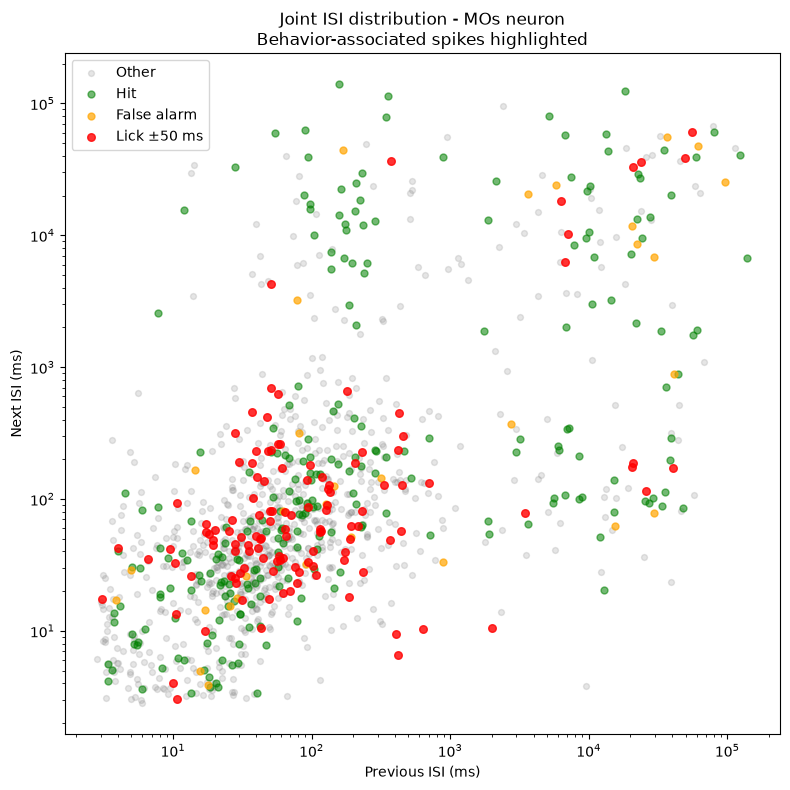

In [21]:
# ==========================================================
# Joint ISI plot colored by lick / hit / false alarm
# ==========================================================

# ISIs in milliseconds
isi_ms = np.diff(real_spikes) * 1000

previous_isi = isi_ms[:-1]
next_isi = isi_ms[1:]

# central spike for each joint-ISI point
central_spikes_rel = real_spikes[1:-1]

# convert back to absolute recording time
central_spikes_abs = central_spikes_rel + task_start


# ----------------------------------------------------------
# Initialize labels
# ----------------------------------------------------------

labels = np.array(
    ["Other"] * len(central_spikes_abs),
    dtype=object
)


# ----------------------------------------------------------
# HIT and FALSE ALARM
# ----------------------------------------------------------

for _, trial in trials.iterrows():

    mask = (
        (central_spikes_abs >= trial["start_time"]) &
        (central_spikes_abs < trial["stop_time"])
    )

    if trial["is_hit"]:
        labels[mask] = "Hit"

    elif trial["is_false_alarm"]:
        labels[mask] = "False alarm"


# ----------------------------------------------------------
# LICK-associated spikes
# ----------------------------------------------------------

lick_window = 0.05   # ±50 ms

for i, spike in enumerate(central_spikes_abs):

    if np.any(
        np.abs(
            likely_licks["timestamps"].values - spike
        ) <= lick_window
    ):
        labels[i] = "Lick"


# ----------------------------------------------------------
# Print counts
# ----------------------------------------------------------

unique, counts = np.unique(labels, return_counts=True)

for u, c in zip(unique, counts):
    print(u, c)


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(8, 8))

# Other
mask = labels == "Other"

plt.scatter(
    previous_isi[mask],
    next_isi[mask],
    s=18,
    alpha=0.20,
    color="gray",
    label="Other"
)

# Hit
mask = labels == "Hit"

plt.scatter(
    previous_isi[mask],
    next_isi[mask],
    s=25,
    alpha=0.55,
    color="green",
    label="Hit"
)

# False Alarm
mask = labels == "False alarm"

plt.scatter(
    previous_isi[mask],
    next_isi[mask],
    s=25,
    alpha=0.7,
    color="orange",
    label="False alarm"
)

# Lick
mask = labels == "Lick"

plt.scatter(
    previous_isi[mask],
    next_isi[mask],
    s=30,
    alpha=0.8,
    color="red",
    label="Lick ±50 ms"
)


plt.xscale("log")
plt.yscale("log")

plt.xlabel("Previous ISI (ms)")
plt.ylabel("Next ISI (ms)")

plt.title(
    "Joint ISI distribution - MOs neuron\n"
    "Behavior-associated spikes highlighted"
)

plt.legend()

plt.tight_layout()
plt.show()

In [20]:
trials = nwbfile.trials[:]

print("Number of trials:", len(trials))
print(trials[["is_hit", "is_false_alarm"]].sum())

Number of trials: 545
is_hit            142
is_false_alarm     40
dtype: int64


Lick-associated spikes: 124
Other spikes: 1070


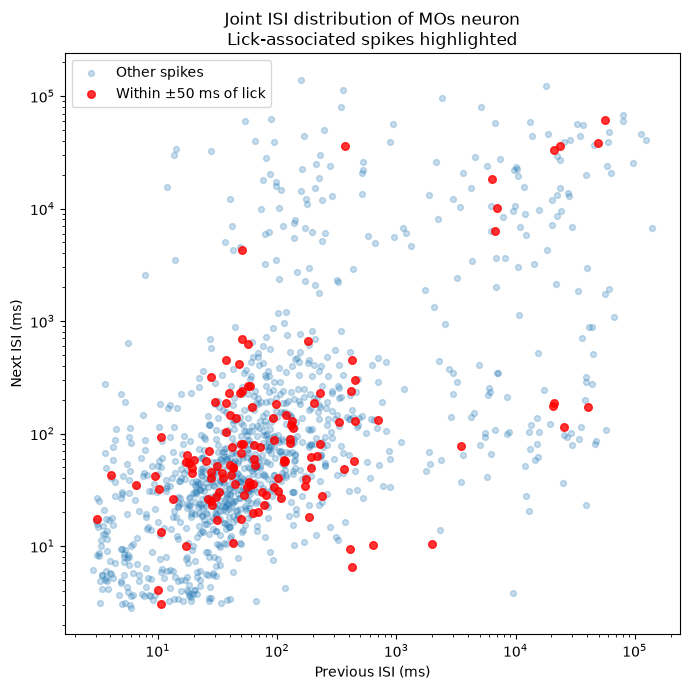

In [18]:
# ==========================================================
# Joint ISI plot colored by lick association
# ==========================================================

# ISIs in milliseconds
isi_ms = np.diff(real_spikes) * 1000

# Each joint-ISI point corresponds to the middle spike
previous_isi = isi_ms[:-1]
next_isi = isi_ms[1:]

central_spikes = real_spikes[1:-1]


# ----------------------------------------------------------
# Determine whether each central spike is close to a lick
# ----------------------------------------------------------

lick_window = 0.05   # 50 ms

lick_associated = np.zeros(
    len(central_spikes),
    dtype=bool
)

for i, spike in enumerate(central_spikes):

    if np.any(
        np.abs(lick_times_task - spike) <= lick_window
    ):
        lick_associated[i] = True


print(
    "Lick-associated spikes:",
    np.sum(lick_associated)
)

print(
    "Other spikes:",
    np.sum(~lick_associated)
)


# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(7, 7))

# Other spikes first
plt.scatter(
    previous_isi[~lick_associated],
    next_isi[~lick_associated],
    s=18,
    alpha=0.25,
    label="Other spikes"
)

# Lick-associated spikes on top
plt.scatter(
    previous_isi[lick_associated],
    next_isi[lick_associated],
    s=30,
    alpha=0.8,
    color="red",
    label="Within ±50 ms of lick"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Previous ISI (ms)")
plt.ylabel("Next ISI (ms)")

plt.title(
    "Joint ISI distribution of MOs neuron\n"
    "Lick-associated spikes highlighted"
)

plt.legend()

plt.tight_layout()
plt.show()

Number of lick bouts: 173


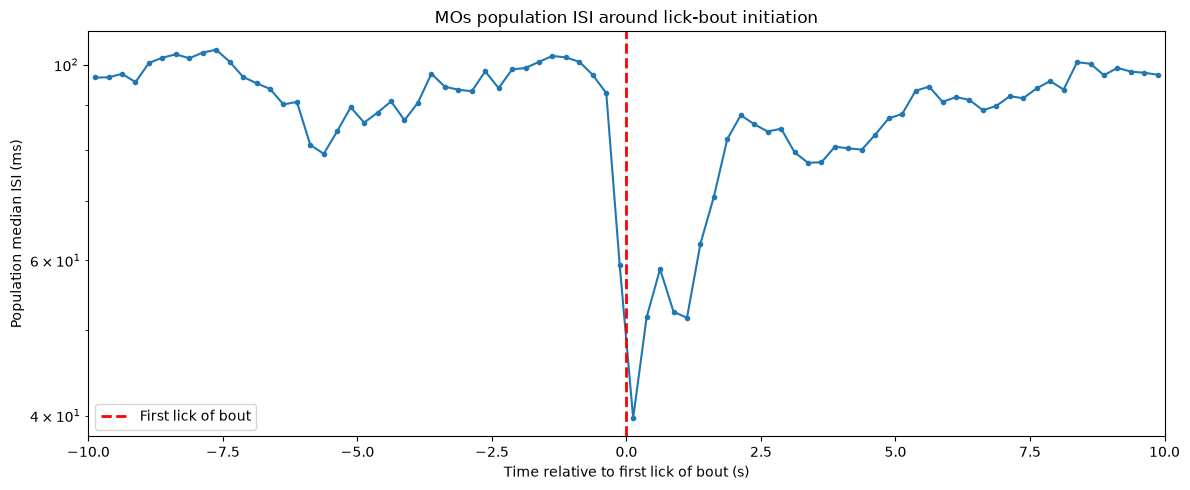

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters
# ==========================================

window = 10.0       # 10 sec before and 10 sec after
bin_size = 0.25     # 250 ms bins

bins = np.arange(-window, window + bin_size, bin_size)
bin_centers = (bins[:-1] + bins[1:]) / 2


# ==========================================
# FIRST LICK of each lick bout
# ==========================================

bout_first_licks = np.array([
    bout[0] for bout in lick_bouts
])

print("Number of lick bouts:", len(bout_first_licks))


# ==========================================
# Store population ISIs
# ==========================================

population_isi = [[] for _ in range(len(bin_centers))]


# ==========================================
# Loop through all MOs neurons
# ==========================================

for _, unit in motor_units.iterrows():

    spikes = np.asarray(unit["spike_times"])

    # Task period only
    spikes = spikes[
        (spikes >= task_start) &
        (spikes < task_stop)
    ]

    if len(spikes) < 2:
        continue

    # ISI in milliseconds
    isi_ms = np.diff(spikes) * 1000

    # Time associated with each ISI
    isi_times = spikes[:-1]


    # ======================================
    # Align to FIRST lick of each bout
    # ======================================

    for lick_time in bout_first_licks:

        relative_time = isi_times - lick_time

        event_mask = (
            (relative_time >= -window) &
            (relative_time <= window)
        )

        rel = relative_time[event_mask]
        values = isi_ms[event_mask]

        inds = np.digitize(rel, bins) - 1

        for j, value in zip(inds, values):

            if 0 <= j < len(population_isi):
                population_isi[j].append(value)


# ==========================================
# Population median ISI
# ==========================================

median_isi = np.array([
    np.median(x) if len(x) > 0 else np.nan
    for x in population_isi
])


# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    bin_centers,
    median_isi,
    marker="o",
    markersize=3
)

# First lick
plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="First lick of bout"
)

plt.yscale("log")

plt.xlabel("Time relative to first lick of bout (s)")
plt.ylabel("Population median ISI (ms)")

plt.title(
    "MOs population ISI around lick-bout initiation"
)

plt.xlim(-10, 10)

plt.legend()

plt.tight_layout()
plt.show()

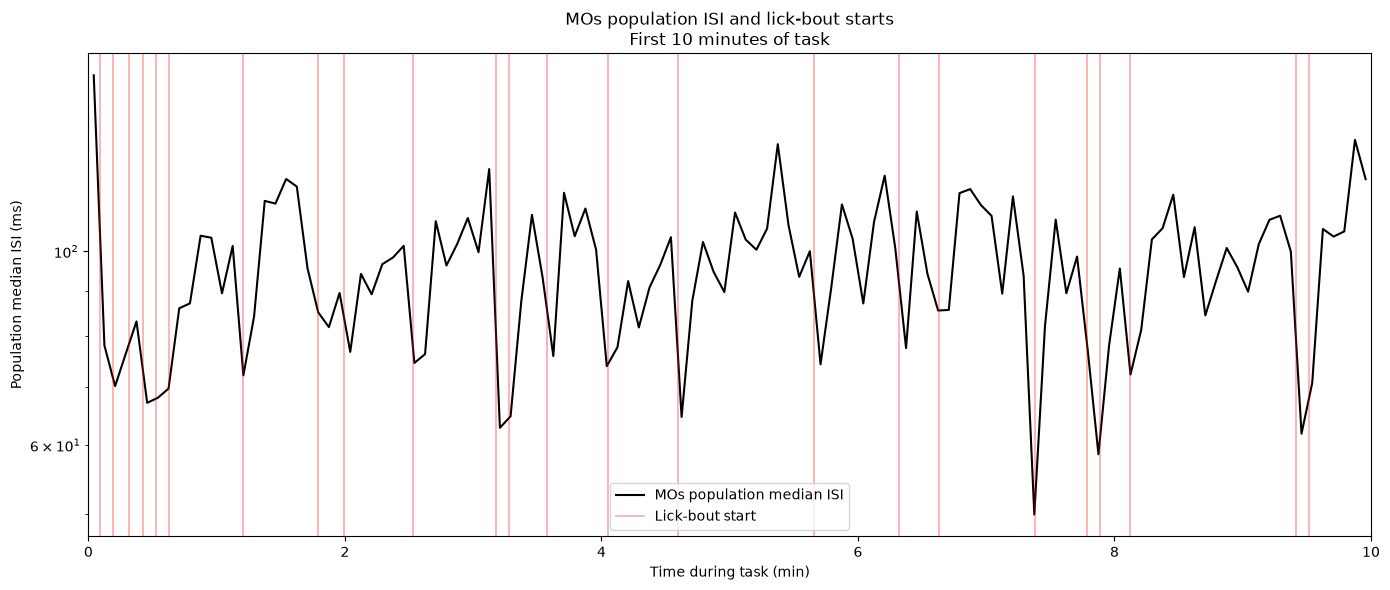

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# First 10 minutes only
start_min = 0
end_min = 10

start_time = task_start + start_min * 60
end_time = task_start + end_min * 60

bin_size = 5.0   # seconds

bins = np.arange(
    start_time,
    end_time + bin_size,
    bin_size
)

bin_centers = (bins[:-1] + bins[1:]) / 2

# Convert to minutes from task start
time_min = (bin_centers - task_start) / 60



# Collect ISIs from all MOs neurons


population_isi = [[] for _ in range(len(bin_centers))]

for _, unit in motor_units.iterrows():

    spikes = np.asarray(unit["spike_times"])

    # Keep only spikes in first 10 min
    spikes = spikes[
        (spikes >= start_time) &
        (spikes < end_time)
    ]

    if len(spikes) < 2:
        continue

    # ISI in milliseconds
    isi_ms = np.diff(spikes) * 1000

    # Time associated with each ISI
    isi_times = spikes[:-1]

    # Put ISIs into task-time bins
    inds = np.digitize(isi_times, bins) - 1

    for j, value in zip(inds, isi_ms):
        if 0 <= j < len(population_isi):
            population_isi[j].append(value)


# ==========================================
# Population median ISI
# ==========================================

median_isi = np.array([
    np.median(x) if len(x) > 0 else np.nan
    for x in population_isi
])


# ==========================================
# Lick-bout starts during first 10 min
# ==========================================

bout_first_licks = np.array([
    bout[0] for bout in lick_bouts
])

bout_first_licks = bout_first_licks[
    (bout_first_licks >= start_time) &
    (bout_first_licks < end_time)
]

bout_times_min = (
    bout_first_licks - task_start
) / 60


# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(14, 6))

# MOs population ISI
plt.plot(
    time_min,
    median_isi,
    color="black",
    linewidth=1.5,
    label="MOs population median ISI"
)

# Real lick-bout start times
for i, t in enumerate(bout_times_min):
    plt.axvline(
        t,
        color="red",
        alpha=0.35,
        linewidth=1.2,
        label="Lick-bout start" if i == 0 else None
    )

plt.yscale("log")

plt.xlim(0, 10)

plt.xlabel("Time during task (min)")
plt.ylabel("Population median ISI (ms)")

plt.title(
    "MOs population ISI and lick-bout starts\n"
    "First 10 minutes of task"
)

plt.legend()
plt.tight_layout()
plt.show()

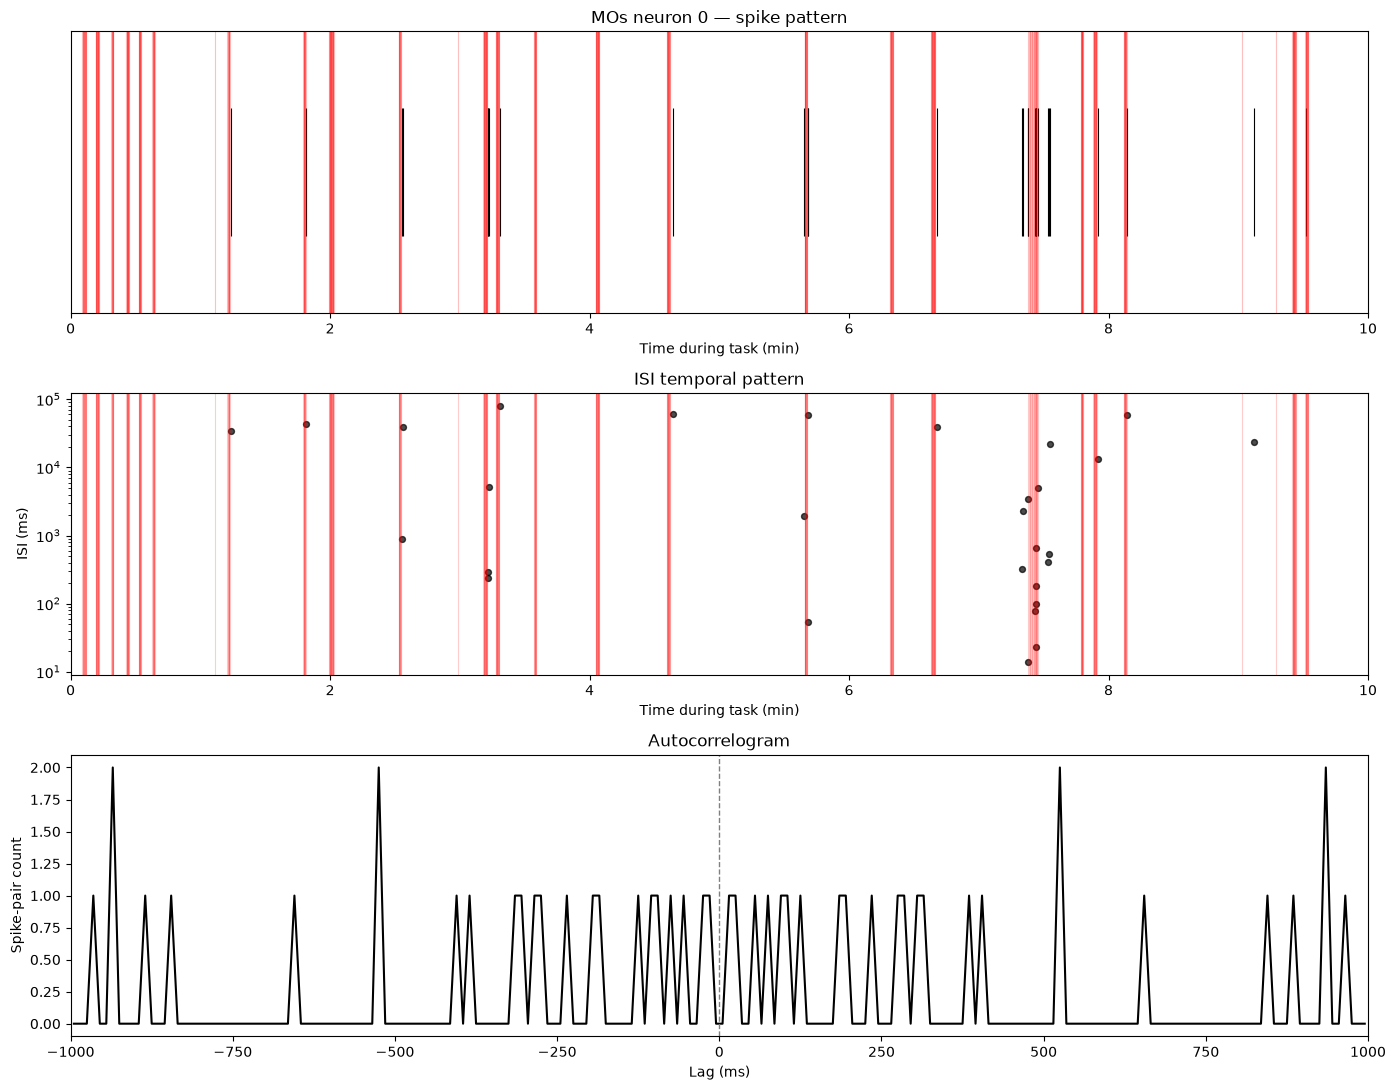

Neuron row: 0
Unit ID: 1368
Number of spikes in first 10 min: 30
Median ISI: 2319.65 ms
Mean firing rate: 0.05 Hz


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

neuron_number = 0

# First 10 minutes of task
analysis_start = task_start
analysis_stop = task_start + 10 * 60

# Select neuron 0 from QC-passing MOs neurons
unit = motor_units.iloc[neuron_number]

spikes = np.asarray(unit["spike_times"])

# Keep spikes only in first 10 minutes
spikes_10min = spikes[
    (spikes >= analysis_start) &
    (spikes < analysis_stop)
]

# Convert spike times to minutes from beginning of task
spike_time_min = (
    spikes_10min - task_start
) / 60


# =========================================================
# ISIs
# =========================================================

isi_ms = np.diff(spikes_10min) * 1000

# Associate each ISI with the time of its first spike
isi_time_min = (
    spikes_10min[:-1] - task_start
) / 60


# =========================================================
# LICKS IN FIRST 10 MINUTES
# =========================================================

licks_10min = lick_times[
    (lick_times >= analysis_start) &
    (lick_times < analysis_stop)
]

lick_time_min = (
    licks_10min - task_start
) / 60


# =========================================================
# AUTOCORRELOGRAM
# =========================================================

# Look at spike relationships within +/- 1 second
max_lag = 1.0

# 10 ms bins
bin_size = 0.01

lag_bins = np.arange(
    -max_lag,
    max_lag + bin_size,
    bin_size
)

all_lags = []

# Calculate time differences between spikes
for i in range(len(spikes_10min)):

    differences = spikes_10min - spikes_10min[i]

    # Keep differences within +/- max_lag
    differences = differences[
        (differences >= -max_lag) &
        (differences <= max_lag)
    ]

    # Remove zero lag (spike with itself)
    differences = differences[
        differences != 0
    ]

    all_lags.extend(differences)


all_lags = np.array(all_lags)

acf_counts, edges = np.histogram(
    all_lags,
    bins=lag_bins
)

lag_centers = (
    edges[:-1] + edges[1:]
) / 2


# =========================================================
# FIGURE
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 11)
)


# ---------------------------------------------------------
# PANEL 1 — SPIKE TIMES
# ---------------------------------------------------------

axes[0].eventplot(
    spike_time_min,
    lineoffsets=1,
    linelengths=0.8,
    linewidths=0.8,
    color="black"
)

# Licks = red
for lick in lick_time_min:
    axes[0].axvline(
        lick,
        color="red",
        alpha=0.25,
        linewidth=0.8
    )

axes[0].set_xlim(0, 10)

axes[0].set_yticks([])

axes[0].set_xlabel(
    "Time during task (min)"
)

axes[0].set_title(
    f"MOs neuron {neuron_number} — spike pattern"
)


# ---------------------------------------------------------
# PANEL 2 — ISI THROUGH TIME
# ---------------------------------------------------------

axes[1].scatter(
    isi_time_min,
    isi_ms,
    s=18,
    alpha=0.7,
    color="black"
)

# Licks = red
for lick in lick_time_min:
    axes[1].axvline(
        lick,
        color="red",
        alpha=0.20,
        linewidth=0.8
    )

axes[1].set_yscale("log")

axes[1].set_xlim(0, 10)

axes[1].set_xlabel(
    "Time during task (min)"
)

axes[1].set_ylabel(
    "ISI (ms)"
)

axes[1].set_title(
    "ISI temporal pattern"
)


# ---------------------------------------------------------
# PANEL 3 — AUTOCORRELOGRAM
# ---------------------------------------------------------

axes[2].plot(
    lag_centers * 1000,
    acf_counts,
    color="black",
    linewidth=1.5
)

axes[2].axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

axes[2].set_xlabel(
    "Lag (ms)"
)

axes[2].set_ylabel(
    "Spike-pair count"
)

axes[2].set_title(
    "Autocorrelogram"
)

axes[2].set_xlim(
    -1000,
    1000
)


plt.tight_layout()
plt.show()


# =========================================================
# BASIC INFORMATION
# =========================================================

print("Neuron row:", neuron_number)
print("Unit ID:", unit.name)
print("Number of spikes in first 10 min:", len(spikes_10min))

if len(spikes_10min) > 1:
    print(
        "Median ISI:",
        round(np.median(isi_ms), 2),
        "ms"
    )

    print(
        "Mean firing rate:",
        round(
            len(spikes_10min) /
            (analysis_stop - analysis_start),
            3
        ),
        "Hz"
    )

Neuron row: 3
Unit ID: 1404
Number of spikes: 1425


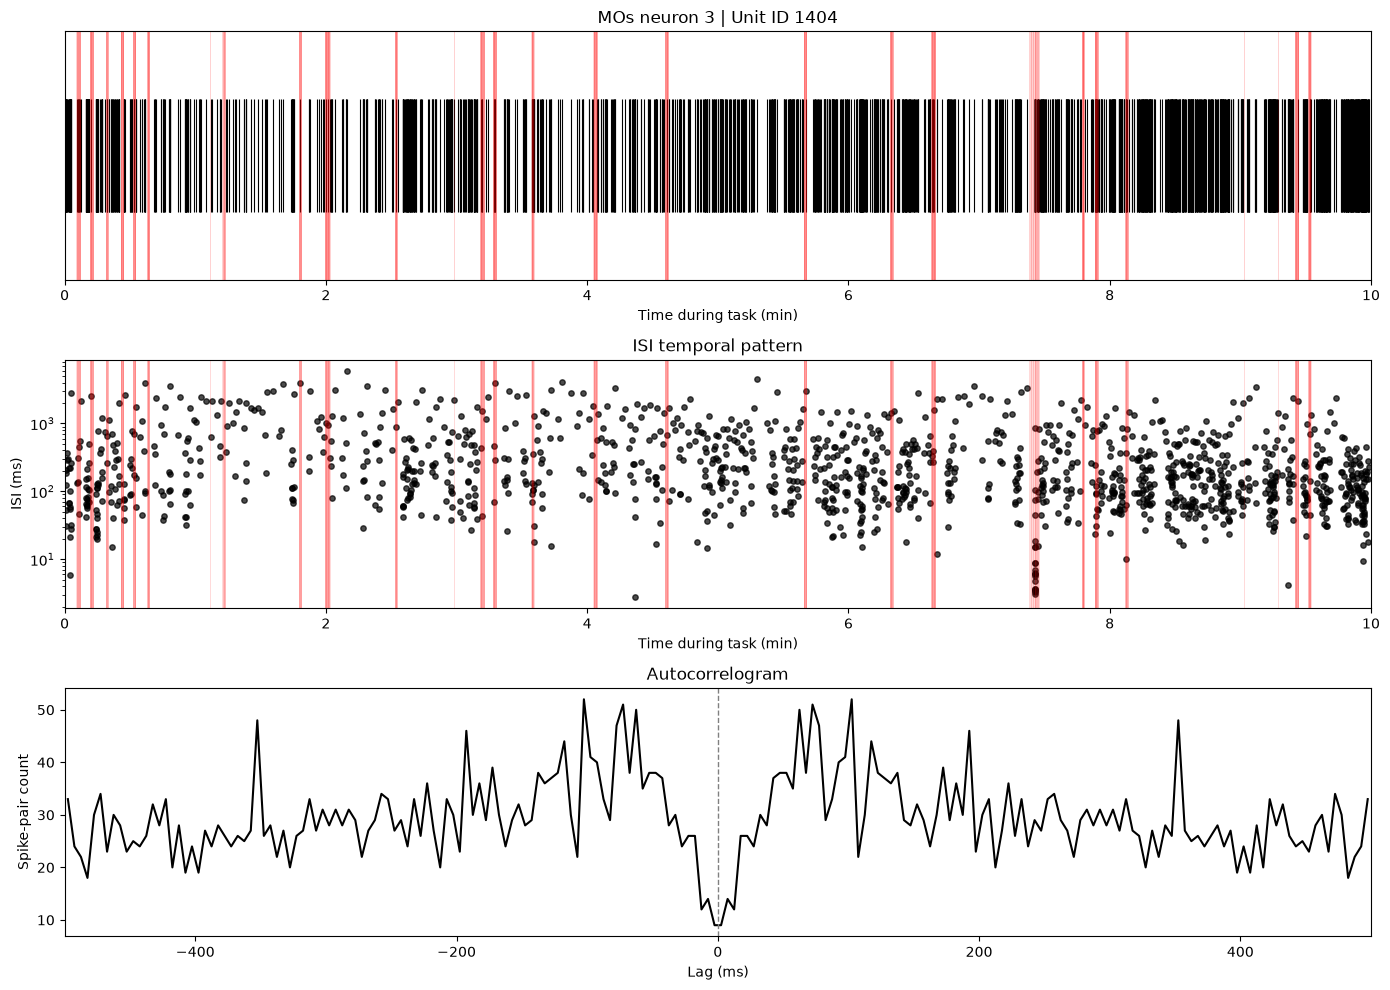

Median ISI: 169.48 ms
Mean firing rate: 2.375 Hz


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

neuron_number = 3   # change to 0,1,2,3,4...
analysis_start = task_start
analysis_stop = task_start + 10 * 60   # first 10 min

# Autocorrelation settings
max_lag = 0.5       # +/- 500 ms
bin_size = 0.005    # 5 ms bins

# =========================================================
# SELECT ONE MOs NEURON
# =========================================================

unit = motor_units.iloc[neuron_number]

spikes = np.asarray(unit["spike_times"])

spikes_10min = spikes[
    (spikes >= analysis_start) &
    (spikes < analysis_stop)
]

print("Neuron row:", neuron_number)
print("Unit ID:", unit.name)
print("Number of spikes:", len(spikes_10min))


# =========================================================
# SPIKE TIMES + ISI
# =========================================================

spike_time_min = (
    spikes_10min - task_start
) / 60

isi_ms = np.diff(spikes_10min) * 1000

isi_time_min = (
    spikes_10min[:-1] - task_start
) / 60


# =========================================================
# LICKS DURING FIRST 10 MIN
# =========================================================

licks_10min = lick_times[
    (lick_times >= analysis_start) &
    (lick_times < analysis_stop)
]

lick_time_min = (
    licks_10min - task_start
) / 60


# =========================================================
# AUTOCORRELOGRAM
# =========================================================

lags = []

for i, spike in enumerate(spikes_10min):

    # Only compare with later spikes
    future_spikes = spikes_10min[i + 1:]

    differences = future_spikes - spike

    # Only keep lags within max_lag
    differences = differences[
        differences <= max_lag
    ]

    lags.extend(differences)

lags = np.array(lags)

# Make autocorrelogram symmetric
all_lags = np.concatenate([
    -lags,
    lags
])

bins = np.arange(
    -max_lag,
    max_lag + bin_size,
    bin_size
)

acf_counts, edges = np.histogram(
    all_lags,
    bins=bins
)

lag_centers = (
    edges[:-1] + edges[1:]
) / 2


# =========================================================
# PLOT
# =========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10)
)


# ---------------------------------------------------------
# 1. Spike train
# ---------------------------------------------------------

axes[0].eventplot(
    spike_time_min,
    lineoffsets=1,
    linelengths=0.8,
    linewidths=0.8,
    color="black"
)

for lick in lick_time_min:
    axes[0].axvline(
        lick,
        color="red",
        alpha=0.18,
        linewidth=0.7
    )

axes[0].set_xlim(0, 10)
axes[0].set_yticks([])

axes[0].set_xlabel(
    "Time during task (min)"
)

axes[0].set_title(
    f"MOs neuron {neuron_number} | Unit ID {unit.name}"
)


# ---------------------------------------------------------
# 2. ISI through time
# ---------------------------------------------------------

axes[1].scatter(
    isi_time_min,
    isi_ms,
    s=15,
    alpha=0.7,
    color="black"
)

for lick in lick_time_min:
    axes[1].axvline(
        lick,
        color="red",
        alpha=0.15,
        linewidth=0.7
    )

axes[1].set_yscale("log")
axes[1].set_xlim(0, 10)

axes[1].set_xlabel(
    "Time during task (min)"
)

axes[1].set_ylabel(
    "ISI (ms)"
)

axes[1].set_title(
    "ISI temporal pattern"
)


# ---------------------------------------------------------
# 3. Autocorrelogram
# ---------------------------------------------------------

axes[2].plot(
    lag_centers * 1000,
    acf_counts,
    color="black",
    linewidth=1.5
)

axes[2].axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

axes[2].set_xlim(
    -500,
    500
)

axes[2].set_xlabel(
    "Lag (ms)"
)

axes[2].set_ylabel(
    "Spike-pair count"
)

axes[2].set_title(
    "Autocorrelogram"
)

plt.tight_layout()
plt.show()


# =========================================================
# BASIC NUMBERS
# =========================================================

if len(spikes_10min) > 1:

    print(
        "Median ISI:",
        round(np.median(isi_ms), 2),
        "ms"
    )

    print(
        "Mean firing rate:",
        round(
            len(spikes_10min) /
            (analysis_stop - analysis_start),
            3
        ),
        "Hz"
    )

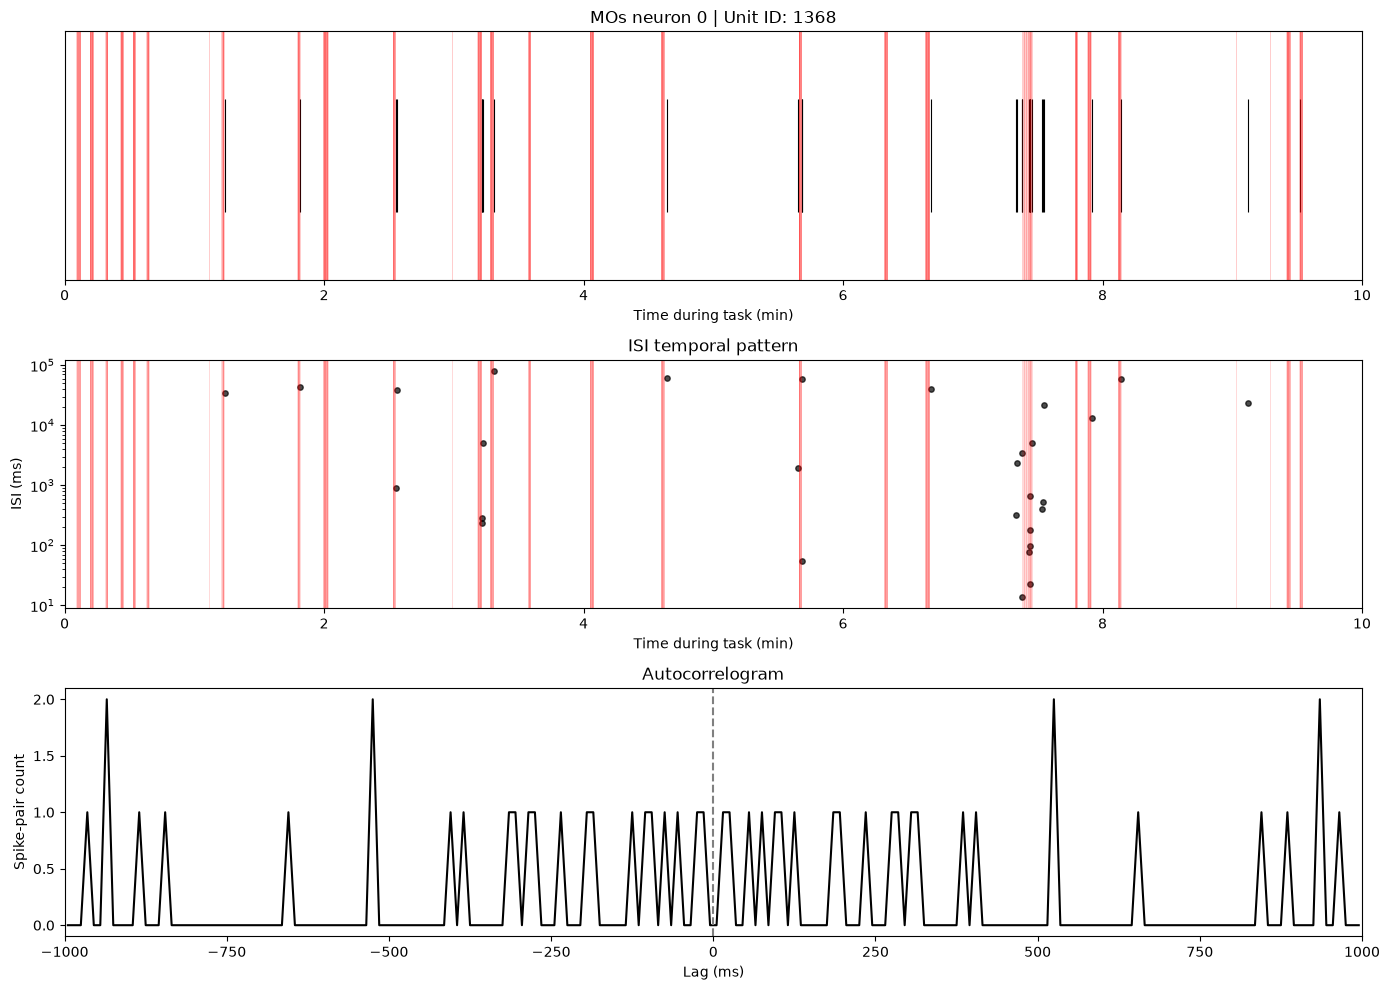

Neuron: 0 | Unit ID: 1368 | Spikes: 30 | Median ISI: 2319.65 ms


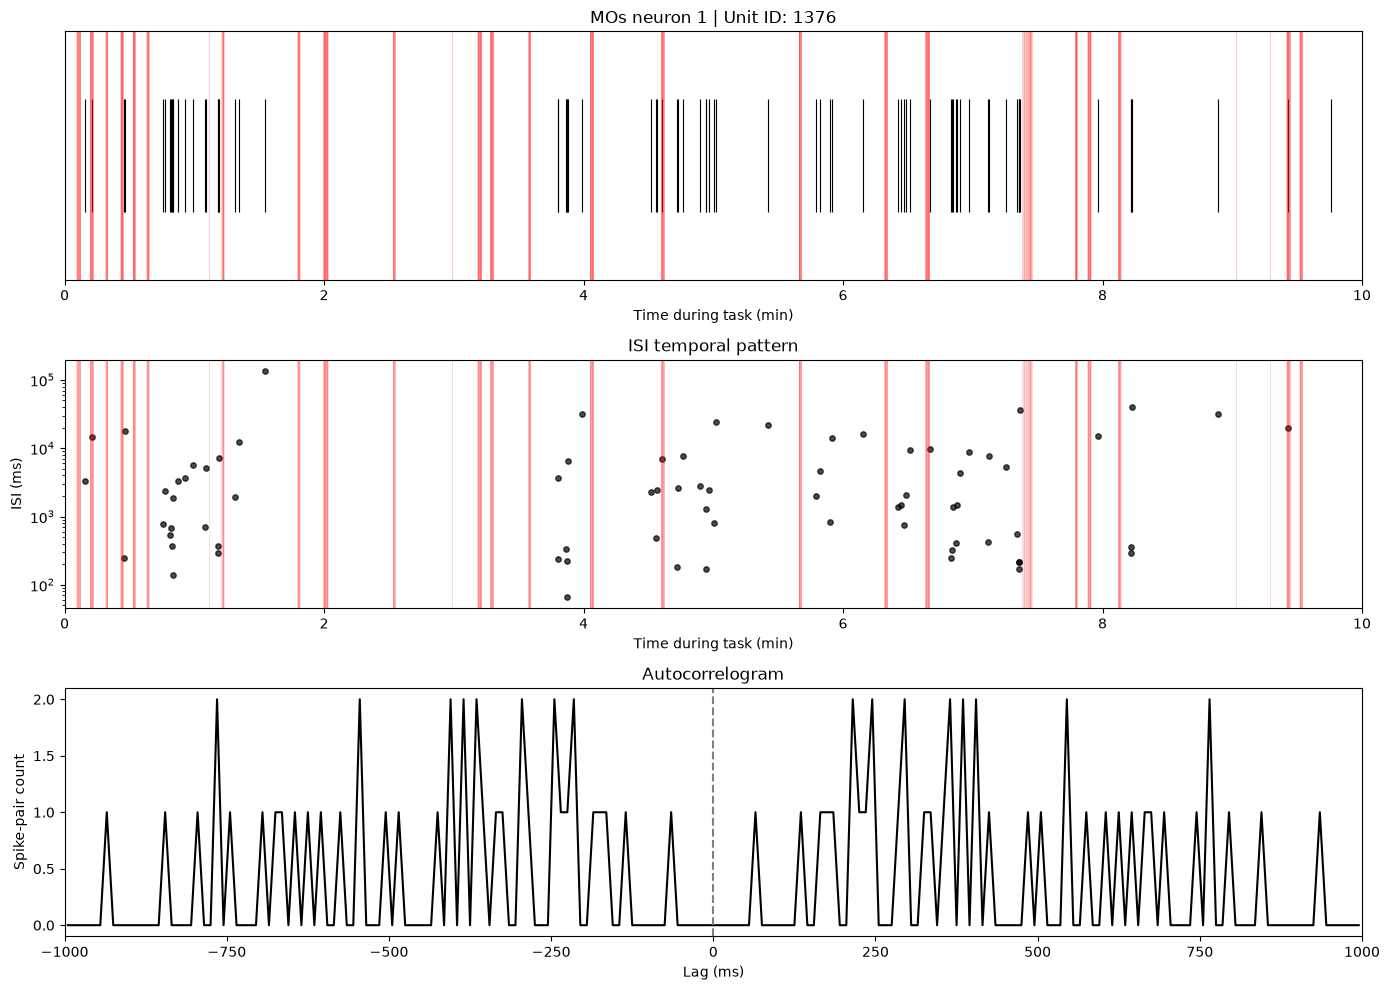

Neuron: 1 | Unit ID: 1376 | Spikes: 76 | Median ISI: 2065.82 ms


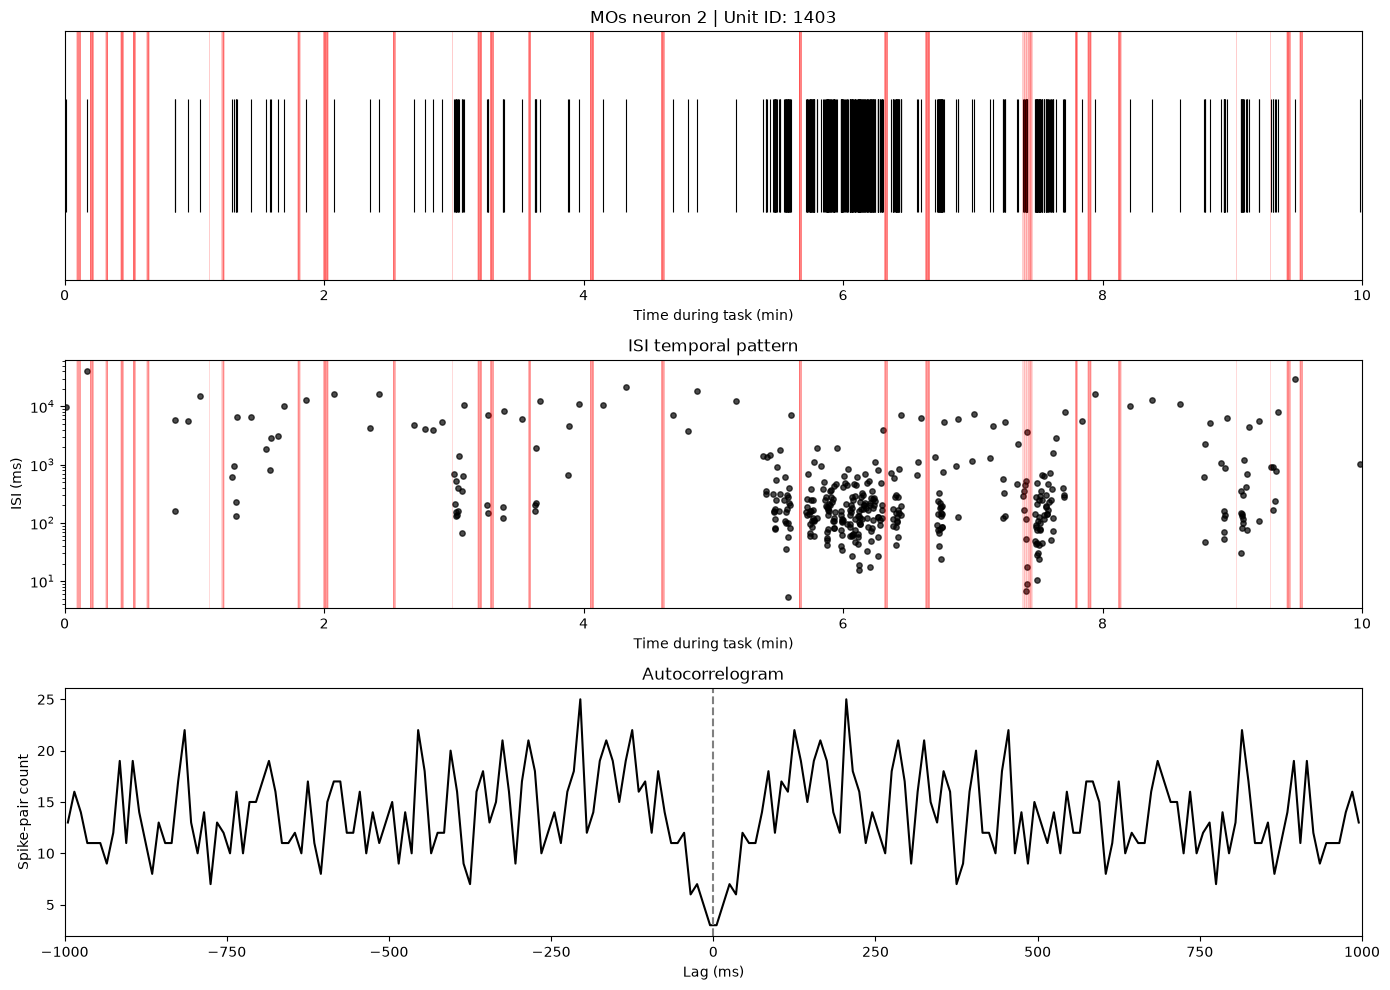

Neuron: 2 | Unit ID: 1403 | Spikes: 406 | Median ISI: 199.53 ms


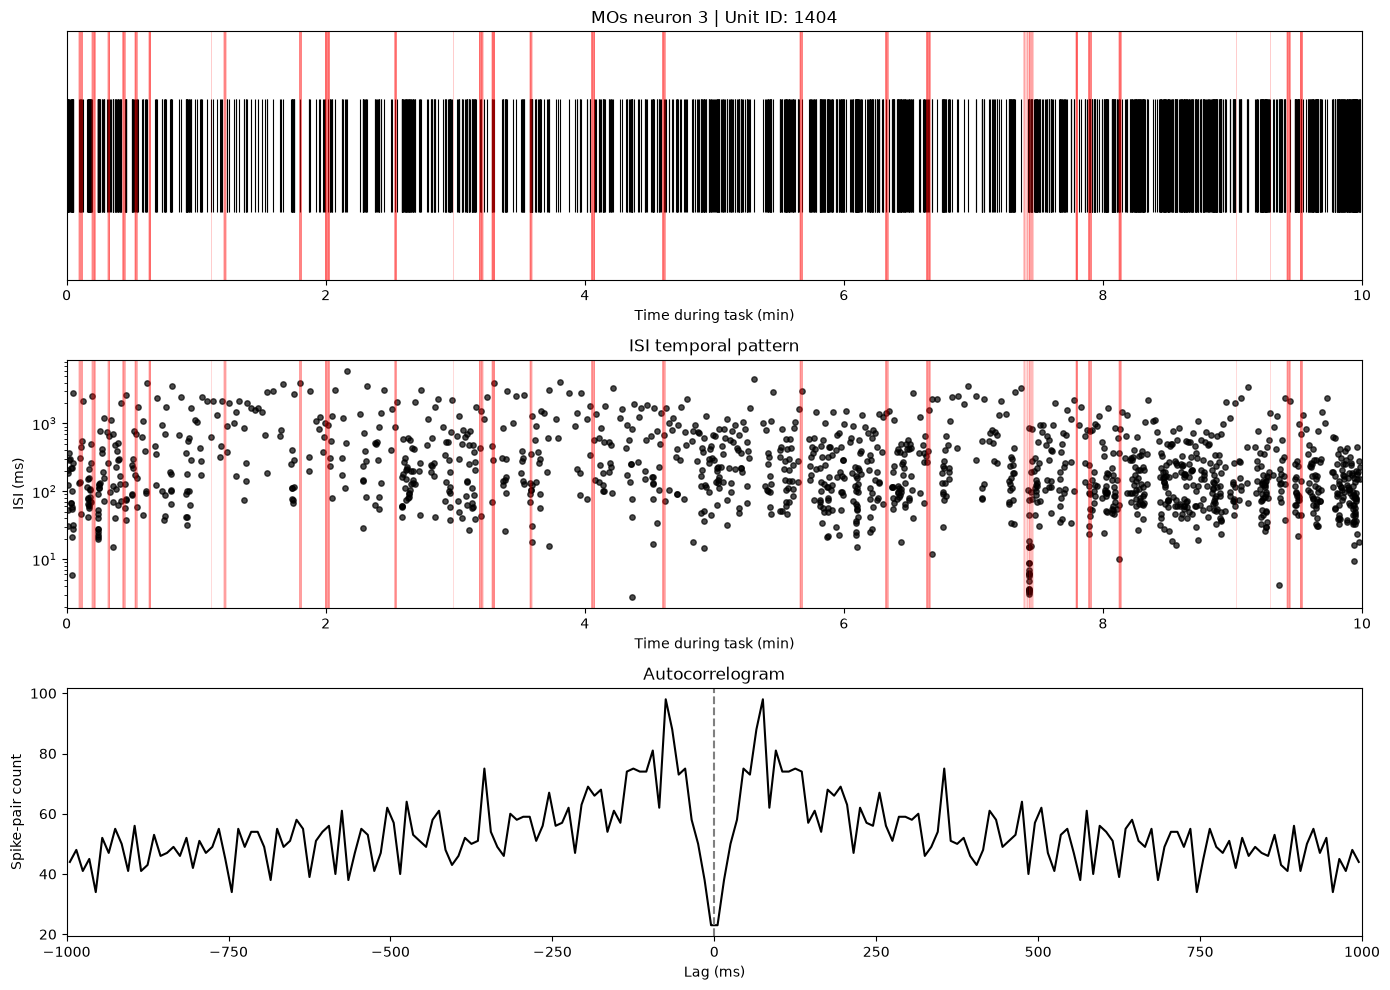

Neuron: 3 | Unit ID: 1404 | Spikes: 1425 | Median ISI: 169.48 ms


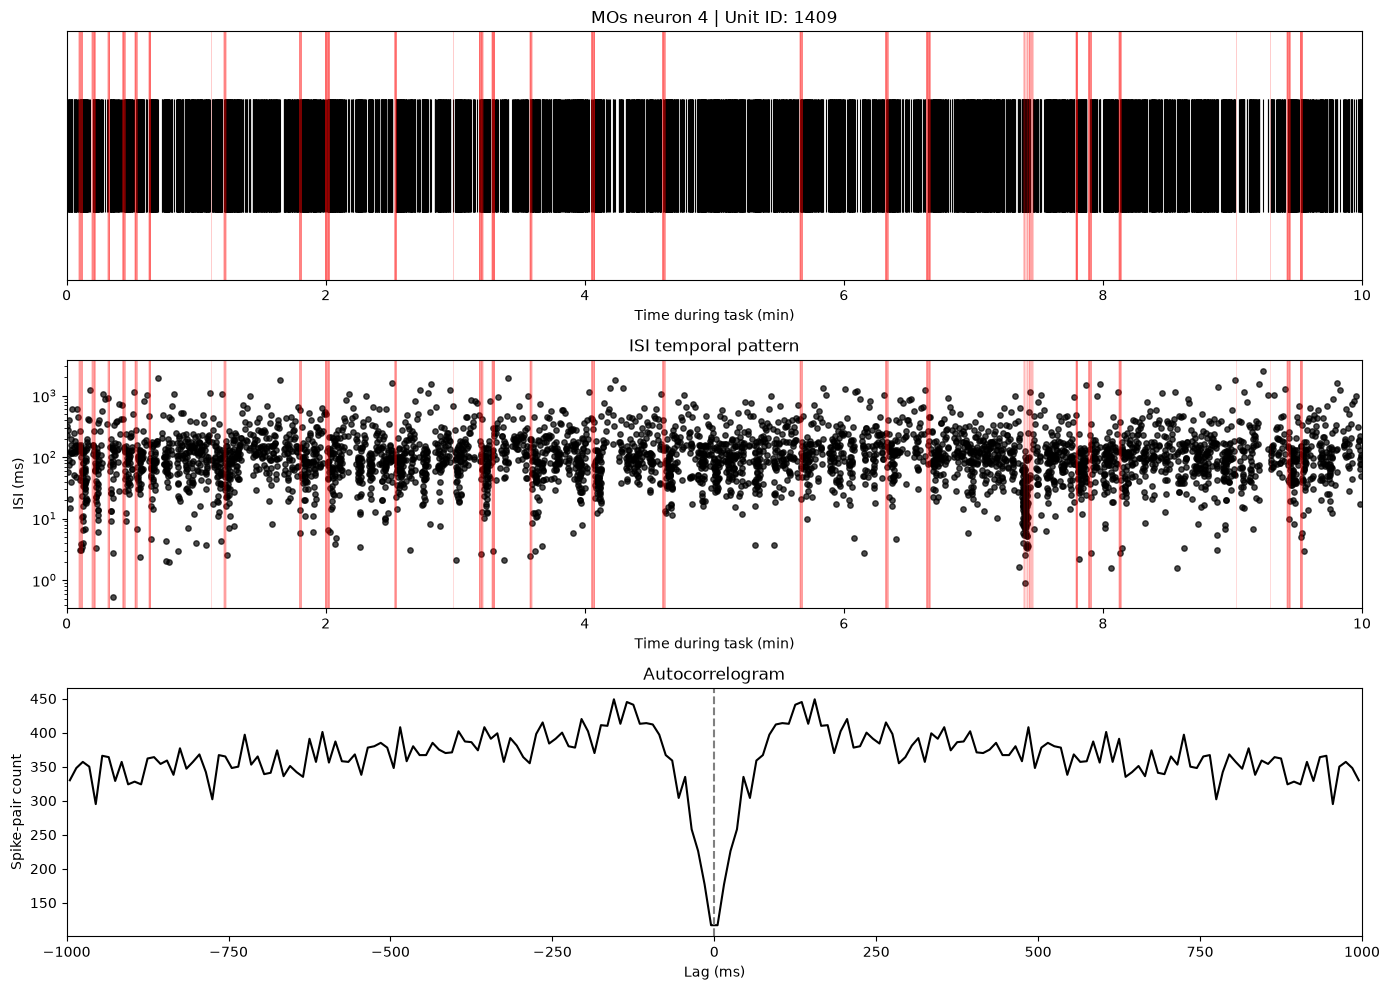

Neuron: 4 | Unit ID: 1409 | Spikes: 4128 | Median ISI: 96.3 ms


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================

number_of_neurons = 5

analysis_start = task_start
analysis_stop = task_start + 10 * 60

max_lag = 1.0
bin_size = 0.01

lag_bins = np.arange(
    -max_lag,
    max_lag + bin_size,
    bin_size
)


# =========================================================
# LOOP THROUGH INDIVIDUAL MOs NEURONS
# =========================================================

for neuron_number in range(number_of_neurons):

    unit = motor_units.iloc[neuron_number]

    spikes = np.asarray(unit["spike_times"])

    spikes_10min = spikes[
        (spikes >= analysis_start) &
        (spikes < analysis_stop)
    ]

    # Skip neurons with too few spikes
    if len(spikes_10min) < 3:
        print(
            "Skipping neuron",
            neuron_number,
            "- too few spikes"
        )
        continue


    # =====================================================
    # SPIKE TIMES
    # =====================================================

    spike_time_min = (
        spikes_10min - task_start
    ) / 60


    # =====================================================
    # ISI
    # =====================================================

    isi_ms = np.diff(spikes_10min) * 1000

    isi_time_min = (
        spikes_10min[:-1] - task_start
    ) / 60


    # =====================================================
    # AUTOCORRELATION
    # =====================================================

    all_lags = []

    for i in range(len(spikes_10min)):

        differences = (
            spikes_10min - spikes_10min[i]
        )

        differences = differences[
            (differences >= -max_lag) &
            (differences <= max_lag)
        ]

        differences = differences[
            differences != 0
        ]

        all_lags.extend(differences)

    all_lags = np.array(all_lags)

    acf_counts, edges = np.histogram(
        all_lags,
        bins=lag_bins
    )

    lag_centers = (
        edges[:-1] + edges[1:]
    ) / 2


    # =====================================================
    # FIGURE
    # =====================================================

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(14, 10)
    )


    # -----------------------------------------------------
    # Panel 1: Spike pattern
    # -----------------------------------------------------

    axes[0].eventplot(
        spike_time_min,
        lineoffsets=1,
        linelengths=0.8,
        linewidths=0.8,
        color="black"
    )

    for lick in lick_time_min:
        axes[0].axvline(
            lick,
            color="red",
            alpha=0.20,
            linewidth=0.7
        )

    axes[0].set_xlim(0, 10)
    axes[0].set_yticks([])

    axes[0].set_title(
        f"MOs neuron {neuron_number} | Unit ID: {unit.name}"
    )

    axes[0].set_xlabel(
        "Time during task (min)"
    )


    # -----------------------------------------------------
    # Panel 2: ISI pattern
    # -----------------------------------------------------

    axes[1].scatter(
        isi_time_min,
        isi_ms,
        s=15,
        alpha=0.7,
        color="black"
    )

    for lick in lick_time_min:
        axes[1].axvline(
            lick,
            color="red",
            alpha=0.15,
            linewidth=0.7
        )

    axes[1].set_yscale("log")
    axes[1].set_xlim(0, 10)

    axes[1].set_xlabel(
        "Time during task (min)"
    )

    axes[1].set_ylabel(
        "ISI (ms)"
    )

    axes[1].set_title(
        "ISI temporal pattern"
    )


    # -----------------------------------------------------
    # Panel 3: Autocorrelogram
    # -----------------------------------------------------

    axes[2].plot(
        lag_centers * 1000,
        acf_counts,
        color="black",
        linewidth=1.5
    )

    axes[2].axvline(
        0,
        color="gray",
        linestyle="--"
    )

    axes[2].set_xlim(
        -1000,
        1000
    )

    axes[2].set_xlabel(
        "Lag (ms)"
    )

    axes[2].set_ylabel(
        "Spike-pair count"
    )

    axes[2].set_title(
        "Autocorrelogram"
    )


    plt.tight_layout()
    plt.show()


    # =====================================================
    # PRINT SUMMARY
    # =====================================================

    print(
        "Neuron:",
        neuron_number,
        "| Unit ID:",
        unit.name,
        "| Spikes:",
        len(spikes_10min),
        "| Median ISI:",
        round(np.median(isi_ms), 2),
        "ms"
    )

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


NWB loaded successfully
Number of QC-passing MOs neurons: 70
Task duration: 60.69 minutes
Number of likely licks: 1938
Number of licking bouts: 173

Bout: 0
Number of licks: 13
Bout duration: 1.812 seconds


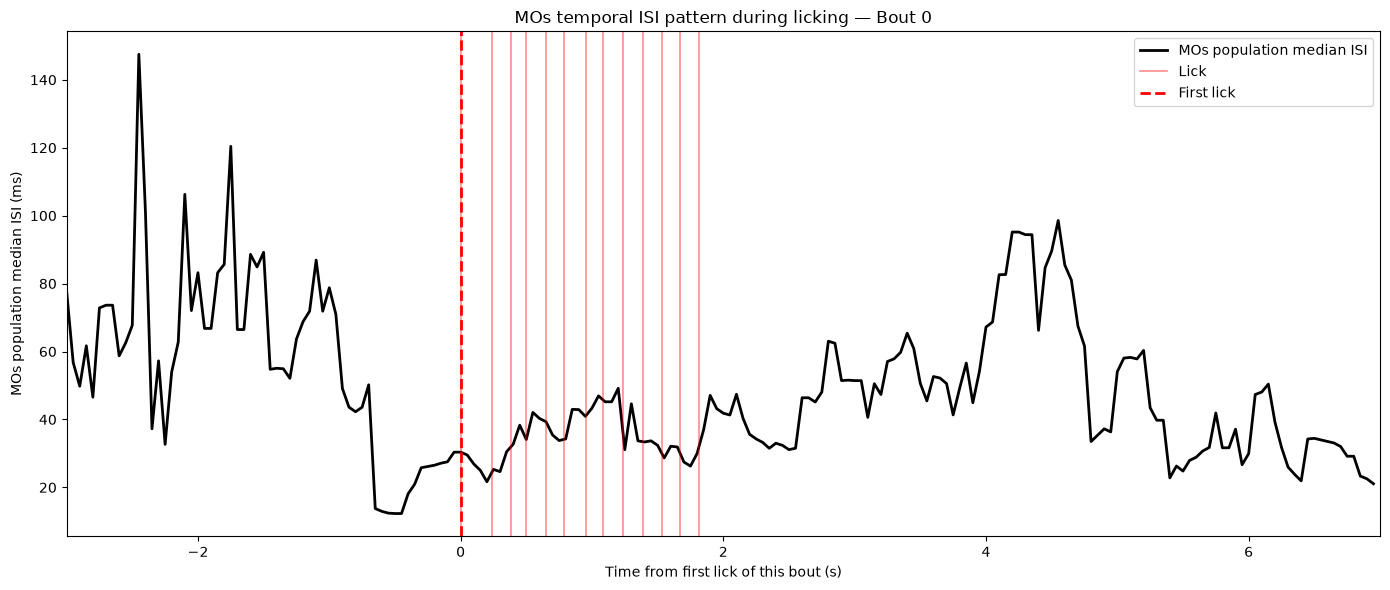

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pynwb


# =========================================================
# 1. RELOAD THE NWB FILE
# =========================================================

nwb_path = (
    "/data/dynamicrouting_datacube/"
    "ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/"
    "759434_2025-02-04.nwb.zarr"
)

nwbfile = pynwb.read_nwb(nwb_path)

print("NWB loaded successfully")


# =========================================================
# 2. LOAD UNITS
# =========================================================

all_units = nwbfile.units[:]

motor_units = all_units[
    (all_units["structure"] == "MOs") &
    (all_units["is_qc_pass"] == True)
].copy()

print("Number of QC-passing MOs neurons:", len(motor_units))


# =========================================================
# 3. DEFINE TASK PERIOD
# =========================================================

epochs = nwbfile.intervals["epochs"][:]

# DynamicRouting1
task_start = 2155.69515
task_stop  = 5796.812075

print(
    "Task duration:",
    round((task_stop - task_start) / 60, 2),
    "minutes"
)


# =========================================================
# 4. LOAD LICKS
# =========================================================

licks = nwbfile.processing[
    "behavior"
].data_interfaces["licks"][:]

likely_licks = licks[
    (licks["is_likely_lick"] == True) &
    (licks["timestamps"] >= task_start) &
    (licks["timestamps"] < task_stop)
].copy()

lick_times = likely_licks["timestamps"].values

print("Number of likely licks:", len(lick_times))


# =========================================================
# 5. CREATE LICKING BOUTS
# =========================================================

bout_gap = 0.5

lick_ili = np.diff(lick_times)

bout_starts = np.r_[
    0,
    np.where(lick_ili > bout_gap)[0] + 1
]

bout_ends = np.r_[
    np.where(lick_ili > bout_gap)[0],
    len(lick_times) - 1
]

lick_bouts = []

for start_idx, end_idx in zip(
    bout_starts,
    bout_ends
):

    bout = lick_times[
        start_idx:end_idx + 1
    ]

    # At least 3 licks
    if len(bout) >= 3:
        lick_bouts.append(bout)

print("Number of licking bouts:", len(lick_bouts))


# =========================================================
# 6. CHOOSE ONE REAL LICKING BOUT
# =========================================================

bout_number = 0

bout = lick_bouts[bout_number]

bout_start = bout[0]

print("\nBout:", bout_number)
print("Number of licks:", len(bout))
print(
    "Bout duration:",
    round(bout[-1] - bout[0], 3),
    "seconds"
)


# =========================================================
# 7. 10-SECOND WINDOW
# =========================================================

# 3 seconds before first lick
# 7 seconds after first lick

window_start = bout_start - 3
window_end   = bout_start + 7

window_size = 0.25   # 250 ms
step_size   = 0.05   # 50 ms

time_points = np.arange(
    window_start,
    window_end,
    step_size
)

population_median_isi = []


# =========================================================
# 8. CALCULATE MOs POPULATION ISI THROUGH TIME
# =========================================================

for t in time_points:

    isi_values = []

    for _, unit in motor_units.iterrows():

        spikes = np.asarray(
            unit["spike_times"]
        )

        # Spikes inside this moving window
        local_spikes = spikes[
            (spikes >= t - window_size / 2) &
            (spikes <  t + window_size / 2)
        ]

        if len(local_spikes) >= 2:

            local_isi = (
                np.diff(local_spikes) * 1000
            )

            isi_values.extend(local_isi)

    if len(isi_values) > 0:

        population_median_isi.append(
            np.median(isi_values)
        )

    else:

        population_median_isi.append(
            np.nan
        )

population_median_isi = np.array(
    population_median_isi
)


# =========================================================
# 9. TIME RELATIVE TO FIRST LICK OF THIS BOUT
# =========================================================

relative_time = (
    time_points - bout_start
)

lick_relative = (
    bout - bout_start
)


# =========================================================
# 10. PLOT
# =========================================================

plt.figure(figsize=(14, 6))

# MOs population ISI
plt.plot(
    relative_time,
    population_median_isi,
    color="black",
    linewidth=2,
    label="MOs population median ISI"
)


# Individual licks = RED
for i, lick in enumerate(lick_relative):

    plt.axvline(
        lick,
        color="red",
        alpha=0.45,
        linewidth=1.2,
        label="Lick" if i == 0 else None
    )


# First lick
plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="First lick"
)


plt.xlabel(
    "Time from first lick of this bout (s)"
)

plt.ylabel(
    "MOs population median ISI (ms)"
)

plt.title(
    f"MOs temporal ISI pattern during licking — Bout {bout_number}"
)

plt.xlim(-3, 7)

plt.legend()

plt.tight_layout()

plt.show()

Number of consecutive ISI pairs: 35632


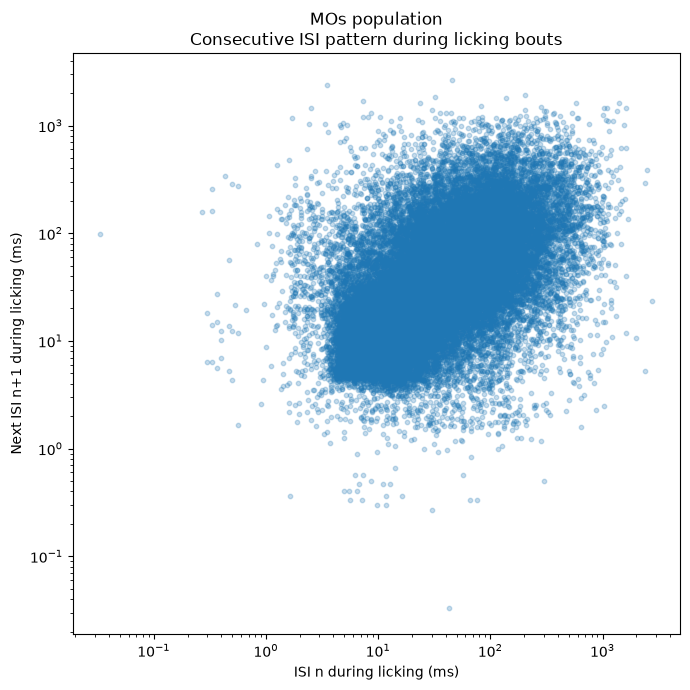

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Collect consecutive ISIs occurring
# during licking bouts from all MOs neurons
# ==========================================

isi_n_all = []
isi_next_all = []

for _, unit in motor_units.iterrows():

    spikes = np.asarray(unit["spike_times"])

    # --------------------------------------
    # Look separately inside each lick bout
    # --------------------------------------

    for bout in lick_bouts:

        bout_start = bout[0]
        bout_end = bout[-1]

        # spikes occurring during this bout
        bout_spikes = spikes[
            (spikes >= bout_start) &
            (spikes <= bout_end)
        ]

        # Need at least 3 spikes to get
        # ISI_n and ISI_n+1
        if len(bout_spikes) < 3:
            continue

        isi = np.diff(bout_spikes) * 1000  # ms

        isi_n_all.extend(isi[:-1])
        isi_next_all.extend(isi[1:])


isi_n_all = np.array(isi_n_all)
isi_next_all = np.array(isi_next_all)

print("Number of consecutive ISI pairs:", len(isi_n_all))


# ==========================================
# Joint ISI plot
# ==========================================

plt.figure(figsize=(7, 7))

plt.scatter(
    isi_n_all,
    isi_next_all,
    s=10,
    alpha=0.25
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("ISI n during licking (ms)")
plt.ylabel("Next ISI n+1 during licking (ms)")

plt.title(
    "MOs population\n"
    "Consecutive ISI pattern during licking bouts"
)

plt.tight_layout()
plt.show()

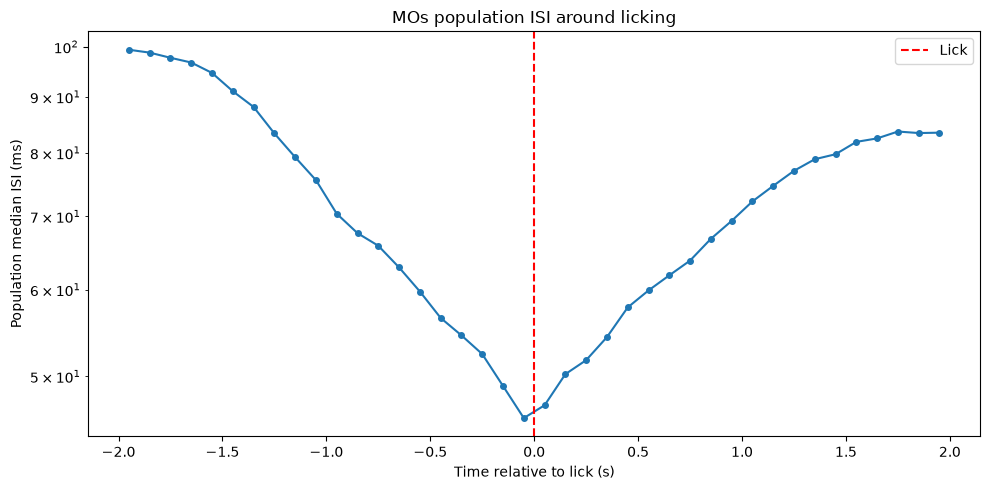

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Parameters
# ==========================================

window = 2.0          # seconds before/after lick
bin_size = 0.1        # 100 ms bins

bins = np.arange(-window, window + bin_size, bin_size)
bin_centers = (bins[:-1] + bins[1:]) / 2


# ==========================================
# Store ISI values from all MOs neurons
# ==========================================

population_isi = [[] for _ in range(len(bin_centers))]


# ==========================================
# Loop through all QC-passing MOs neurons
# ==========================================

for _, unit in motor_units.iterrows():

    spikes = np.asarray(unit["spike_times"])

    # keep task spikes only
    spikes = spikes[
        (spikes >= task_start) &
        (spikes < task_stop)
    ]

    if len(spikes) < 2:
        continue

    # ISI in milliseconds
    isi_ms = np.diff(spikes) * 1000

    # time associated with each ISI
    isi_times = spikes[:-1]


    # ======================================
    # Align to each lick
    # ======================================

    for lick_time in lick_times:

        relative_time = isi_times - lick_time

        event_mask = (
            (relative_time >= -window) &
            (relative_time <= window)
        )

        rel = relative_time[event_mask]
        values = isi_ms[event_mask]

        # put each ISI into its time bin
        inds = np.digitize(rel, bins) - 1

        for j, value in zip(inds, values):

            if 0 <= j < len(population_isi):
                population_isi[j].append(value)


# ==========================================
# Population median
# ==========================================

median_isi = np.array([
    np.median(x) if len(x) > 0 else np.nan
    for x in population_isi
])


# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    bin_centers,
    median_isi,
    marker="o",
    markersize=4
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    label="Lick"
)

plt.yscale("log")

plt.xlabel("Time relative to lick (s)")
plt.ylabel("Population median ISI (ms)")

plt.title("MOs population ISI around licking")

plt.legend()
plt.tight_layout()
plt.show()

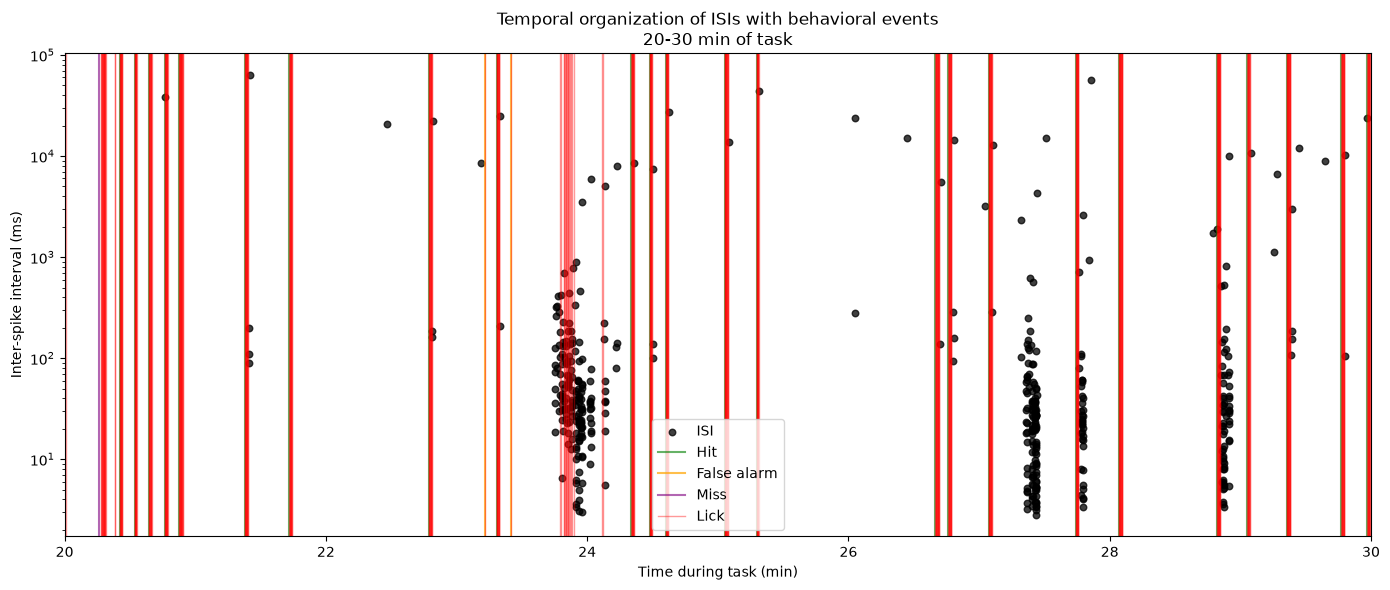

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Choose the 10-minute window
# ==========================================

start_min = 20
end_min = 30


# ==========================================
# ISI data
# ==========================================

# real_spikes should already be relative to task_start
isi_ms = np.diff(real_spikes) * 1000

# time of each ISI in minutes from task start
isi_time_min = real_spikes[:-1] / 60

# keep only ISIs inside selected 10-minute period
isi_mask = (
    (isi_time_min >= start_min) &
    (isi_time_min < end_min)
)


# ==========================================
# Behavioral event times
# ==========================================

# HIT:
# use response time
hit_times = (
    trials.loc[
        trials["is_hit"],
        "response_time"
    ]
    .dropna()
    .values
    - task_start
) / 60


# FALSE ALARM:
# use response time
fa_times = (
    trials.loc[
        trials["is_false_alarm"],
        "response_time"
    ]
    .dropna()
    .values
    - task_start
) / 60


# MISS:
# no response occurs, so use stimulus onset
miss_times = (
    trials.loc[
        trials["is_miss"],
        "stim_start_time"
    ]
    .dropna()
    .values
    - task_start
) / 60


# LICKS:
# likely_licks contains the detected likely licking events
lick_times_min = (
    likely_licks["timestamps"].values
    - task_start
) / 60


# ==========================================
# Keep only events within selected 10 min
# ==========================================

hit_times = hit_times[
    (hit_times >= start_min) &
    (hit_times < end_min)
]

fa_times = fa_times[
    (fa_times >= start_min) &
    (fa_times < end_min)
]

miss_times = miss_times[
    (miss_times >= start_min) &
    (miss_times < end_min)
]

lick_times_min = lick_times_min[
    (lick_times_min >= start_min) &
    (lick_times_min < end_min)
]


# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(14, 6))


# ISI = BLACK
plt.scatter(
    isi_time_min[isi_mask],
    isi_ms[isi_mask],
    s=22,
    alpha=0.75,
    color="black",
    label="ISI"
)


# HIT = GREEN
for i, t in enumerate(hit_times):

    plt.axvline(
        t,
        color="green",
        alpha=0.6,
        linewidth=1.5,
        label="Hit" if i == 0 else None
    )


# FALSE ALARM = ORANGE
for i, t in enumerate(fa_times):

    plt.axvline(
        t,
        color="orange",
        alpha=0.7,
        linewidth=1.5,
        label="False alarm" if i == 0 else None
    )


# MISS = PURPLE
for i, t in enumerate(miss_times):

    plt.axvline(
        t,
        color="purple",
        alpha=0.6,
        linewidth=1.5,
        label="Miss" if i == 0 else None
    )


# LICK = RED
for i, t in enumerate(lick_times_min):

    plt.axvline(
        t,
        color="red",
        alpha=0.4,
        linewidth=1.0,
        label="Lick" if i == 0 else None
    )


# ==========================================
# Figure formatting
# ==========================================

plt.yscale("log")

plt.xlim(
    start_min,
    end_min
)

plt.xlabel(
    "Time during task (min)"
)

plt.ylabel(
    "Inter-spike interval (ms)"
)

plt.title(
    f"Temporal organization of ISIs with behavioral events\n"
    f"{start_min}-{end_min} min of task"
)

plt.legend(
    loc="best"
)

plt.tight_layout()

plt.show()

In [40]:
# Same QC-passing MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

hit_x = []
hit_y = []

fa_x = []
fa_y = []

# Go through every trial
for _, trial in trials.iterrows():

    # Get spikes occurring WITHIN this trial
    trial_spikes = spikes[
        (spikes >= trial["start_time"]) &
        (spikes < trial["stop_time"])
    ]

    # Need at least 3 spikes to have ISI_n and ISI_n+1
    if len(trial_spikes) < 3:
        continue

    trial_isi = np.diff(trial_spikes) * 1000  # ms

    # Consecutive ISI pairs
    x = trial_isi[:-1]
    y = trial_isi[1:]

    # HIT
    if trial["is_hit"]:
        hit_x.extend(x)
        hit_y.extend(y)

    # FALSE ALARM
    elif trial["is_false_alarm"]:
        fa_x.extend(x)
        fa_y.extend(y)

In [17]:
# Get lick data
licks = nwbfile.processing["behavior"].data_interfaces["licks"][:]

likely_licks = licks[
    (licks["is_likely_lick"] == True) &
    (licks["timestamps"] >= task_start) &
    (licks["timestamps"] < task_stop)
].copy()

# Convert lick times to time relative to task start
lick_times_task = (
    likely_licks["timestamps"].values - task_start
)

print("Number of licks:", len(lick_times_task))

Number of licks: 1938


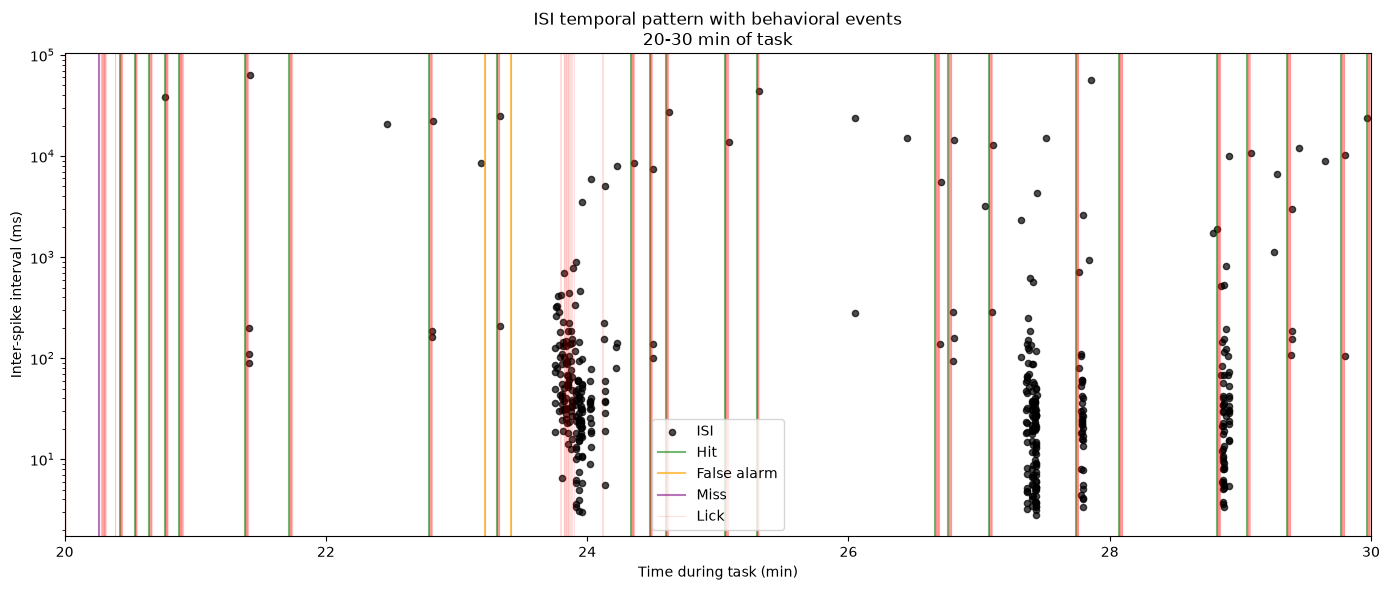

In [33]:
# Choose 10-minute window
start_min = 20
end_min = 30

# -----------------------------------
# ISI data
# -----------------------------------
isi_ms = np.diff(real_spikes) * 1000

# real_spikes are already relative to task start
isi_time_min = real_spikes[:-1] / 60

mask = (
    (isi_time_min >= start_min) &
    (isi_time_min < end_min)
)

# -----------------------------------
# Convert behavioral times to task-relative minutes
# -----------------------------------

hit_times = (
    trials.loc[trials["is_hit"], "response_time"].dropna().values
    - task_start
) / 60

fa_times = (
    trials.loc[trials["is_false_alarm"], "response_time"].dropna().values
    - task_start
) / 60

# Miss has no response, so use stimulus onset
miss_times = (
    trials.loc[trials["is_miss"], "stim_start_time"].dropna().values
    - task_start
) / 60

# Lick times
lick_times_min = (
    likely_licks["timestamps"].values
    - task_start
) / 60


# -----------------------------------
# Keep events inside selected 10 min
# -----------------------------------

hit_times = hit_times[
    (hit_times >= start_min) &
    (hit_times < end_min)
]

fa_times = fa_times[
    (fa_times >= start_min) &
    (fa_times < end_min)
]

miss_times = miss_times[
    (miss_times >= start_min) &
    (miss_times < end_min)
]

lick_times_min = lick_times_min[
    (lick_times_min >= start_min) &
    (lick_times_min < end_min)
]


# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(14, 6))

# ISIs
plt.scatter(
    isi_time_min[mask],
    isi_ms[mask],
    s=20,
    alpha=0.7,
    color="black",
    label="ISI"
)

# Behavioral events
for i, t in enumerate(hit_times):
    plt.axvline(
        t,
        color="green",
        alpha=0.55,
        linewidth=1.5,
        label="Hit" if i == 0 else None
    )

for i, t in enumerate(fa_times):
    plt.axvline(
        t,
        color="orange",
        alpha=0.65,
        linewidth=1.5,
        label="False alarm" if i == 0 else None
    )

for i, t in enumerate(miss_times):
    plt.axvline(
        t,
        color="purple",
        alpha=0.55,
        linewidth=1.5,
        label="Miss" if i == 0 else None
    )

for i, t in enumerate(lick_times_min):
    plt.axvline(
        t,
        color="red",
        alpha=0.12,
        linewidth=0.8,
        label="Lick" if i == 0 else None
    )


plt.yscale("log")

plt.xlim(start_min, end_min)

plt.xlabel("Time during task (min)")
plt.ylabel("Inter-spike interval (ms)")

plt.title(
    f"ISI temporal pattern with behavioral events\n"
    f"{start_min}-{end_min} min of task"
)

plt.legend()

plt.tight_layout()
plt.show()

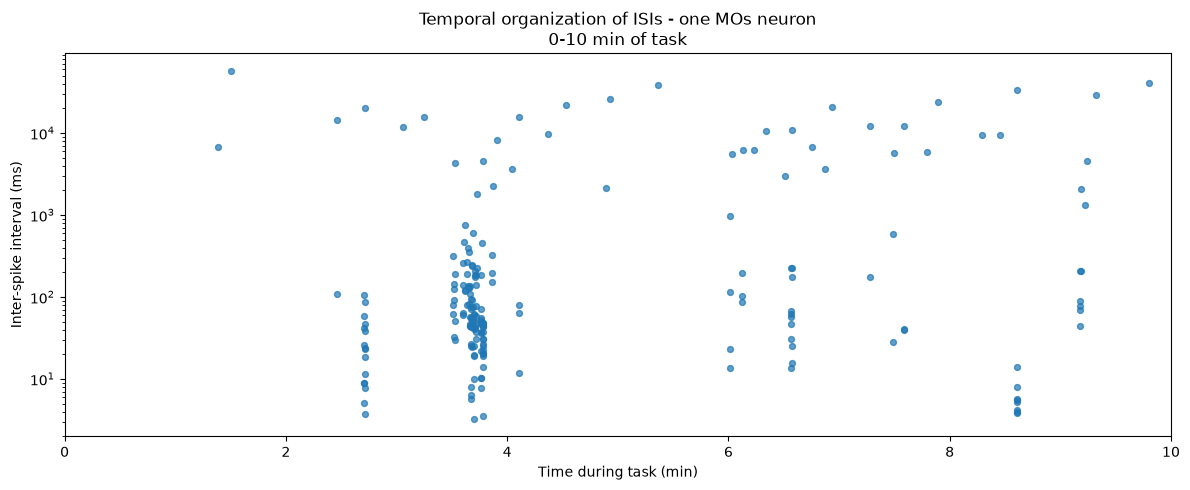

In [32]:
# Choose the 10-minute window
start_min = 0
end_min = 10

# ISIs
isi_ms = np.diff(real_spikes) * 1000

# Time at which each ISI occurred, relative to task start
isi_time_min = (real_spikes[:-1] - task_start) / 60

# Keep only ISIs occurring within the 10-minute window
mask = (
    (isi_time_min >= start_min) &
    (isi_time_min < end_min)
)

plt.figure(figsize=(12, 5))

plt.scatter(
    isi_time_min[mask],
    isi_ms[mask],
    s=18,
    alpha=0.7
)

plt.yscale("log")

plt.xlim(start_min, end_min)

plt.xlabel("Time during task (min)")
plt.ylabel("Inter-spike interval (ms)")
plt.title(
    f"Temporal organization of ISIs - one MOs neuron\n"
    f"{start_min}-{end_min} min of task"
)

plt.tight_layout()
plt.show()

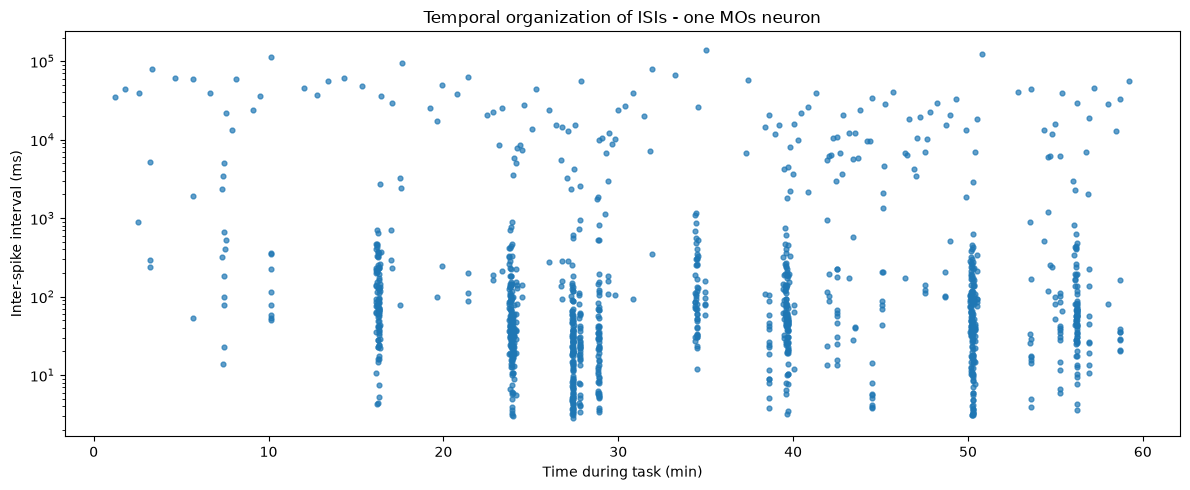

In [31]:
isi_ms = np.diff(real_spikes) * 1000

# Actual time associated with each ISI
isi_time = real_spikes[:-1]

plt.figure(figsize=(12, 5))

plt.scatter(
    isi_time / 60,
    isi_ms,
    s=12,
    alpha=0.7
)

plt.yscale("log")

plt.xlabel("Time during task (min)")
plt.ylabel("Inter-spike interval (ms)")

plt.title(
    "Temporal organization of ISIs - one MOs neuron"
)

plt.tight_layout()
plt.show()

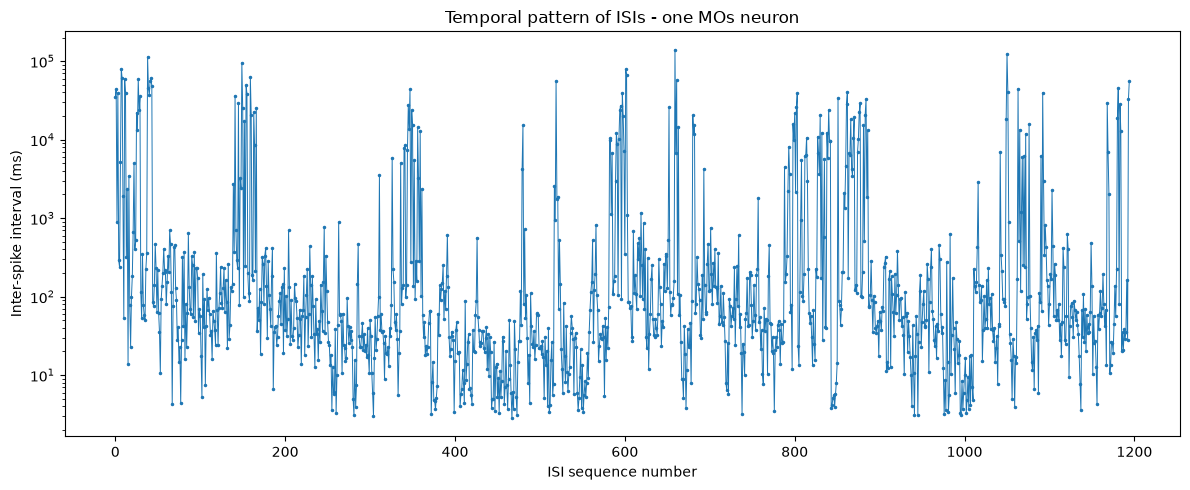

In [30]:
# ISIs of the real neuron
isi_ms = np.diff(real_spikes) * 1000

plt.figure(figsize=(12, 5))

plt.plot(
    np.arange(len(isi_ms)),
    isi_ms,
    marker=".",
    markersize=3,
    linewidth=0.7
)

plt.yscale("log")

plt.xlabel("ISI sequence number")
plt.ylabel("Inter-spike interval (ms)")
plt.title("Temporal pattern of ISIs - one MOs neuron")

plt.tight_layout()
plt.show()

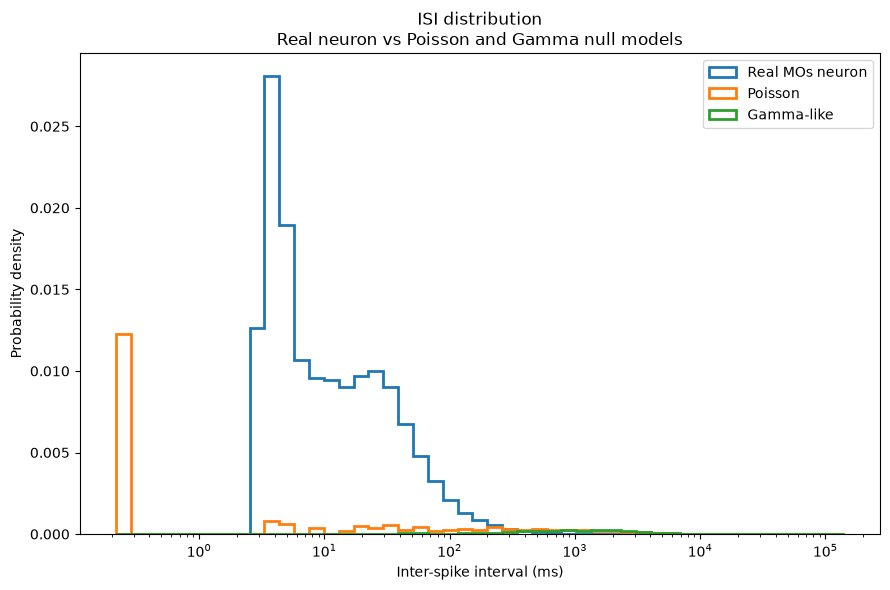

In [28]:
real_isi_ms = real_isi * 1000
poisson_isi_ms = poisson_isi * 1000
gamma_isi_ms = gamma_isi * 1000

all_isi = np.concatenate([
    real_isi_ms,
    poisson_isi_ms,
    gamma_isi_ms
])

bins = np.logspace(
    np.log10(all_isi.min()),
    np.log10(all_isi.max()),
    50
)

plt.figure(figsize=(9, 6))

plt.hist(
    real_isi_ms,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Real MOs neuron"
)

plt.hist(
    poisson_isi_ms,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Poisson"
)

plt.hist(
    gamma_isi_ms,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Gamma-like"
)

plt.xscale("log")

plt.xlabel("Inter-spike interval (ms)")
plt.ylabel("Probability density")

plt.title(
    "ISI distribution\nReal neuron vs Poisson and Gamma null models"
)

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Real neuron firing rate
rate = real_rate

# Simulate Poisson at twice the rate
rng = np.random.default_rng(42)

poisson2_isi = rng.exponential(
    scale=1 / (2 * rate),
    size=2 * len(real_isi)
)

# Convert ISIs to spike times
poisson2_spikes = np.cumsum(poisson2_isi)

# Keep only spikes that fall within the task duration
poisson2_spikes = poisson2_spikes[
    poisson2_spikes < task_duration
]

# Throw out every other spike
gamma_spikes = poisson2_spikes[::2]

# Calculate Gamma-like ISIs
gamma_isi = np.diff(gamma_spikes)

print("Real firing rate:", real_rate, "Hz")
print("Gamma-like firing rate:", len(gamma_spikes) / task_duration, "Hz")

print("Real mean ISI:", np.mean(real_isi), "s")
print("Gamma mean ISI:", np.mean(gamma_isi), "s")

Real firing rate: 0.32847063816825933 Hz
Gamma-like firing rate: 0.3238017411374396 Hz
Real mean ISI: 2.958888795105899 s
Gamma mean ISI: 3.084621583526043 s


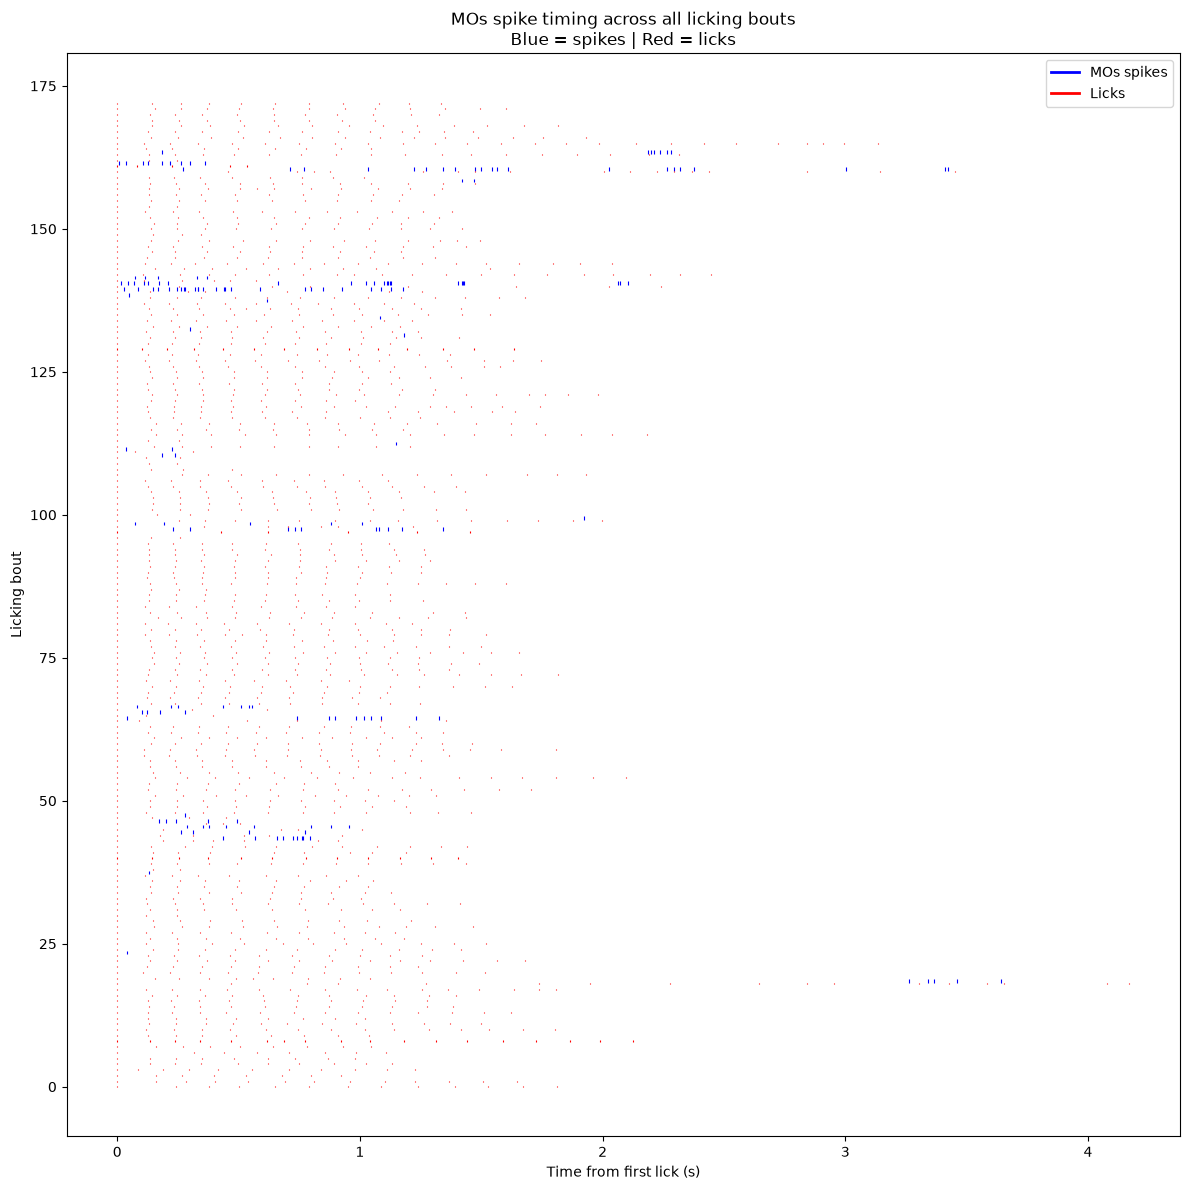

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

for row, bout in enumerate(lick_bouts):

    start = bout[0]
    end = bout[-1]

    # spikes from this neuron during this licking bout
    bout_spikes = spikes[
        (spikes >= start) &
        (spikes <= end)
    ]

    # align to first lick
    relative_licks = bout - start
    relative_spikes = bout_spikes - start

    # Blue = neuronal spikes
    plt.vlines(
        relative_spikes,
        row + 0.15,
        row + 0.80,
        color="blue",
        linewidth=0.8
    )

    # Red = lick times
    plt.vlines(
        relative_licks,
        row - 0.10,
        row + 0.08,
        color="red",
        linewidth=0.8
    )

# legend
plt.plot([], [], color="blue", linewidth=2, label="MOs spikes")
plt.plot([], [], color="red", linewidth=2, label="Licks")

plt.xlabel("Time from first lick (s)")
plt.ylabel("Licking bout")

plt.title(
    "MOs spike timing across all licking bouts\n"
    "Blue = spikes | Red = licks"
)

plt.legend()

plt.tight_layout()
plt.show()

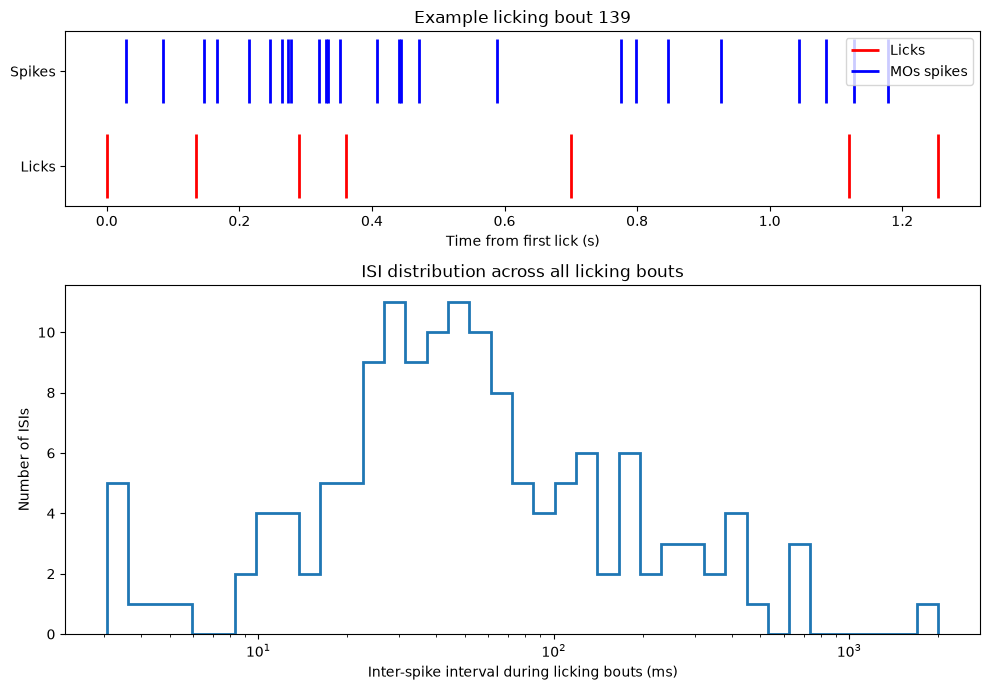

In [25]:
# Choose one active licking bout
bout_number = 139
bout = lick_bouts[bout_number]

bout_spikes = spikes[
    (spikes >= bout[0]) &
    (spikes <= bout[-1])
]

relative_licks = bout - bout[0]
relative_spikes = bout_spikes - bout[0]

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    gridspec_kw={"height_ratios": [1, 2]}
)

# -----------------------------
# TOP: licking + spikes
# -----------------------------
axes[0].vlines(
    relative_licks,
    0.0, 0.4,
    color="red",
    linewidth=2,
    label="Licks"
)

axes[0].vlines(
    relative_spikes,
    0.6, 1.0,
    color="blue",
    linewidth=2,
    label="MOs spikes"
)

axes[0].set_yticks(
    [0.2, 0.8],
    ["Licks", "Spikes"]
)

axes[0].set_xlabel("Time from first lick (s)")
axes[0].set_title(
    f"Example licking bout {bout_number}"
)

axes[0].legend()


# -----------------------------
# BOTTOM: ISI histogram
# -----------------------------
bins = np.logspace(
    np.log10(lick_isi.min()),
    np.log10(lick_isi.max()),
    40
)

axes[1].hist(
    lick_isi,
    bins=bins,
    histtype="step",
    linewidth=2
)

axes[1].set_xscale("log")

axes[1].set_xlabel(
    "Inter-spike interval during licking bouts (ms)"
)

axes[1].set_ylabel("Number of ISIs")

axes[1].set_title(
    "ISI distribution across all licking bouts"
)

plt.tight_layout()
plt.show()

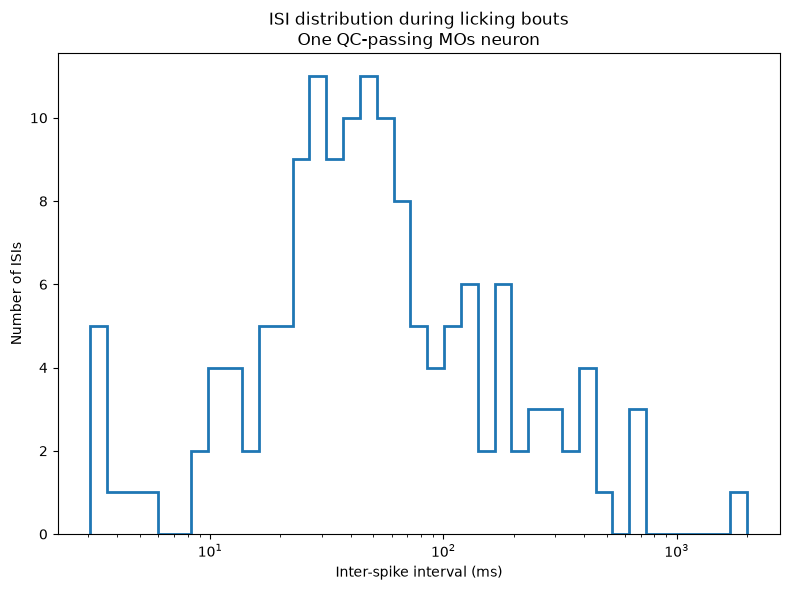

In [24]:
# Log-spaced bins
bins = np.logspace(
    np.log10(lick_isi.min()),
    np.log10(lick_isi.max()),
    40
)

plt.figure(figsize=(8, 6))

plt.hist(
    lick_isi,
    bins=bins,
    histtype="step",
    linewidth=2
)

plt.xscale("log")

plt.xlabel("Inter-spike interval (ms)")
plt.ylabel("Number of ISIs")

plt.title(
    "ISI distribution during licking bouts\n"
    "One QC-passing MOs neuron"
)

plt.tight_layout()
plt.show()

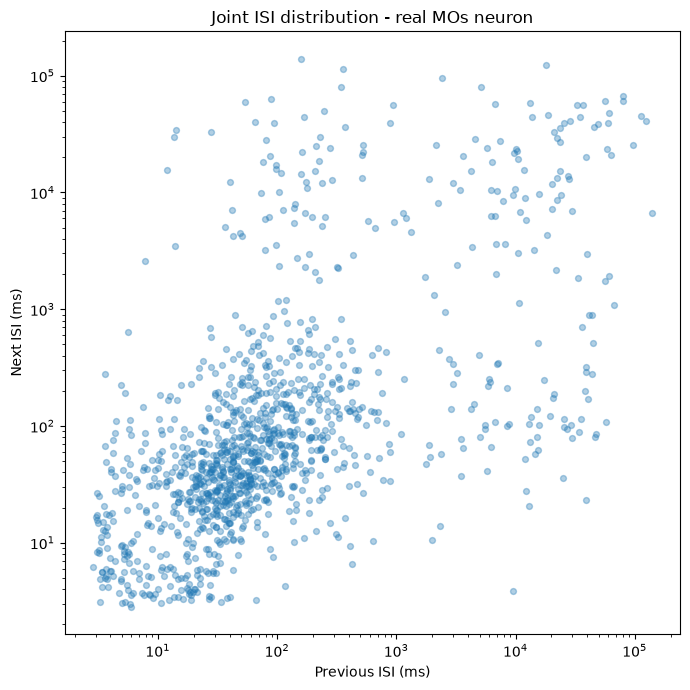

In [16]:
# ISIs in milliseconds
isi_ms = np.diff(real_spikes) * 1000

# Previous ISI and next ISI
previous_isi = isi_ms[:-1]
next_isi = isi_ms[1:]

plt.figure(figsize=(7, 7))

plt.scatter(
    previous_isi,
    next_isi,
    s=18,
    alpha=0.35
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Previous ISI (ms)")
plt.ylabel("Next ISI (ms)")

plt.title(
    "Joint ISI distribution - real MOs neuron"
)

plt.tight_layout()
plt.show()

In [23]:
# Collect ISIs occurring entirely within licking bouts

lick_isi = []

for bout in lick_bouts:

    start = bout[0]
    end = bout[-1]

    # spikes from this neuron during this licking bout
    bout_spikes = spikes[
        (spikes >= start) &
        (spikes <= end)
    ]

    # Calculate ISIs ONLY within this bout
    if len(bout_spikes) >= 2:
        isi = np.diff(bout_spikes) * 1000  # ms
        lick_isi.extend(isi)

lick_isi = np.array(lick_isi)

print("Number of ISIs during licking bouts:", len(lick_isi))

Number of ISIs during licking bouts: 145


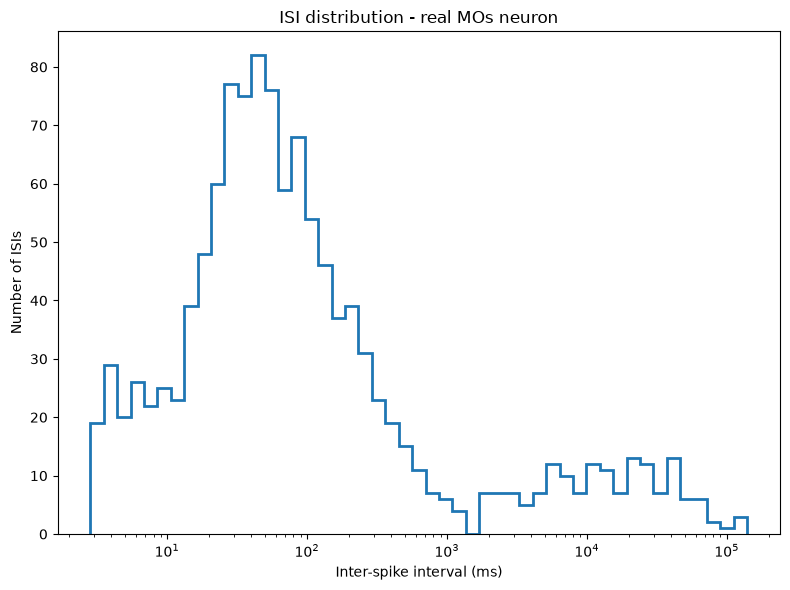

In [22]:
# ISI in milliseconds
real_isi_ms = real_isi * 1000

# Log-spaced bins
bins = np.logspace(
    np.log10(real_isi_ms.min()),
    np.log10(real_isi_ms.max()),
    50
)

plt.figure(figsize=(8, 6))

plt.hist(
    real_isi_ms,
    bins=bins,
    histtype="step",
    linewidth=2
)

plt.xscale("log")

plt.xlabel("Inter-spike interval (ms)")
plt.ylabel("Number of ISIs")

plt.title(
    "ISI distribution - real MOs neuron"
)

plt.tight_layout()
plt.show()

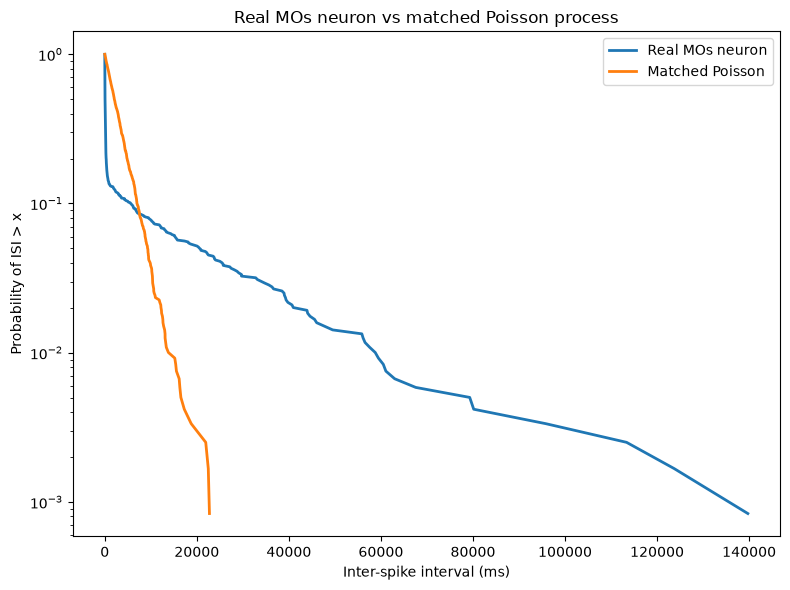

In [15]:
def survival_curve(isi):
    x = np.sort(isi)
    y = 1 - np.arange(1, len(x) + 1) / (len(x) + 1)
    return x, y


real_x, real_y = survival_curve(real_isi)
poisson_x, poisson_y = survival_curve(poisson_isi)


plt.figure(figsize=(8, 6))

plt.semilogy(
    real_x * 1000,
    real_y,
    label="Real MOs neuron",
    linewidth=2
)

plt.semilogy(
    poisson_x * 1000,
    poisson_y,
    label="Matched Poisson",
    linewidth=2
)

plt.xlabel("Inter-spike interval (ms)")
plt.ylabel("Probability of ISI > x")

plt.title(
    "Real MOs neuron vs matched Poisson process"
)

plt.legend()
plt.tight_layout()
plt.show()

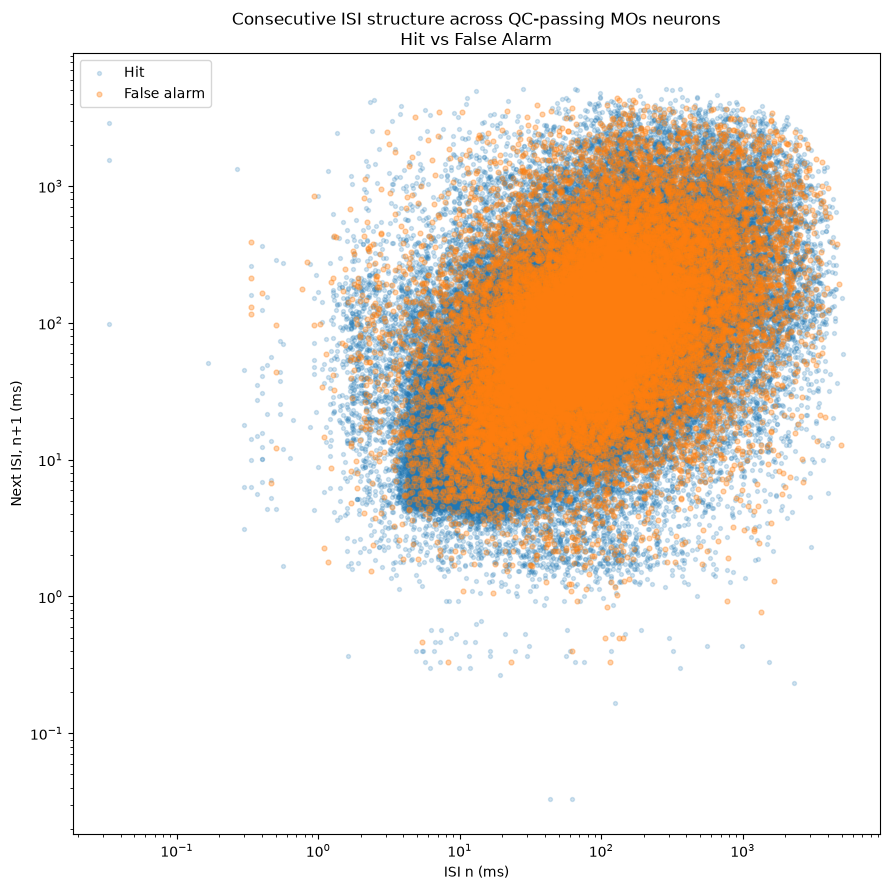

In [44]:
plt.figure(figsize=(9, 9))

plt.scatter(
    hit_x_all,
    hit_y_all,
    s=8,
    alpha=0.20,
    label="Hit"
)

plt.scatter(
    fa_x_all,
    fa_y_all,
    s=12,
    alpha=0.35,
    label="False alarm"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("ISI n (ms)")
plt.ylabel("Next ISI, n+1 (ms)")

plt.title(
    "Consecutive ISI structure across QC-passing MOs neurons\n"
    "Hit vs False Alarm"
)

plt.legend()

plt.tight_layout()
plt.show()

In [14]:
rng = np.random.default_rng(42)

poisson_isi = rng.exponential(
    scale=1 / real_rate,
    size=len(real_isi)
)

print("Real mean ISI:", np.mean(real_isi), "s")
print("Poisson mean ISI:", np.mean(poisson_isi), "s")

Real mean ISI: 2.958888795105899 s
Poisson mean ISI: 3.062190871106088 s


In [13]:
# Task period
task_start = 2155.69515
task_stop  = 5796.812075

task_duration = task_stop - task_start

# Select one MOs neuron
unit = motor_units.iloc[0]

spikes = unit["spike_times"]

# Keep only spikes during task
real_spikes = spikes[
    (spikes >= task_start) &
    (spikes < task_stop)
]

# Convert to time from task start
real_spikes = real_spikes - task_start

# Calculate firing rate
real_rate = len(real_spikes) / task_duration

# Calculate ISIs
real_isi = np.diff(real_spikes)

print("Unit ID:", unit["unit_id"])
print("Task duration:", task_duration, "seconds")
print("Number of spikes:", len(real_spikes))
print("Mean firing rate:", real_rate, "Hz")
print("Number of ISIs:", len(real_isi))

Unit ID: 759434_2025-02-04_E-175
Task duration: 3641.116925 seconds
Number of spikes: 1196
Mean firing rate: 0.32847063816825933 Hz
Number of ISIs: 1195


In [12]:
all_units = nwbfile.units[:]

motor_units = all_units[
    (all_units["structure"] == "MOs") &
    (all_units["is_qc_pass"] == True)
].copy()

print("All units:", len(all_units))
print("QC-passing MOs units:", len(motor_units))

All units: 2285
QC-passing MOs units: 70


In [83]:
inter_lick_interval = np.diff(lick_times)

# Restrict to intervals within licking bouts
bout_ili = inter_lick_interval[
    inter_lick_interval < 0.5
]

median_ili = np.median(bout_ili)
lick_frequency = 1 / median_ili

print("Median inter-lick interval:", median_ili, "s")
print("Estimated licking frequency:", lick_frequency, "Hz")

Median inter-lick interval: 0.12906000000020867 s
Estimated licking frequency: 7.748334108154216 Hz


In [11]:
import pynwb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nwb_path = "/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr"

nwbfile = pynwb.read_nwb(nwb_path)

print("NWB loaded")

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


NWB loaded


QC-passing MOs neurons: 70
     bout  n_licks  duration  n_spikes
139   139        7   1.25455        26
140   140        8   2.24094        23
160   160       18   3.45300        21
64     64        6   1.35640        10
97     97        6   1.45449        10
161   161        5   0.53318         9
43     43        7   0.90936         9
45     45        5   1.01029         8
66     66        3   0.61523         7
163   163       18   2.31575         7


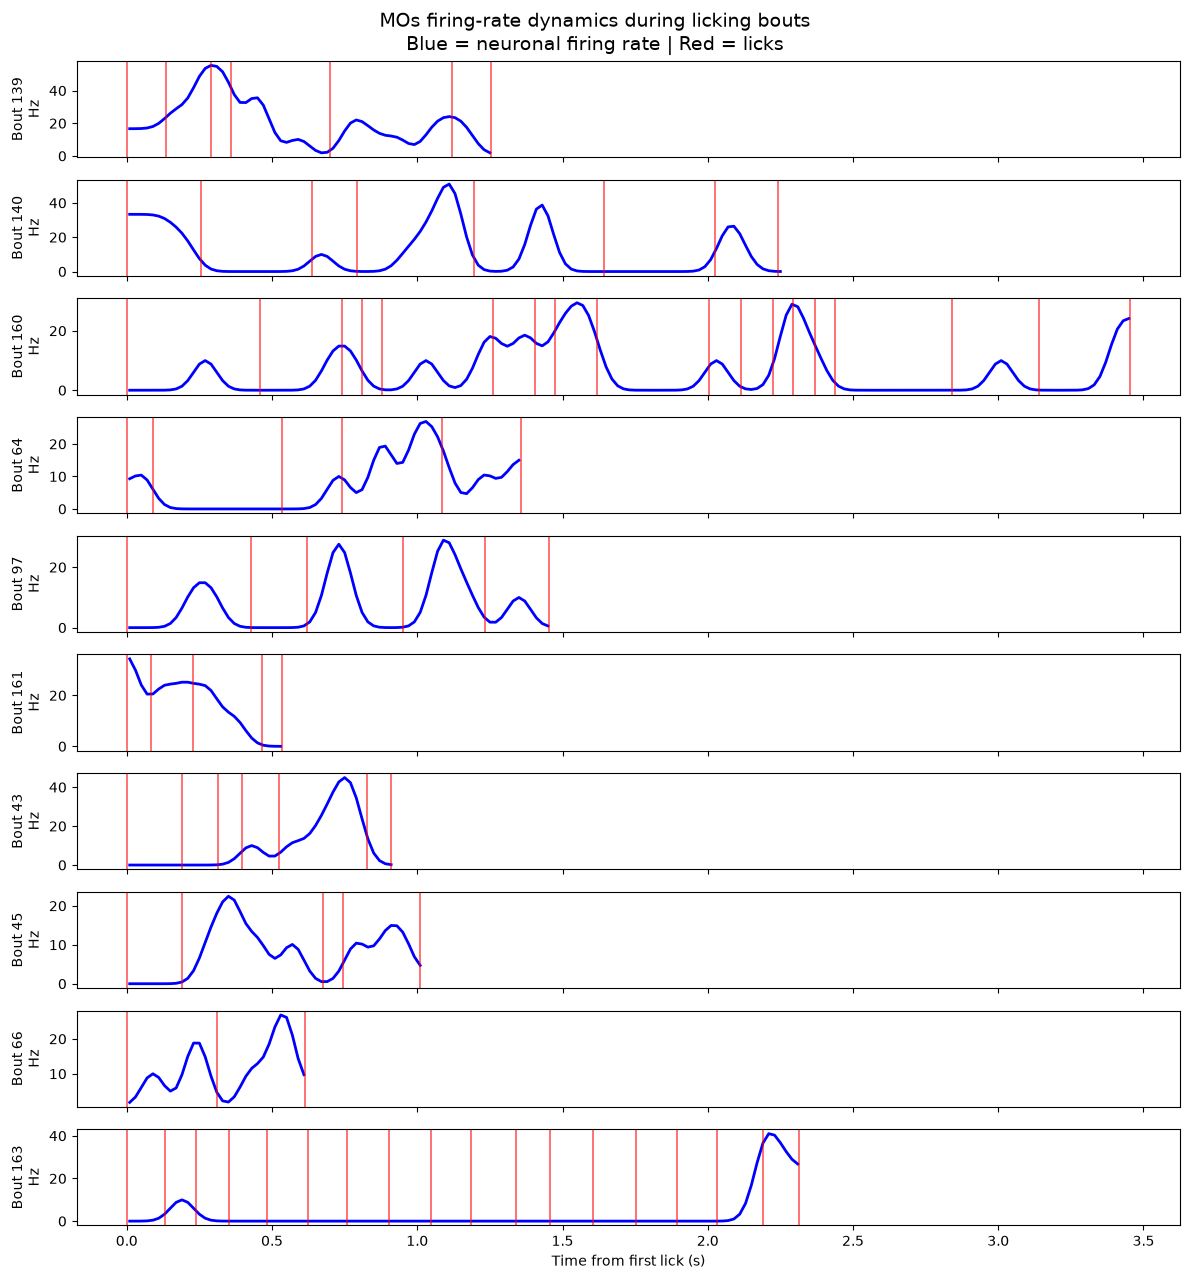

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


# =========================================================
# 1. QC-passing MOs neurons
# =========================================================

all_units = nwbfile.units[:]

motor_units = all_units[
    (all_units["structure"] == "MOs") &
    (all_units["is_qc_pass"] == True)
].copy()

# Same choice: first QC-passing MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

print("QC-passing MOs neurons:", len(motor_units))


# =========================================================
# 2. Task period
# =========================================================

task_start = 2155.69515
task_stop  = 5796.812075


# =========================================================
# 3. Get likely licks
# =========================================================

licks = nwbfile.processing["behavior"].data_interfaces["licks"][:]

likely_licks = licks[
    (licks["is_likely_lick"] == True) &
    (licks["timestamps"] >= task_start) &
    (licks["timestamps"] < task_stop)
].copy()

lick_times = likely_licks["timestamps"].values


# =========================================================
# 4. Define licking bouts
# =========================================================

bout_gap = 0.5

lick_ili = np.diff(lick_times)

bout_starts = np.r_[
    0,
    np.where(lick_ili > bout_gap)[0] + 1
]

bout_ends = np.r_[
    np.where(lick_ili > bout_gap)[0],
    len(lick_times) - 1
]

lick_bouts = []

for start_idx, end_idx in zip(bout_starts, bout_ends):

    bout = lick_times[start_idx:end_idx + 1]

    if len(bout) >= 3:
        lick_bouts.append(bout)


# =========================================================
# 5. Count spikes in each licking bout
# =========================================================

bout_results = []

for i, bout in enumerate(lick_bouts):

    bout_spikes = spikes[
        (spikes >= bout[0]) &
        (spikes <= bout[-1])
    ]

    bout_results.append({
        "bout": i,
        "n_licks": len(bout),
        "duration": bout[-1] - bout[0],
        "n_spikes": len(bout_spikes)
    })

bout_info = pd.DataFrame(bout_results)

top_bouts = bout_info.sort_values(
    "n_spikes",
    ascending=False
).head(10)

print(top_bouts)


# =========================================================
# 6. Plot firing-rate dynamics during top 10 licking bouts
# =========================================================

bin_size = 0.02   # 20 ms
sigma = 2

fig, axes = plt.subplots(
    10,
    1,
    figsize=(12, 13),
    sharex=True
)

for ax, (_, info) in zip(
    axes,
    top_bouts.iterrows()
):

    bout_number = int(info["bout"])
    bout = lick_bouts[bout_number]

    start = bout[0]
    end = bout[-1]

    # spikes during bout
    bout_spikes = spikes[
        (spikes >= start) &
        (spikes <= end)
    ]

    # relative time
    rel_spikes = bout_spikes - start
    rel_licks = bout - start

    # histogram of spikes
    bins = np.arange(
        0,
        end - start + bin_size,
        bin_size
    )

    counts, edges = np.histogram(
        rel_spikes,
        bins=bins
    )

    # firing rate
    firing_rate = counts / bin_size

    # smooth it to reveal temporal pattern
    smooth_rate = gaussian_filter1d(
        firing_rate,
        sigma=sigma
    )

    time_axis = (
        edges[:-1] + edges[1:]
    ) / 2

    # BLUE = neuronal firing
    ax.plot(
        time_axis,
        smooth_rate,
        color="blue",
        linewidth=2
    )

    # RED = licking
    for lick in rel_licks:
        ax.axvline(
            lick,
            color="red",
            linewidth=1.2,
            alpha=0.65
        )

    ax.set_ylabel(
        f"Bout {bout_number}\nHz"
    )


axes[-1].set_xlabel(
    "Time from first lick (s)"
)

fig.suptitle(
    "MOs firing-rate dynamics during licking bouts\n"
    "Blue = neuronal firing rate | Red = licks",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [9]:
licks = nwbfile.processing["behavior"].data_interfaces["licks"][:]

likely_licks = licks[
    (licks["is_likely_lick"] == True) &
    (licks["timestamps"] >= task_start) &
    (licks["timestamps"] < task_stop)
].copy()

lick_times = likely_licks["timestamps"].values

print("Likely licks during task:", len(lick_times))

Likely licks during task: 1938


In [6]:
import pynwb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

nwb_path = "/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr"

nwbfile = pynwb.read_nwb(nwb_path)

print(nwbfile)

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


root pynwb.file.NWBFile at 0x140376968355792
Fields:
  acquisition: {
    frametimes_eye_camera <class 'hdmf.common.table.DynamicTable'>,
    frametimes_front_camera <class 'hdmf.common.table.DynamicTable'>,
    frametimes_side_camera <class 'hdmf.common.table.DynamicTable'>,
    manipulator_positions <class 'hdmf.common.table.DynamicTable'>
  }
  devices: {
    17131307152 <class 'pynwb.device.Device'>,
    17216703422 <class 'pynwb.device.Device'>,
    18005120322 <class 'pynwb.device.Device'>,
    20097906862 <class 'pynwb.device.Device'>,
    22175718152 <class 'pynwb.device.Device'>,
    SN40902 <class 'pynwb.device.Device'>,
    SN40903 <class 'pynwb.device.Device'>,
    SN40907 <class 'pynwb.device.Device'>,
    SN40908 <class 'pynwb.device.Device'>,
    SN41084 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    probeB <class 'pynwb.ecephys.ElectrodeGroup'>,
    probeC <class 'pynwb.ecephys.ElectrodeGroup'>,
    probeD <class 'pynwb.ecephys.ElectrodeGroup'>,
    probeE 

In [8]:
epochs = nwbfile.intervals["epochs"][:]

task_start = 2155.69515
task_stop = 5796.812075

In [7]:
all_units = nwbfile.units[:]

motor_units = all_units[
    (all_units["structure"] == "MOs") &
    (all_units["is_qc_pass"] == True)
].copy()

print("QC-passing MOs neurons:", len(motor_units))

QC-passing MOs neurons: 70


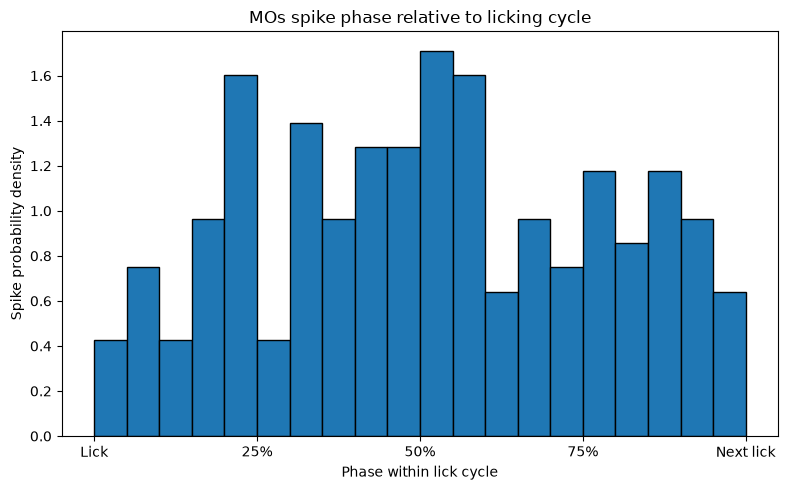

In [85]:
plt.figure(figsize=(8, 5))

plt.hist(
    spike_phases,
    bins=np.linspace(0, 1, 21),
    density=True,
    edgecolor="black"
)

plt.xlabel("Phase within lick cycle")
plt.ylabel("Spike probability density")

plt.title(
    "MOs spike phase relative to licking cycle"
)

plt.xticks(
    [0, 0.25, 0.5, 0.75, 1],
    ["Lick", "25%", "50%", "75%", "Next lick"]
)

plt.tight_layout()
plt.show()

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Same QC-passing MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

spike_phases = []

for i in range(len(lick_times) - 1):

    lick1 = lick_times[i]
    lick2 = lick_times[i + 1]

    cycle_duration = lick2 - lick1

    # Only cycles within licking bouts
    if cycle_duration >= 0.5:
        continue

    # Spikes occurring between these two licks
    cycle_spikes = spikes[
        (spikes >= lick1) &
        (spikes < lick2)
    ]

    # Convert each spike time to phase: 0 -> 1
    phases = (
        (cycle_spikes - lick1) /
        cycle_duration
    )

    spike_phases.extend(phases)

spike_phases = np.array(spike_phases)

print("Number of spikes during lick cycles:", len(spike_phases))

Number of spikes during lick cycles: 187


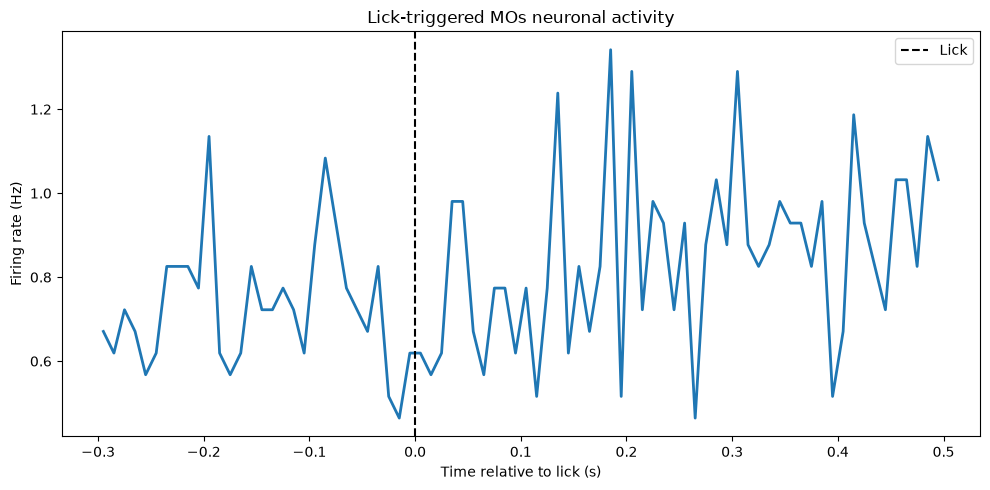

In [82]:
plt.figure(figsize=(10, 5))

plt.plot(
    bin_centers,
    psth,
    linewidth=2
)

plt.axvline(
    0,
    linestyle="--",
    color="black",
    label="Lick"
)

plt.xlabel("Time relative to lick (s)")
plt.ylabel("Firing rate (Hz)")

plt.title(
    "Lick-triggered MOs neuronal activity"
)

plt.legend()
plt.tight_layout()
plt.show()

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# Same MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

# Use likely lick times during task
lick_times = likely_licks["timestamps"].values

# Window around each lick
pre = 0.30    # 300 ms before lick
post = 0.50   # 500 ms after lick

bin_size = 0.01   # 10 ms bins

bins = np.arange(-pre, post + bin_size, bin_size)
bin_centers = (bins[:-1] + bins[1:]) / 2

all_relative_spikes = []

for lick in lick_times:

    rel_spikes = spikes[
        (spikes >= lick - pre) &
        (spikes < lick + post)
    ] - lick

    all_relative_spikes.extend(rel_spikes)

all_relative_spikes = np.array(all_relative_spikes)

# Histogram
counts, _ = np.histogram(
    all_relative_spikes,
    bins=bins
)

# Convert to firing rate:
# spikes / number of licks / bin duration
psth = counts / (len(lick_times) * bin_size)

print("Number of licks:", len(lick_times))
print("Number of aligned spikes:", len(all_relative_spikes))

Number of licks: 1938
Number of aligned spikes: 1249


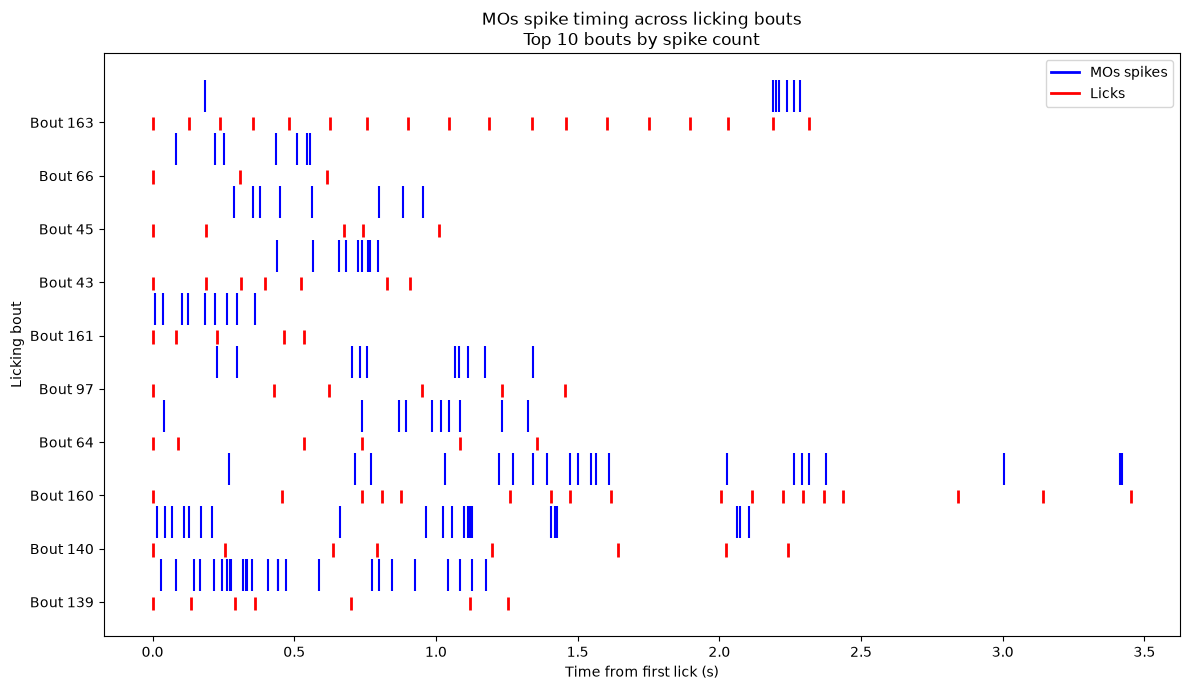

In [80]:
# Sort bouts by number of spikes
top_bouts = bout_info.sort_values(
    "n_spikes",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

for row, (_, info) in enumerate(top_bouts.iterrows()):

    bout_number = int(info["bout"])
    bout = lick_bouts[bout_number]

    # Spikes during this licking bout
    bout_spikes = spikes[
        (spikes >= bout[0]) &
        (spikes <= bout[-1])
    ]

    # Align to first lick
    relative_spikes = bout_spikes - bout[0]
    relative_licks = bout - bout[0]

    # --------------------
    # NEURONAL SPIKES
    # --------------------
    plt.vlines(
        relative_spikes,
        row + 0.20,
        row + 0.80,
        color="blue",
        linewidth=1.5
    )

    # --------------------
    # LICKS
    # --------------------
    plt.vlines(
        relative_licks,
        row - 0.15,
        row + 0.10,
        color="red",
        linewidth=2
    )


# Add legend manually
plt.plot([], [], color="blue", linewidth=2, label="MOs spikes")
plt.plot([], [], color="red", linewidth=2, label="Licks")

plt.xlabel("Time from first lick (s)")
plt.ylabel("Licking bout")

plt.yticks(
    range(len(top_bouts)),
    [f"Bout {int(x)}" for x in top_bouts["bout"]]
)

plt.title(
    "MOs spike timing across licking bouts\n"
    "Top 10 bouts by spike count"
)

plt.legend()

plt.tight_layout()
plt.show()

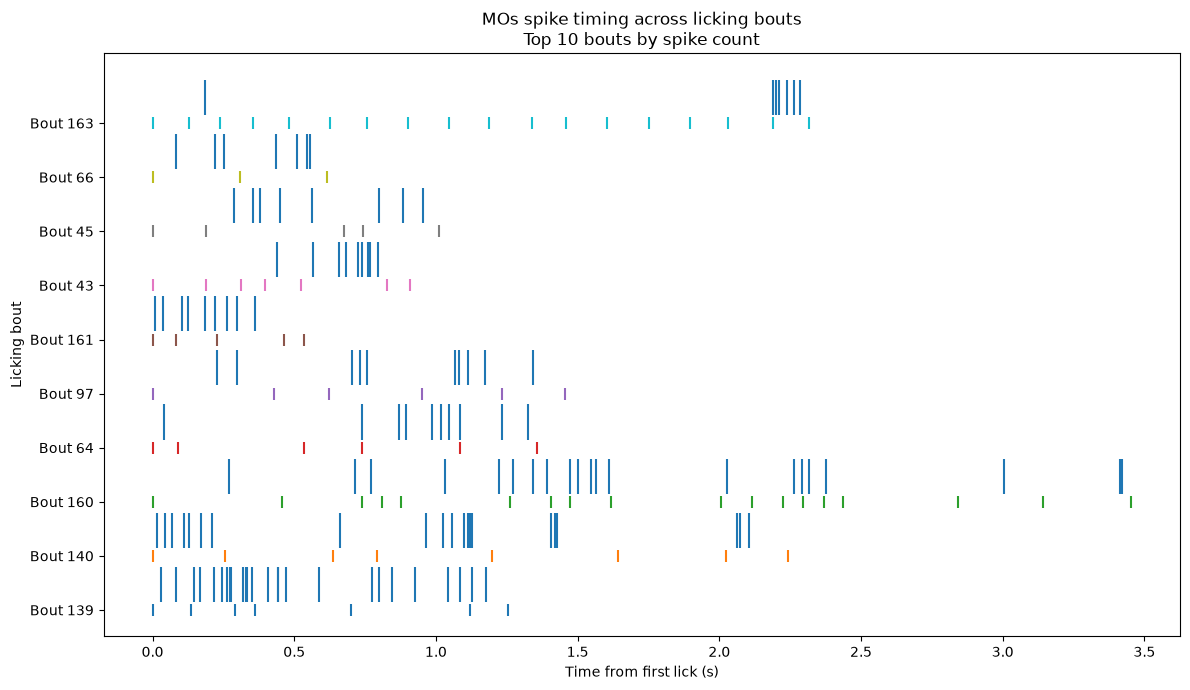

In [79]:
# Sort bouts by number of spikes in this neuron
top_bouts = bout_info.sort_values(
    "n_spikes",
    ascending=False
).head(10)

plt.figure(figsize=(12, 7))

for row, (_, info) in enumerate(top_bouts.iterrows()):

    bout_number = int(info["bout"])
    bout = lick_bouts[bout_number]

    # spikes during this lick bout
    bout_spikes = spikes[
        (spikes >= bout[0]) &
        (spikes <= bout[-1])
    ]

    # align everything to first lick
    relative_spikes = bout_spikes - bout[0]
    relative_licks = bout - bout[0]

    # neuronal spikes
    plt.vlines(
        relative_spikes,
        row + 0.15,
        row + 0.8,
        linewidth=1.5
    )

    # lick times as small marks below spikes
    plt.scatter(
        relative_licks,
        np.full(len(relative_licks), row),
        marker="|",
        s=80
    )

plt.xlabel("Time from first lick (s)")
plt.ylabel("Licking bout")

plt.yticks(
    range(len(top_bouts)),
    [f"Bout {int(x)}" for x in top_bouts["bout"]]
)

plt.title(
    "MOs spike timing across licking bouts\n"
    "Top 10 bouts by spike count"
)

plt.tight_layout()
plt.show()

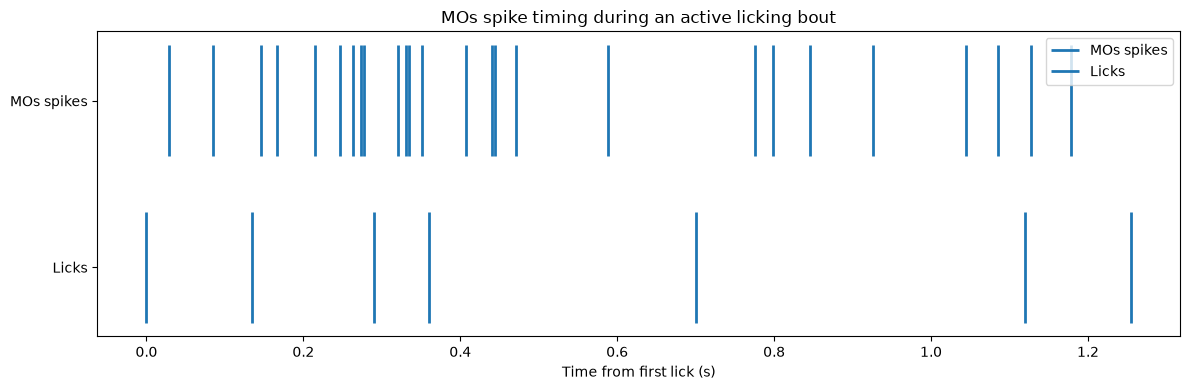

In [78]:
plt.figure(figsize=(12, 4))

# neuronal spikes
plt.vlines(
    relative_spikes,
    0.6, 1.0,
    linewidth=2,
    label="MOs spikes"
)

# licks
plt.vlines(
    relative_licks,
    0.0, 0.4,
    linewidth=2,
    label="Licks"
)

plt.yticks(
    [0.2, 0.8],
    ["Licks", "MOs spikes"]
)

plt.xlabel("Time from first lick (s)")
plt.title(
    "MOs spike timing during an active licking bout"
)

plt.legend()
plt.tight_layout()
plt.show()

In [77]:
best_bout_number = int(
    bout_info.sort_values(
        "n_spikes",
        ascending=False
    ).iloc[0]["bout"]
)

bout = lick_bouts[best_bout_number]

plot_start = bout[0]
plot_end = bout[-1]

bout_spikes = spikes[
    (spikes >= plot_start) &
    (spikes <= plot_end)
]

relative_licks = bout - bout[0]
relative_spikes = bout_spikes - bout[0]

print("Bout:", best_bout_number)
print("Number of licks:", len(bout))
print("Number of spikes:", len(bout_spikes))
print("Duration:", bout[-1] - bout[0])

Bout: 139
Number of licks: 7
Number of spikes: 26
Duration: 1.2545500000005632


In [76]:
# Same MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

bout_info = []

for i, bout in enumerate(lick_bouts):

    start = bout[0]
    end = bout[-1]

    bout_spikes = spikes[
        (spikes >= start) &
        (spikes <= end)
    ]

    bout_info.append({
        "bout": i,
        "n_licks": len(bout),
        "duration": end - start,
        "n_spikes": len(bout_spikes)
    })

bout_info = pd.DataFrame(bout_info)

bout_info.sort_values(
    "n_spikes",
    ascending=False
).head(10)

,bout,n_licks,duration,n_spikes
139,139,7,1.25455,26
140,140,8,2.24094,23
160,160,18,3.45300,21
64,64,6,1.35640,10
97,97,6,1.45449,10
161,161,5,0.53318,9
43,43,7,0.90936,9
45,45,5,1.01029,8
66,66,3,0.61523,7
163,163,18,2.31575,7


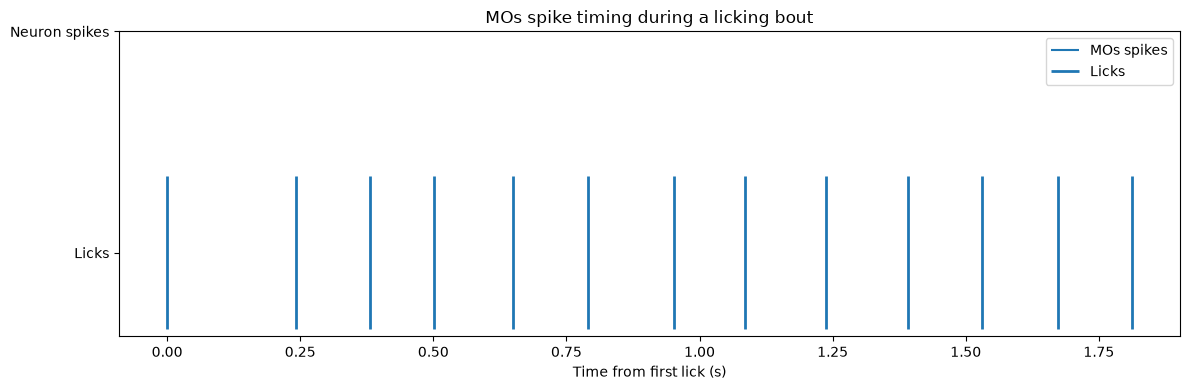

In [75]:
# Same QC-passing MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

# choose a lick bout
bout = lick_bouts[0]

# add a little space before and after the bout
plot_start = bout[0] - 0.5
plot_end = bout[-1] + 0.5

bout_spikes = spikes[
    (spikes >= plot_start) &
    (spikes <= plot_end)
]

# make times relative to first lick
relative_licks = bout - bout[0]
relative_spikes = bout_spikes - bout[0]

plt.figure(figsize=(12, 4))

# spikes
plt.vlines(
    relative_spikes,
    0.55, 1.0,
    linewidth=1.5,
    label="MOs spikes"
)

# licks
plt.vlines(
    relative_licks,
    0.0, 0.4,
    linewidth=2,
    label="Licks"
)

plt.yticks(
    [0.2, 0.78],
    ["Licks", "Neuron spikes"]
)

plt.xlabel("Time from first lick (s)")
plt.title("MOs spike timing during a licking bout")

plt.legend()
plt.tight_layout()
plt.show()

In [74]:
bout_gap = 0.5  # seconds

lick_ili = np.diff(lick_times)

bout_starts = np.r_[0, np.where(lick_ili > bout_gap)[0] + 1]
bout_ends = np.r_[np.where(lick_ili > bout_gap)[0], len(lick_times) - 1]

lick_bouts = []

for start_idx, end_idx in zip(bout_starts, bout_ends):

    bout = lick_times[start_idx:end_idx + 1]

    # keep bouts with at least 3 licks
    if len(bout) >= 3:
        lick_bouts.append(bout)

print("Number of lick bouts:", len(lick_bouts))

for i, bout in enumerate(lick_bouts[:10]):
    print(
        i,
        "licks:", len(bout),
        "duration:", bout[-1] - bout[0]
    )

Number of lick bouts: 173
0 licks: 13 duration: 1.8117999999999483
1 licks: 13 duration: 1.6476800000000367
2 licks: 8 duration: 0.922360000000026
3 licks: 11 duration: 1.2255700000000616
4 licks: 10 duration: 1.1315500000000611
5 licks: 9 duration: 0.9804100000001199
6 licks: 8 duration: 1.107459999999719
7 licks: 9 duration: 1.047479999999723
8 licks: 18 duration: 2.123790000000099
9 licks: 9 duration: 1.0363499999998567


In [73]:
likely_licks = licks[
    (licks["is_likely_lick"] == True) &
    (licks["timestamps"] >= task_start) &
    (licks["timestamps"] < task_stop)
].copy()

lick_times = likely_licks["timestamps"].values

print("Likely licks during task:", len(lick_times))
print("First lick times:", lick_times[:20])

Likely licks during task: 1938
First lick times: [2161.06612 2161.30724 2161.4463  2161.56735 2161.71642 2161.85651
 2162.01754 2162.15157 2162.30367 2162.45671 2162.5958  2162.73985
 2162.87792 2167.21475 2167.37478 2167.49684 2167.61789 2167.75395
 2167.90601 2168.02707]


In [72]:
licks = nwbfile.processing["behavior"].data_interfaces["licks"][:]

print(licks.head())
print(licks.shape)
print(licks["is_likely_lick"].value_counts())

    timestamps  duration  is_likely_lick
id                                      
0   1533.28359   0.04925            True
1   1533.39764   0.03524            True
2   1534.64212   0.08325            True
3   1534.75918   0.07025            True
4   1534.87222   0.09528            True
(2353, 3)
is_likely_lick
True     2322
False      31
Name: count, dtype: int64


In [71]:
for name, module in nwbfile.processing.items():
    for interface_name, interface in module.data_interfaces.items():

        if "lick" in interface_name.lower():
            print(name, interface_name)
            print(interface)

behavior licks
licks hdmf.common.table.DynamicTable at 0x140080557715680
Fields:
  colnames: ['timestamps' 'duration' 'is_likely_lick']
  columns: (
    timestamps <class 'hdmf.common.table.VectorData'>,
    duration <class 'hdmf.common.table.VectorData'>,
    is_likely_lick <class 'hdmf.common.table.VectorData'>
  )
  description: times at which the subject made contact with a combined lick sensor + water spout: putatively the starts of licks, but may include other events such as grooming
  id: id <class 'hdmf.common.table.ElementIdentifiers'>



In [70]:
for name, module in nwbfile.processing.items():
    print("\nMODULE:", name)
    print("Interfaces:", list(module.data_interfaces.keys()))


MODULE: behavior
Interfaces: ['facemap_front_camera', 'facemap_side_camera', 'running_speed', 'dlc_eye_camera', 'eye_tracking', 'licks', 'lp_front_camera', 'lp_side_camera', 'quiescent_interval_violations', 'rewards']

MODULE: ecephys
Interfaces: []


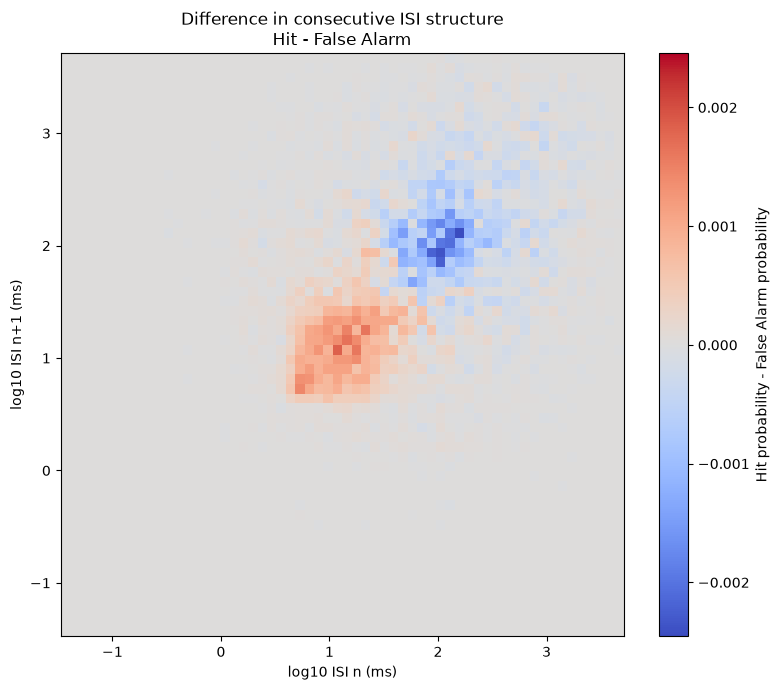

In [49]:
difference = H_hit - H_fa

limit = np.max(np.abs(difference))

plt.figure(figsize=(8, 7))

plt.imshow(
    difference.T,
    origin="lower",
    aspect="auto",
    extent=[xmin, xmax, ymin, ymax],
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit
)

plt.colorbar(label="Hit probability - False Alarm probability")

plt.xlabel("log10 ISI n (ms)")
plt.ylabel("log10 ISI n+1 (ms)")
plt.title("Difference in consecutive ISI structure\nHit - False Alarm")

plt.tight_layout()
plt.show()

In [69]:
print("Acquisition:")
print(list(nwbfile.acquisition.keys()))

print("\nProcessing modules:")
print(list(nwbfile.processing.keys()))

Acquisition:
['frametimes_eye_camera', 'frametimes_front_camera', 'frametimes_side_camera', 'manipulator_positions']

Processing modules:
['behavior', 'ecephys']


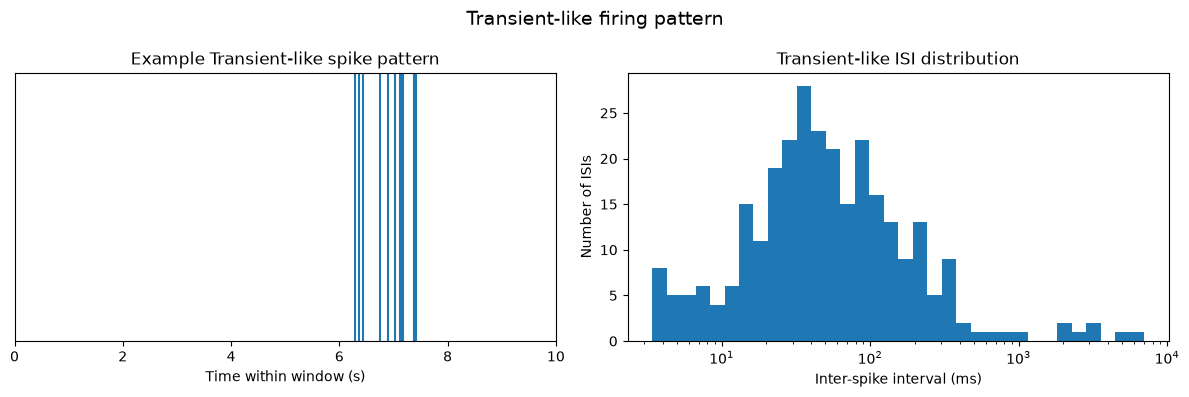

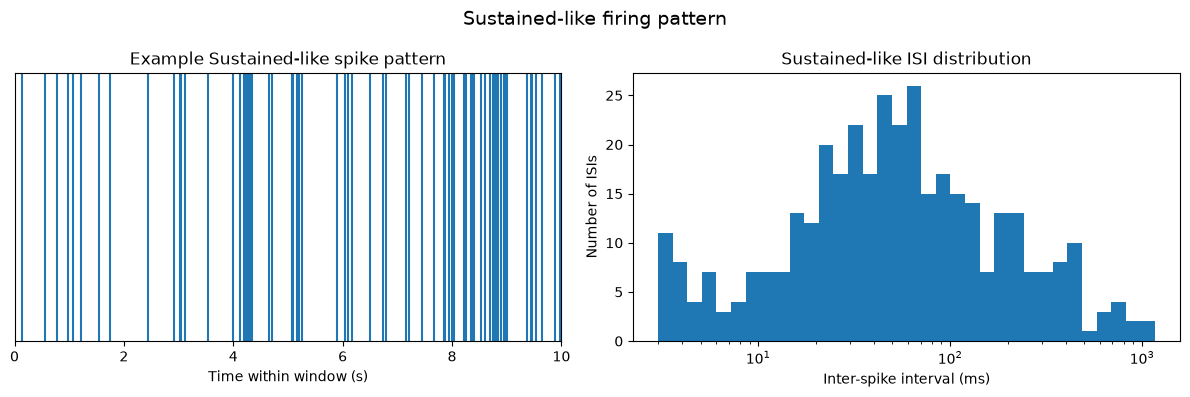

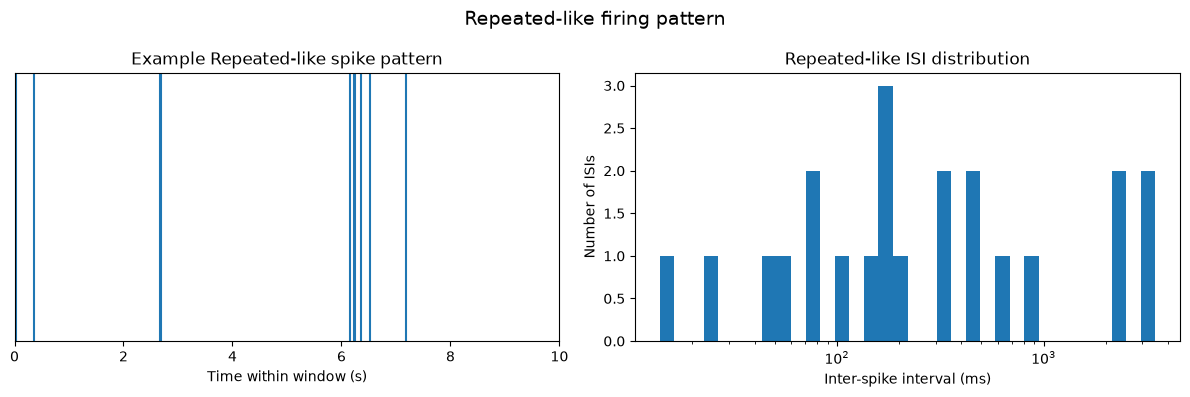

In [68]:
import matplotlib.pyplot as plt
import numpy as np

pattern_names = [
    "Transient-like",
    "Sustained-like",
    "Repeated-like"
]

for pattern_name in pattern_names:

    group = segments[
        segments["pattern"] == pattern_name
    ]

    if len(group) == 0:
        print(f"No windows found for {pattern_name}")
        continue

    # Choose one representative example:
    # use the segment with median spike count
    median_spikes = group["n_spikes"].median()

    example_idx = (
        (group["n_spikes"] - median_spikes)
        .abs()
        .idxmin()
    )

    example = group.loc[example_idx]

    # Pool ISIs from all windows belonging to this pattern
    all_isi = np.concatenate(
        group["isi"].values
    )

    # --------------------------
    # FIGURE
    # --------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 4)
    )

    # LEFT: spike pattern
    axes[0].vlines(
        example["spikes"],
        0,
        1,
        linewidth=1.5
    )

    axes[0].set_xlim(0, window_size)
    axes[0].set_ylim(0, 1)

    axes[0].set_yticks([])

    axes[0].set_xlabel(
        "Time within window (s)"
    )

    axes[0].set_title(
        f"Example {pattern_name} spike pattern"
    )

    # RIGHT: ISI histogram
    bins = np.logspace(
        np.log10(all_isi.min()),
        np.log10(all_isi.max()),
        35
    )

    axes[1].hist(
        all_isi,
        bins=bins
    )

    axes[1].set_xscale("log")

    axes[1].set_xlabel(
        "Inter-spike interval (ms)"
    )

    axes[1].set_ylabel(
        "Number of ISIs"
    )

    axes[1].set_title(
        f"{pattern_name} ISI distribution"
    )

    fig.suptitle(
        f"{pattern_name} firing pattern",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

In [67]:
segments["pattern"].value_counts()

pattern
Transient-like    22
Other              6
Sustained-like     5
Repeated-like      2
Name: count, dtype: int64

In [59]:
# Choose one QC-passing MOs neuron
unit = motor_units.iloc[0]

spikes = unit["spike_times"]

# Function to calculate ISI + its actual recording time
def epoch_isi(spikes, start, stop):
    
    s = spikes[
        (spikes >= start) &
        (spikes < stop)
    ]
    
    isi = np.diff(s) * 1000       # ms
    
    # actual time of first spike of each ISI
    isi_time = s[:-1] / 60        # recording time in minutes
    
    return isi_time, isi


# PRE
pre_t, pre_isi = epoch_isi(
    spikes,
    pre_start,
    pre_stop
)

# TASK
task_t, task_isi = epoch_isi(
    spikes,
    task_start,
    task_stop
)

# POST
post_t, post_isi = epoch_isi(
    spikes,
    post_start,
    post_stop
)

In [66]:
segments.groupby("pattern")[
    ["n_spikes", "coverage", "concentration", "bouts"]
].mean()

,n_spikes,coverage,concentration,bouts
pattern,,,,
Other,51.666667,0.391667,0.614173,1.333333
Repeated-like,12.000000,0.350000,0.585714,3.000000
Sustained-like,75.000000,0.770000,0.408966,2.400000
Transient-like,14.181818,0.170455,0.942985,1.409091


In [65]:
def classify_pattern(row):

    # TRANSIENT-LIKE:
    # Most spikes concentrated within a short part of the window
    if row["concentration"] >= 0.70:
        return "Transient-like"

    # SUSTAINED-LIKE:
    # Activity distributed through much of the window
    elif row["coverage"] >= 0.60:
        return "Sustained-like"

    # REPEATED-LIKE:
    # Several separated activity bouts
    elif row["bouts"] >= 3:
        return "Repeated-like"

    else:
        return "Other"


segments["pattern"] = segments.apply(
    classify_pattern,
    axis=1
)

print(segments["pattern"].value_counts())

pattern
Transient-like    22
Other              6
Sustained-like     5
Repeated-like      2
Name: count, dtype: int64


In [64]:
import numpy as np
import pandas as pd

# Same QC-passing MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

window_size = 10.0  # seconds
bin_size = 0.5      # for detecting activity bouts

segments = []

for start in np.arange(task_start, task_stop - window_size, window_size):

    end = start + window_size

    s = spikes[
        (spikes >= start) &
        (spikes < end)
    ]

    # Ignore windows with too few spikes
    if len(s) < 5:
        continue

    relative_spikes = s - start
    isi = np.diff(s) * 1000  # ms

    # Divide window into 0.5-s bins
    bins = np.arange(0, window_size + bin_size, bin_size)
    counts, _ = np.histogram(relative_spikes, bins=bins)

    active = counts > 0

    # -------------------------
    # FEATURE 1: coverage
    # -------------------------
    coverage = active.mean()

    # -------------------------
    # FEATURE 2: concentration
    # -------------------------
    # Fraction of spikes contained in the busiest 2-second period
    max_spikes_2s = 0

    for t in np.arange(0, window_size - 2 + 0.1, 0.1):
        n = np.sum(
            (relative_spikes >= t) &
            (relative_spikes < t + 2)
        )

        max_spikes_2s = max(max_spikes_2s, n)

    concentration = max_spikes_2s / len(relative_spikes)

    # -------------------------
    # FEATURE 3: number of bouts
    # -------------------------
    # Count transitions from inactive -> active
    bouts = np.sum(
        (active[1:] == True) &
        (active[:-1] == False)
    )

    # Include activity starting in first bin
    if active[0]:
        bouts += 1

    segments.append({
        "start": start,
        "spikes": relative_spikes,
        "isi": isi,
        "n_spikes": len(relative_spikes),
        "coverage": coverage,
        "concentration": concentration,
        "bouts": bouts
    })

segments = pd.DataFrame(segments)

print("Number of active windows:", len(segments))

segments[
    ["n_spikes", "coverage", "concentration", "bouts"]
].describe()

Number of active windows: 35


,n_spikes,coverage,concentration,bouts
count,35.000000,35.000000,35.000000,35.000000
mean,29.171429,0.304286,0.789913,1.628571
std,30.992870,0.237131,0.219410,0.770245
min,5.000000,0.050000,0.385714,1.000000
25%,9.000000,0.150000,0.600000,1.000000
50%,14.000000,0.200000,0.875000,1.000000
75%,36.000000,0.450000,1.000000,2.000000
max,118.000000,1.000000,1.000000,4.000000


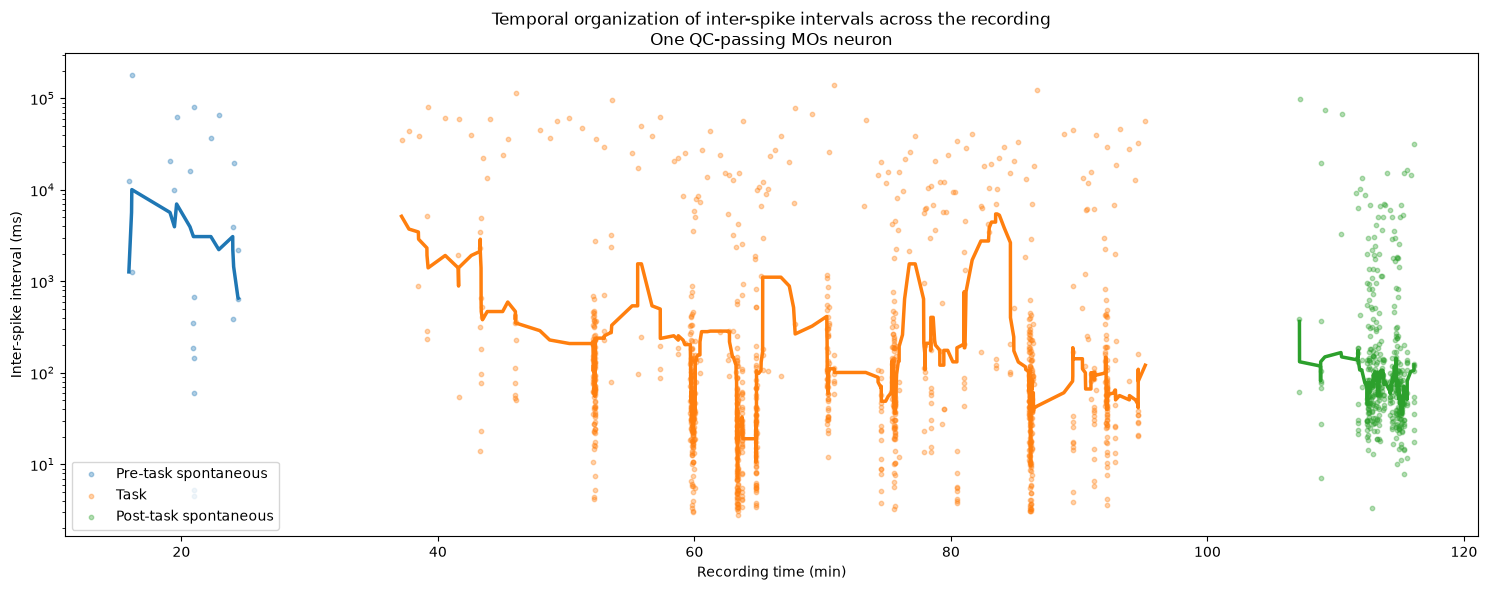

In [63]:
import pandas as pd
import matplotlib.pyplot as plt


def plot_epoch_isi(ax, times, isi, label):

    # Individual ISIs
    ax.scatter(
        times,
        isi,
        s=10,
        alpha=0.35,
        label=label
    )

    # Sort by time
    df = pd.DataFrame({
        "time": times,
        "isi": isi
    }).sort_values("time")

    # Rolling median over 30 consecutive ISIs
    rolling = df["isi"].rolling(
        window=30,
        center=True,
        min_periods=10
    ).median()

    # Plot temporal trend
    ax.plot(
        df["time"],
        rolling,
        linewidth=2.5
    )


fig, ax = plt.subplots(figsize=(15, 6))

plot_epoch_isi(
    ax,
    pre_t,
    pre_isi,
    "Pre-task spontaneous"
)

plot_epoch_isi(
    ax,
    task_t,
    task_isi,
    "Task"
)

plot_epoch_isi(
    ax,
    post_t,
    post_isi,
    "Post-task spontaneous"
)

ax.set_yscale("log")

ax.set_xlabel("Recording time (min)")
ax.set_ylabel("Inter-spike interval (ms)")

ax.set_title(
    "Temporal organization of inter-spike intervals across the recording\n"
    "One QC-passing MOs neuron"
)

ax.legend()

plt.tight_layout()
plt.show()

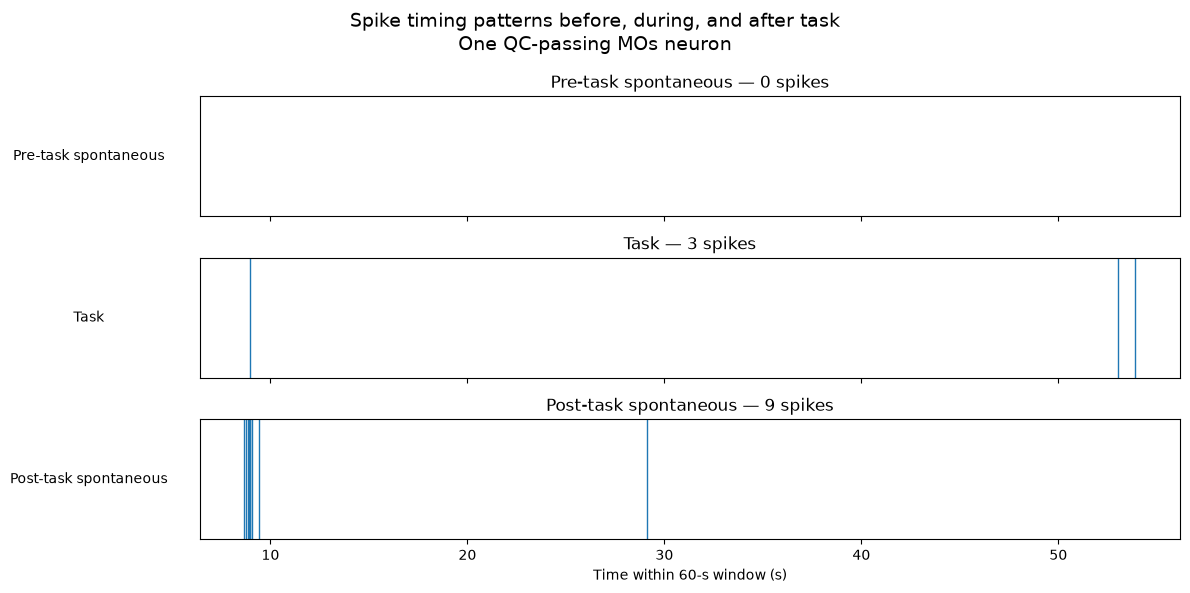

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# Same QC-passing MOs neuron
unit = motor_units.iloc[0]
spikes = unit["spike_times"]

# Choose 60-second example windows
window_length = 60  # seconds

# You can change these start times later
pre_example_start = pre_start + 100
task_example_start = task_start + 100
post_example_start = post_start + 100

example_windows = [
    ("Pre-task spontaneous", pre_example_start),
    ("Task", task_example_start),
    ("Post-task spontaneous", post_example_start)
]

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

for ax, (label, start) in zip(axes, example_windows):

    end = start + window_length

    # Select spikes in this 60-s period
    example_spikes = spikes[
        (spikes >= start) &
        (spikes < end)
    ]

    # Convert to time relative to the start of the window
    relative_spikes = example_spikes - start

    # Plot every spike as a vertical line
    ax.vlines(
        relative_spikes,
        ymin=0,
        ymax=1,
        linewidth=1
    )

    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_ylabel(label, rotation=0, labelpad=80, va="center")

    ax.set_title(
        f"{label} — {len(example_spikes)} spikes"
    )

axes[-1].set_xlabel("Time within 60-s window (s)")

fig.suptitle(
    "Spike timing patterns before, during, and after task\n"
    "One QC-passing MOs neuron",
    fontsize=14
)

plt.tight_layout()
plt.show()

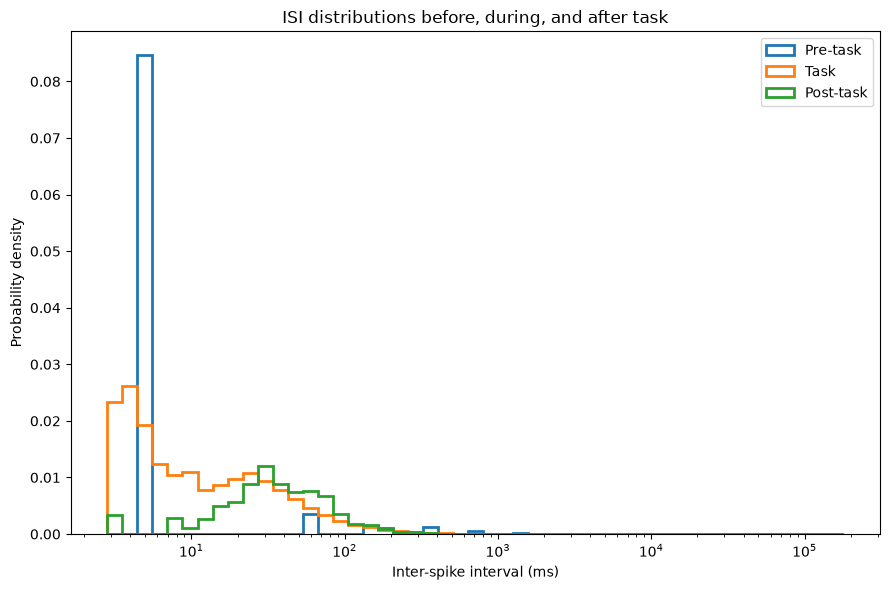

In [61]:
bins = np.logspace(
    np.log10(
        min(pre_isi.min(), task_isi.min(), post_isi.min())
    ),
    np.log10(
        max(pre_isi.max(), task_isi.max(), post_isi.max())
    ),
    50
)

plt.figure(figsize=(9, 6))

plt.hist(
    pre_isi,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Pre-task"
)

plt.hist(
    task_isi,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Task"
)

plt.hist(
    post_isi,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=2,
    label="Post-task"
)

plt.xscale("log")

plt.xlabel("Inter-spike interval (ms)")
plt.ylabel("Probability density")

plt.title(
    "ISI distributions before, during, and after task"
)

plt.legend()

plt.tight_layout()
plt.show()

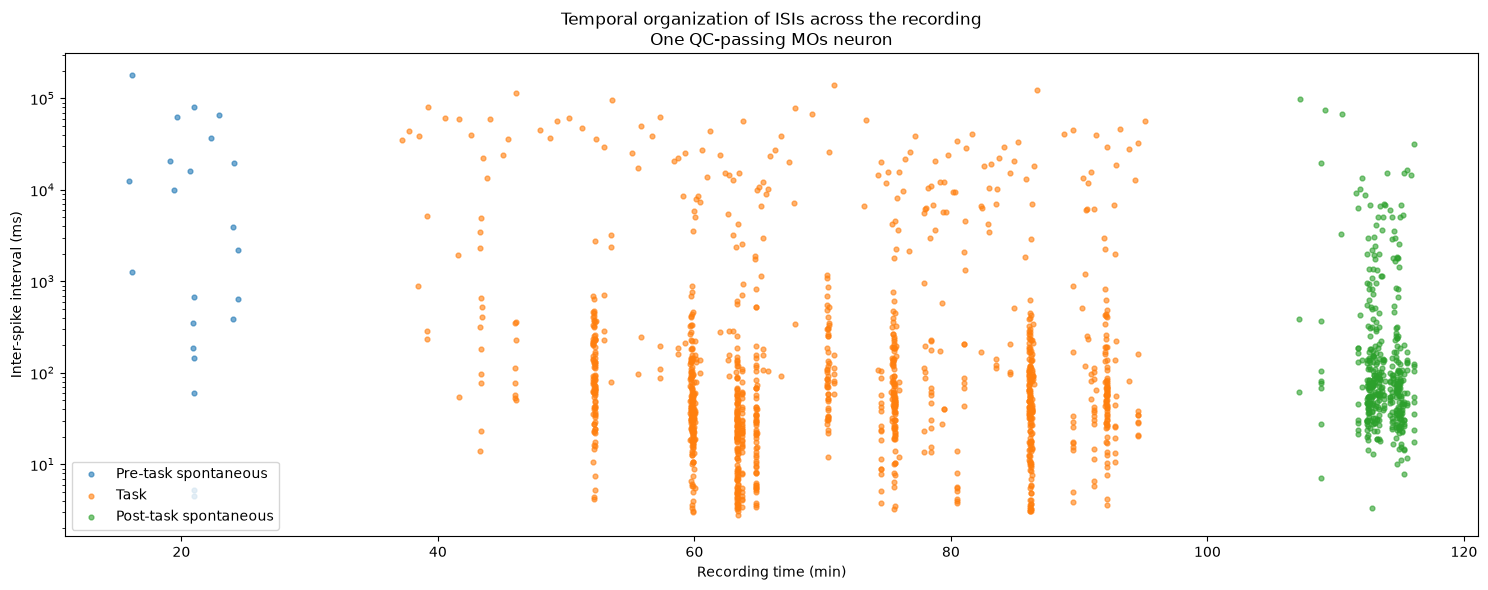

In [60]:
plt.figure(figsize=(15, 6))

plt.scatter(
    pre_t,
    pre_isi,
    s=12,
    alpha=0.6,
    label="Pre-task spontaneous"
)

plt.scatter(
    task_t,
    task_isi,
    s=12,
    alpha=0.6,
    label="Task"
)

plt.scatter(
    post_t,
    post_isi,
    s=12,
    alpha=0.6,
    label="Post-task spontaneous"
)

plt.yscale("log")

plt.xlabel("Recording time (min)")
plt.ylabel("Inter-spike interval (ms)")

plt.title(
    "Temporal organization of ISIs across the recording\n"
    "One QC-passing MOs neuron"
)

plt.legend()

plt.tight_layout()
plt.show()

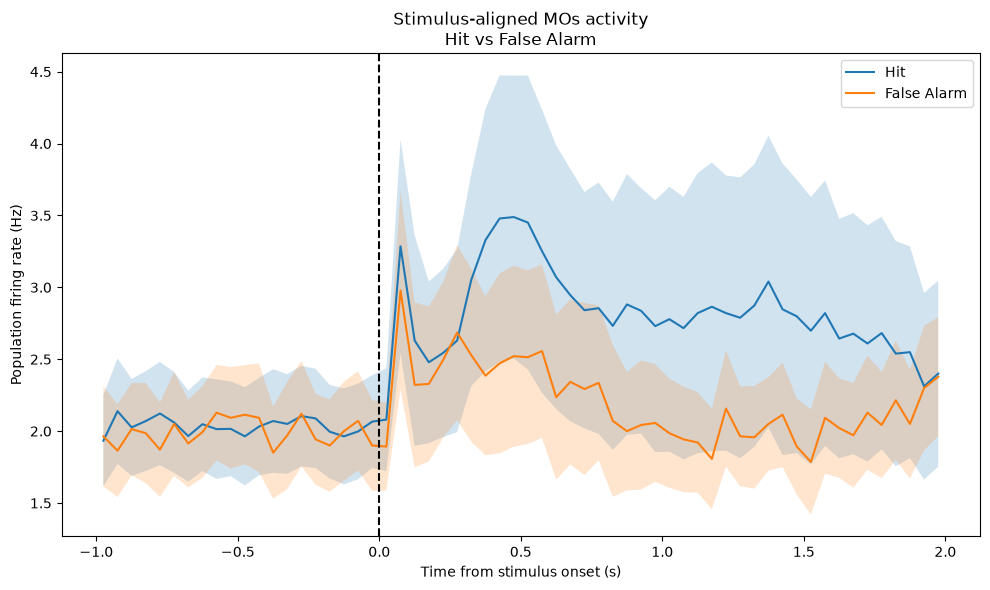

In [58]:
hit_mean = np.mean(hit_psths, axis=0)
fa_mean = np.mean(fa_psths, axis=0)

hit_sem = np.std(hit_psths, axis=0) / np.sqrt(len(hit_psths))
fa_sem = np.std(fa_psths, axis=0) / np.sqrt(len(fa_psths))

plt.figure(figsize=(10, 6))

plt.plot(
    bin_centers,
    hit_mean,
    label="Hit"
)

plt.fill_between(
    bin_centers,
    hit_mean - hit_sem,
    hit_mean + hit_sem,
    alpha=0.2
)

plt.plot(
    bin_centers,
    fa_mean,
    label="False Alarm"
)

plt.fill_between(
    bin_centers,
    fa_mean - fa_sem,
    fa_mean + fa_sem,
    alpha=0.2
)

plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Population firing rate (Hz)")
plt.title("Stimulus-aligned MOs activity\nHit vs False Alarm")

plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# Analysis window around stimulus
pre_time = 1.0
post_time = 2.0
bin_size = 0.05   # 50 ms bins

bins = np.arange(-pre_time, post_time + bin_size, bin_size)
bin_centers = (bins[:-1] + bins[1:]) / 2

hit_psths = []
fa_psths = []

for _, unit in motor_units.iterrows():

    spikes = unit["spike_times"]

    hit_trials_unit = []
    fa_trials_unit = []

    for _, trial in trials.iterrows():

        stim_time = trial["stim_start_time"]

        # spikes relative to stimulus
        relative_spikes = spikes[
            (spikes >= stim_time - pre_time) &
            (spikes < stim_time + post_time)
        ] - stim_time

        counts, _ = np.histogram(relative_spikes, bins=bins)

        firing_rate = counts / bin_size

        if trial["is_hit"]:
            hit_trials_unit.append(firing_rate)

        elif trial["is_false_alarm"]:
            fa_trials_unit.append(firing_rate)

    # Average trials WITHIN each neuron
    if len(hit_trials_unit) > 0:
        hit_psths.append(np.mean(hit_trials_unit, axis=0))

    if len(fa_trials_unit) > 0:
        fa_psths.append(np.mean(fa_trials_unit, axis=0))

hit_psths = np.array(hit_psths)
fa_psths = np.array(fa_psths)

print("Hit neurons:", hit_psths.shape)
print("False Alarm neurons:", fa_psths.shape)

Hit neurons: (70, 60)
False Alarm neurons: (70, 60)


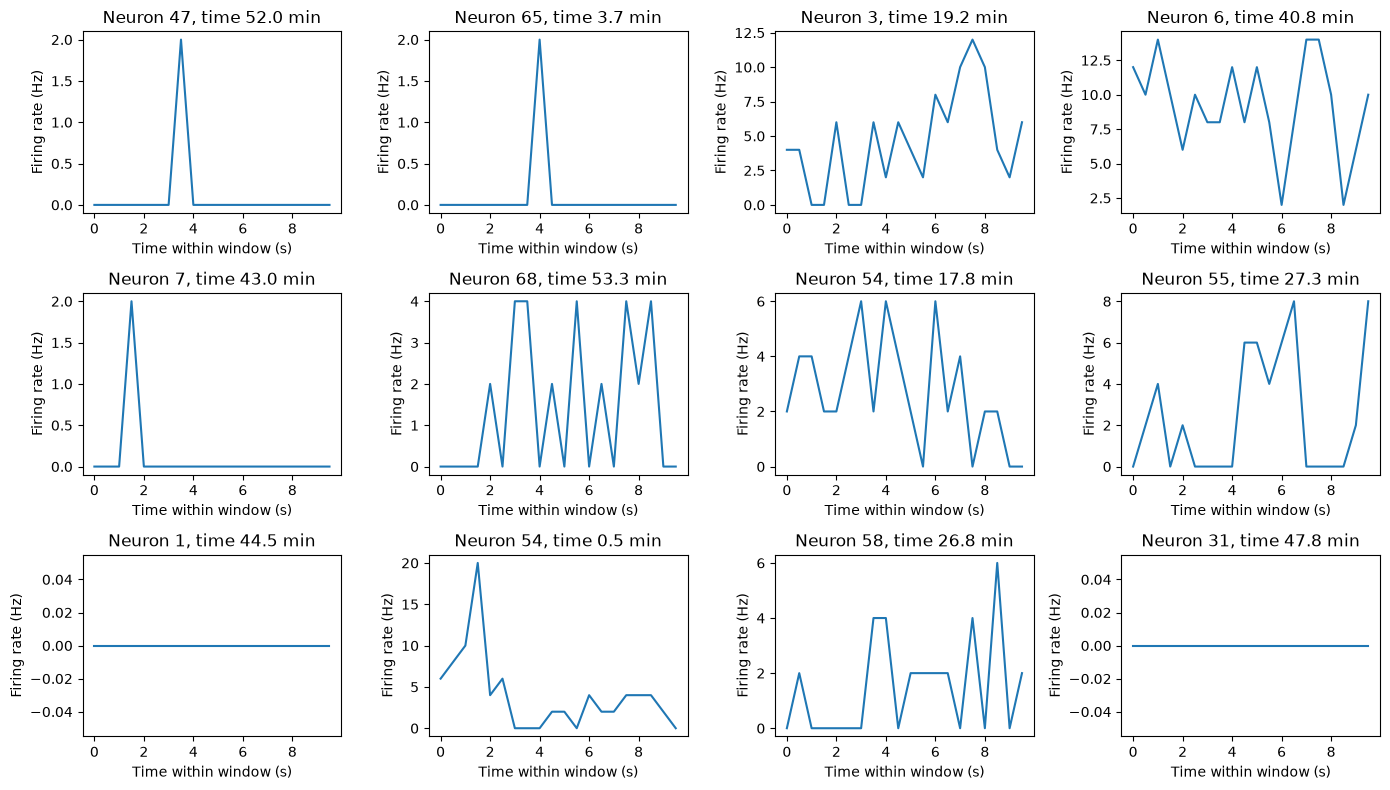

In [56]:
np.random.seed(10)

example_indices = np.random.choice(
    len(patterns),
    size=12,
    replace=False
)

fig, axes = plt.subplots(3, 4, figsize=(14, 8))

time_axis = np.arange(0, window_size, small_bin)

for ax, idx in zip(axes.flat, example_indices):

    ax.plot(time_axis, patterns[idx])

    ax.set_title(
        f"Neuron {pattern_neurons[idx]}, "
        f"time {pattern_times[idx]/60:.1f} min"
    )

    ax.set_xlabel("Time within window (s)")
    ax.set_ylabel("Firing rate (Hz)")

plt.tight_layout()
plt.show()

In [55]:
from scipy.stats import zscore

window_size = 10.0   # seconds
small_bin = 0.5      # seconds

patterns = []
pattern_neurons = []
pattern_times = []

for neuron_index, (_, unit) in enumerate(motor_units.iterrows()):

    spikes = unit["spike_times"]

    # Move task spikes so task begins at time 0
    task_spikes = spikes[
        (spikes >= task_start) &
        (spikes < task_stop)
    ] - task_start

    task_duration = task_stop - task_start

    # Divide task into 10-second windows
    for start in np.arange(0, task_duration - window_size, window_size):

        end = start + window_size

        window_spikes = task_spikes[
            (task_spikes >= start) &
            (task_spikes < end)
        ]

        # 0.5-s bins within this 10-s window
        bins = np.arange(start, end + small_bin, small_bin)

        counts, _ = np.histogram(window_spikes, bins=bins)

        firing_rate = counts / small_bin

        patterns.append(firing_rate)
        pattern_neurons.append(neuron_index)
        pattern_times.append(start)

patterns = np.array(patterns)

print("Pattern matrix shape:", patterns.shape)

Pattern matrix shape: (25480, 20)


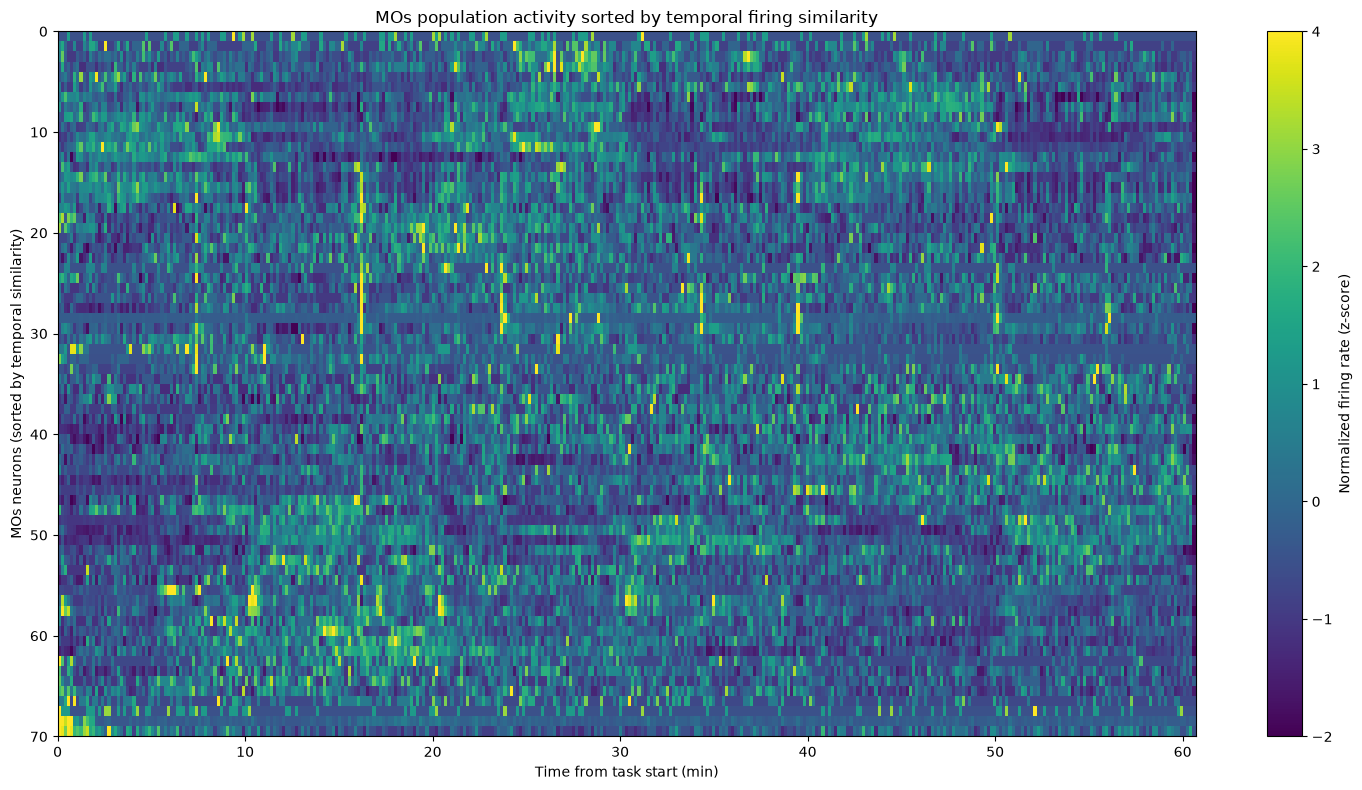

In [54]:
plt.figure(figsize=(15, 8))

plt.imshow(
    z_sorted,
    aspect="auto",
    interpolation="nearest",
    extent=[
        0,
        (task_stop - task_start) / 60,
        len(motor_units),
        0
    ],
    cmap="viridis",
    vmin=-2,
    vmax=4
)

plt.colorbar(label="Normalized firing rate (z-score)")

plt.xlabel("Time from task start (min)")
plt.ylabel("MOs neurons (sorted by temporal similarity)")

plt.title(
    "MOs population activity sorted by temporal firing similarity"
)

plt.tight_layout()
plt.show()

In [53]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Compare neurons based on their temporal firing profiles
distance = pdist(z_activity, metric="correlation")

# Hierarchical clustering
Z = linkage(distance, method="average")

# Get new neuron order
order = leaves_list(Z)

# Reorder heatmap
z_sorted = z_activity[order]

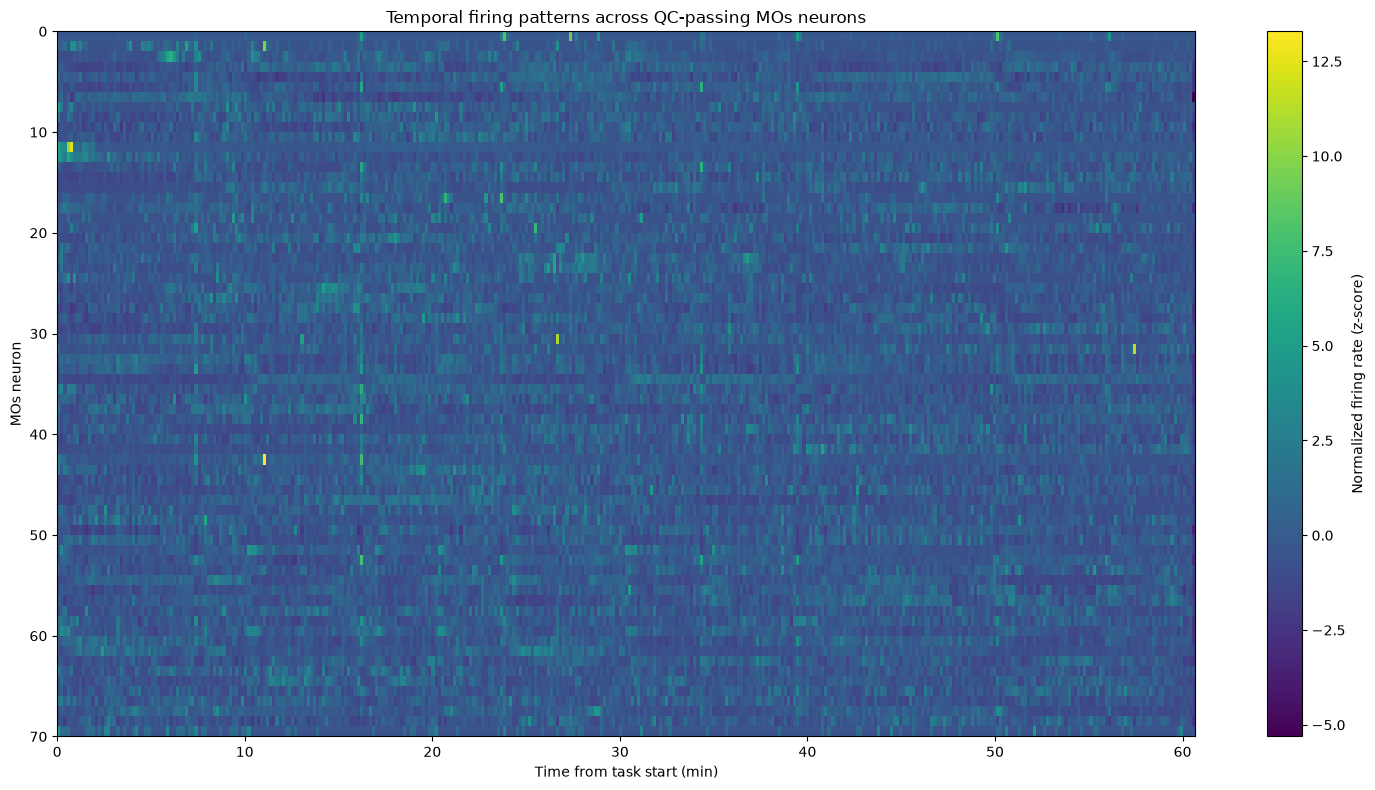

In [52]:
plt.figure(figsize=(15, 8))

plt.imshow(
    z_activity,
    aspect="auto",
    interpolation="nearest",
    extent=[
        0,
        (task_stop - task_start) / 60,
        len(motor_units),
        0
    ],
    cmap="viridis"
)

plt.colorbar(label="Normalized firing rate (z-score)")

plt.xlabel("Time from task start (min)")
plt.ylabel("MOs neuron")

plt.title(
    "Temporal firing patterns across QC-passing MOs neurons"
)

plt.tight_layout()
plt.show()

In [51]:
mean_fr = population_activity.mean(axis=1, keepdims=True)
std_fr = population_activity.std(axis=1, keepdims=True)

z_activity = (population_activity - mean_fr) / (std_fr + 1e-10)

In [50]:
import numpy as np
import matplotlib.pyplot as plt

window = 10  # seconds

bins = np.arange(task_start, task_stop + window, window)

population_activity = []

for _, unit in motor_units.iterrows():

    spikes = unit["spike_times"]

    task_spikes = spikes[
        (spikes >= task_start) &
        (spikes < task_stop)
    ]

    counts, _ = np.histogram(task_spikes, bins=bins)

    firing_rate = counts / window

    population_activity.append(firing_rate)

population_activity = np.array(population_activity)

print(population_activity.shape)

(70, 365)


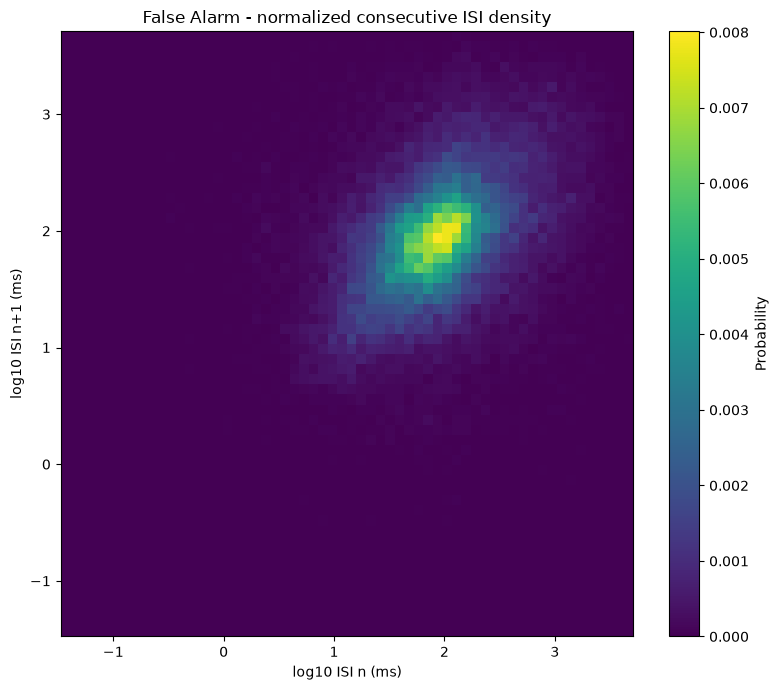

In [48]:
plt.figure(figsize=(8, 7))

plt.imshow(
    H_fa.T,
    origin="lower",
    aspect="auto",
    extent=[xmin, xmax, ymin, ymax]
)

plt.colorbar(label="Probability")

plt.xlabel("log10 ISI n (ms)")
plt.ylabel("log10 ISI n+1 (ms)")
plt.title("False Alarm - normalized consecutive ISI density")

plt.tight_layout()
plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
hit_x = np.array(hit_x_all)
hit_y = np.array(hit_y_all)

fa_x = np.array(fa_x_all)
fa_y = np.array(fa_y_all)

# Work in log10(ISI) space
hit_logx = np.log10(hit_x)
hit_logy = np.log10(hit_y)

fa_logx = np.log10(fa_x)
fa_logy = np.log10(fa_y)

# Use identical bins for Hit and False Alarm
xmin = min(hit_logx.min(), fa_logx.min())
xmax = max(hit_logx.max(), fa_logx.max())

ymin = min(hit_logy.min(), fa_logy.min())
ymax = max(hit_logy.max(), fa_logy.max())

bins = 60

H_hit, xedges, yedges = np.histogram2d(
    hit_logx, hit_logy,
    bins=bins,
    range=[[xmin, xmax], [ymin, ymax]]
)

H_fa, _, _ = np.histogram2d(
    fa_logx, fa_logy,
    bins=bins,
    range=[[xmin, xmax], [ymin, ymax]]
)

# Normalize each outcome separately
H_hit = H_hit / H_hit.sum()
H_fa = H_fa / H_fa.sum()

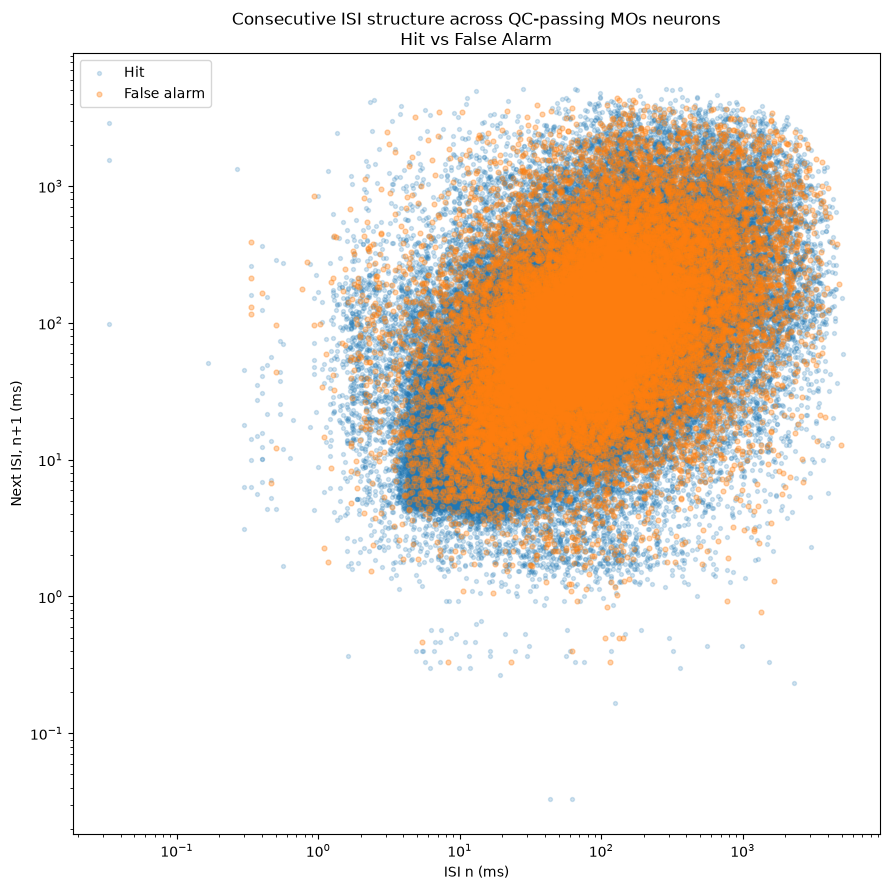

In [46]:
plt.figure(figsize=(9, 9))

plt.scatter(
    hit_x_all,
    hit_y_all,
    s=8,
    alpha=0.20,
    label="Hit"
)

plt.scatter(
    fa_x_all,
    fa_y_all,
    s=12,
    alpha=0.35,
    label="False alarm"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("ISI n (ms)")
plt.ylabel("Next ISI, n+1 (ms)")

plt.title(
    "Consecutive ISI structure across QC-passing MOs neurons\n"
    "Hit vs False Alarm"
)

plt.legend()

plt.tight_layout()
plt.show()

In [45]:
# Store ISI pairs from ALL QC-passing MOs neurons
hit_x_all = []
hit_y_all = []

fa_x_all = []
fa_y_all = []

# Loop through all QC-passing MOs neurons
for _, unit in motor_units.iterrows():

    spikes = unit["spike_times"]

    # Loop through trials
    for _, trial in trials.iterrows():

        # Spikes from THIS neuron during THIS trial
        trial_spikes = spikes[
            (spikes >= trial["start_time"]) &
            (spikes < trial["stop_time"])
        ]

        # Need at least 3 spikes to create
        # ISI_n and ISI_n+1
        if len(trial_spikes) < 3:
            continue

        # Calculate ISIs within this trial only
        trial_isi = np.diff(trial_spikes) * 1000  # ms

        x = trial_isi[:-1]
        y = trial_isi[1:]

        # HIT
        if trial["is_hit"]:
            hit_x_all.extend(x)
            hit_y_all.extend(y)

        # FALSE ALARM
        elif trial["is_false_alarm"]:
            fa_x_all.extend(x)
            fa_y_all.extend(y)


print("Number of MOs neurons:", len(motor_units))
print("Hit ISI pairs:", len(hit_x_all))
print("False Alarm ISI pairs:", len(fa_x_all))

Number of MOs neurons: 70
Hit ISI pairs: 121835
False Alarm ISI pairs: 29829


In [43]:
# Store ISI pairs from ALL QC-passing MOs neurons
hit_x_all = []
hit_y_all = []

fa_x_all = []
fa_y_all = []

# Loop through all QC-passing MOs neurons
for _, unit in motor_units.iterrows():

    spikes = unit["spike_times"]

    # Loop through trials
    for _, trial in trials.iterrows():

        # Spikes from THIS neuron during THIS trial
        trial_spikes = spikes[
            (spikes >= trial["start_time"]) &
            (spikes < trial["stop_time"])
        ]

        # Need at least 3 spikes to create
        # ISI_n and ISI_n+1
        if len(trial_spikes) < 3:
            continue

        # Calculate ISIs within this trial only
        trial_isi = np.diff(trial_spikes) * 1000  # ms

        x = trial_isi[:-1]
        y = trial_isi[1:]

        # HIT
        if trial["is_hit"]:
            hit_x_all.extend(x)
            hit_y_all.extend(y)

        # FALSE ALARM
        elif trial["is_false_alarm"]:
            fa_x_all.extend(x)
            fa_y_all.extend(y)


print("Number of MOs neurons:", len(motor_units))
print("Hit ISI pairs:", len(hit_x_all))
print("False Alarm ISI pairs:", len(fa_x_all))

Number of MOs neurons: 70
Hit ISI pairs: 121835
False Alarm ISI pairs: 29829


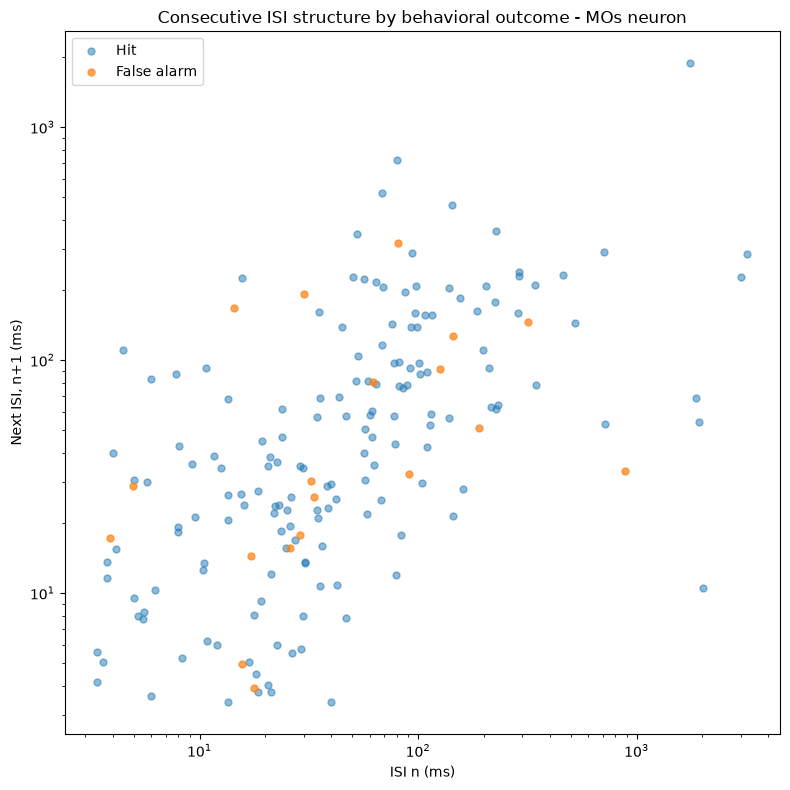

In [42]:
plt.figure(figsize=(8, 8))

plt.scatter(
    hit_x,
    hit_y,
    s=25,
    alpha=0.5,
    label="Hit"
)

plt.scatter(
    fa_x,
    fa_y,
    s=25,
    alpha=0.7,
    label="False alarm"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("ISI n (ms)")
plt.ylabel("Next ISI, n+1 (ms)")
plt.title("Consecutive ISI structure by behavioral outcome - MOs neuron")

plt.legend()

plt.tight_layout()
plt.show()

In [41]:
print("Hit ISI pairs:", len(hit_x))
print("False alarm ISI pairs:", len(fa_x))

Hit ISI pairs: 164
False alarm ISI pairs: 19


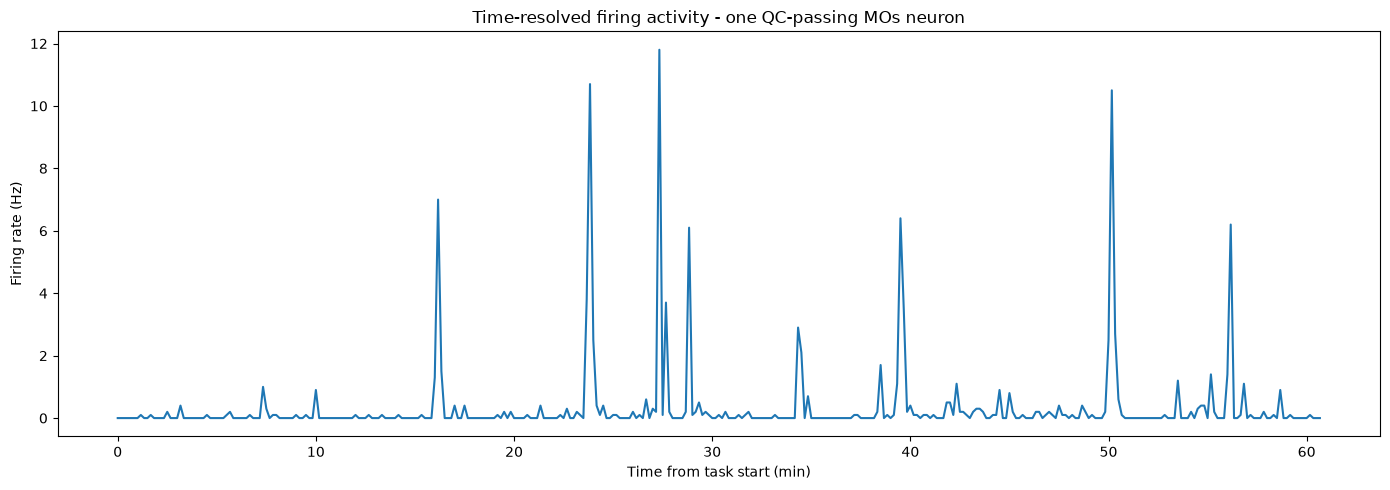

In [39]:
window = 10  # seconds

bins = np.arange(task_start, task_stop + window, window)

spike_counts, edges = np.histogram(spikes_task, bins=bins)
firing_rate = spike_counts / window

time_minutes = (edges[:-1] - task_start) / 60

plt.figure(figsize=(14, 5))

plt.plot(time_minutes, firing_rate, linewidth=1.5)

plt.xlabel("Time from task start (min)")
plt.ylabel("Firing rate (Hz)")
plt.title("Time-resolved firing activity - one QC-passing MOs neuron")

plt.tight_layout()
plt.show()

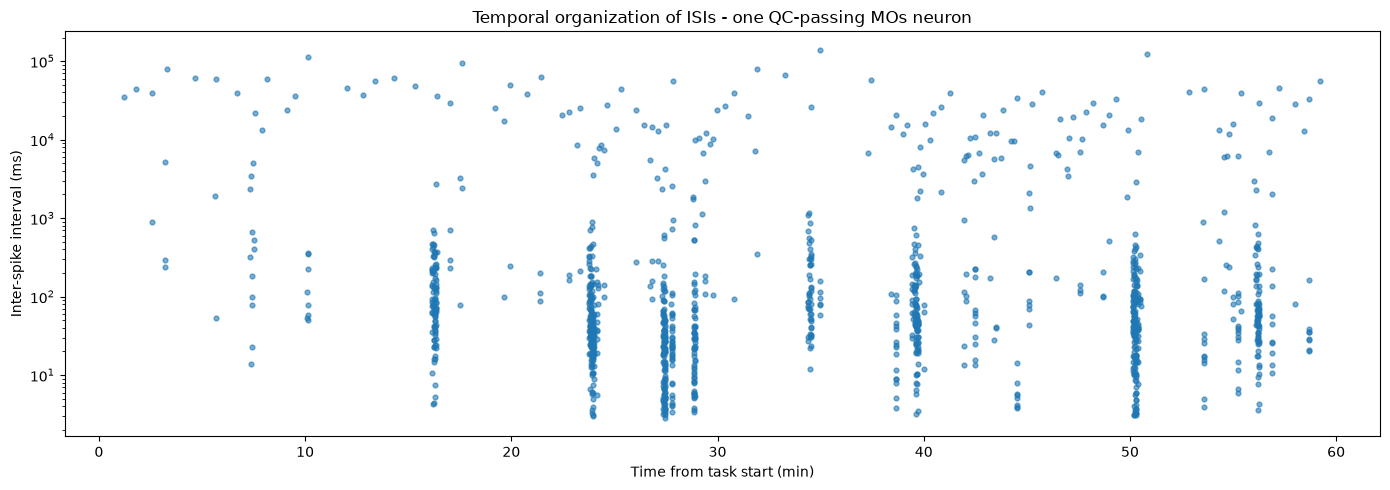

In [38]:
# Same QC-passing MOs neuron
spikes = motor_units.iloc[0]["spike_times"]

# Keep only task spikes
spikes_task = spikes[
    (spikes >= task_start) &
    (spikes < task_stop)
]

# ISI in milliseconds
isi = np.diff(spikes_task) * 1000

# Time at which each ISI starts
isi_time = (spikes_task[:-1] - task_start) / 60   # minutes from task start

plt.figure(figsize=(14, 5))

plt.scatter(
    isi_time,
    isi,
    s=12,
    alpha=0.6
)

plt.yscale("log")

plt.xlabel("Time from task start (min)")
plt.ylabel("Inter-spike interval (ms)")
plt.title("Temporal organization of ISIs - one QC-passing MOs neuron")

plt.tight_layout()
plt.show()

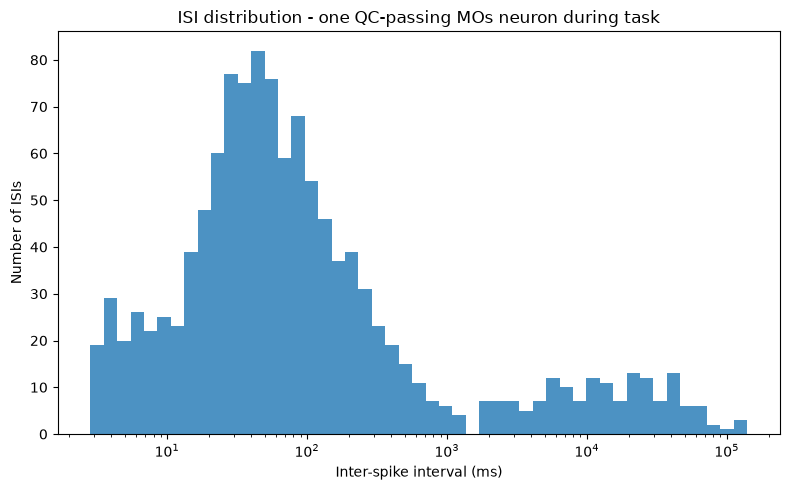

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    isi,
    bins=np.logspace(np.log10(isi.min()),
                     np.log10(isi.max()),
                     50),
    alpha=0.8
)

plt.xscale("log")

plt.xlabel("Inter-spike interval (ms)")
plt.ylabel("Number of ISIs")
plt.title("ISI distribution - one QC-passing MOs neuron during task")

plt.tight_layout()
plt.show()

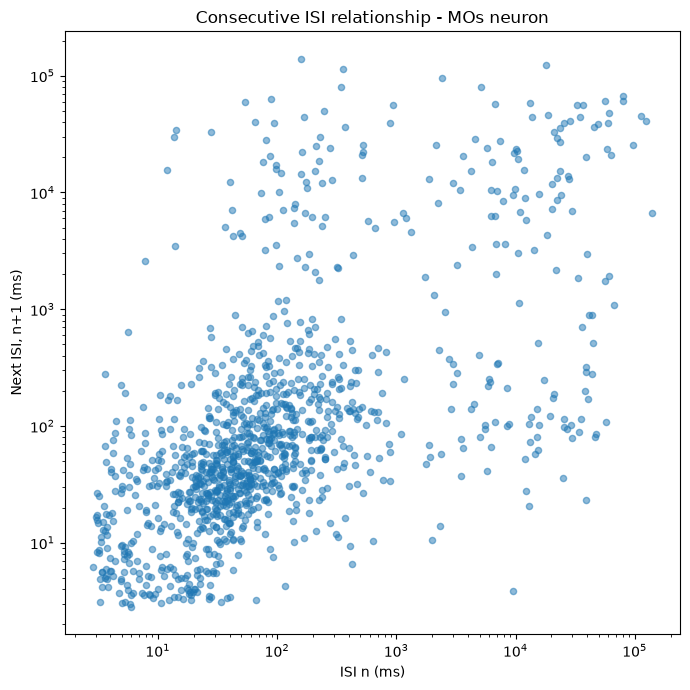

In [36]:
plt.figure(figsize=(7, 7))

plt.scatter(
    isi[:-1],
    isi[1:],
    s=20,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("ISI n (ms)")
plt.ylabel("Next ISI, n+1 (ms)")
plt.title("Consecutive ISI relationship - MOs neuron")

plt.tight_layout()
plt.show()

In [35]:
spikes = motor_units.iloc[0]["spike_times"]

# Select spikes during the task
spikes_task = spikes[
    (spikes >= task_start) &
    (spikes < task_stop)
]

# Calculate every ISI
isi = np.diff(spikes_task) * 1000   # convert seconds to ms

print("Number of spikes:", len(spikes_task))
print("Number of ISIs:", len(isi))
print(isi[:20])

Number of spikes: 1196
Number of ISIs: 1195
[3.47632741e+04 4.40793290e+04 8.89425848e+02 3.89501055e+04
 2.88964235e+02 2.37398002e+02 5.14182340e+03 8.01612587e+04
 6.05136907e+04 1.91955051e+03 5.41328778e+01 5.94553663e+04
 3.93954685e+04 3.19497311e+02 2.31964715e+03 1.38998830e+01
 3.46517084e+03 7.78660114e+01 2.31331387e+01 9.76658447e+01]


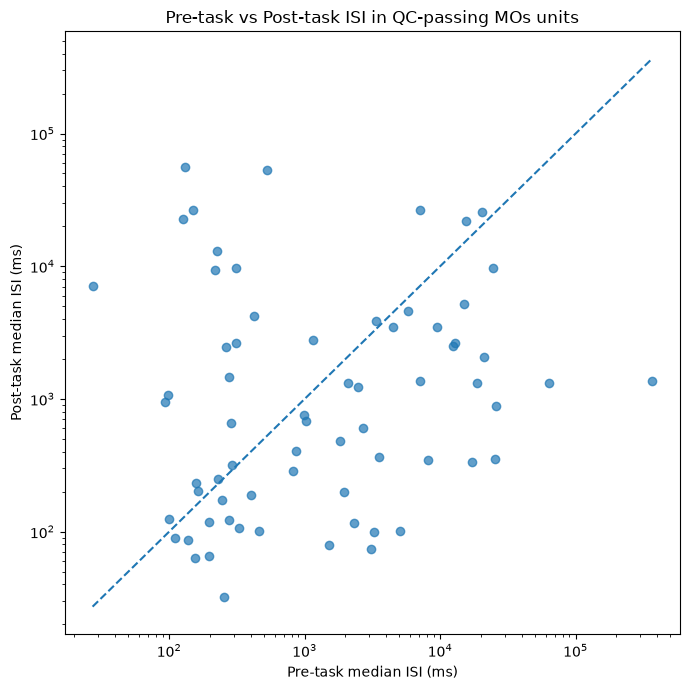

In [33]:
# Keep neurons where both pre- and post-task ISI exist
scatter_data = results.dropna(subset=["pre_isi", "post_isi"]).copy()

# Convert seconds to milliseconds
x = scatter_data["pre_isi"] * 1000
y = scatter_data["post_isi"] * 1000

plt.figure(figsize=(7, 7))

plt.scatter(x, y, alpha=0.7)

# Identity line: y = x
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Pre-task median ISI (ms)")
plt.ylabel("Post-task median ISI (ms)")
plt.title("Pre-task vs Post-task ISI in QC-passing MOs units")

plt.tight_layout()
plt.show()

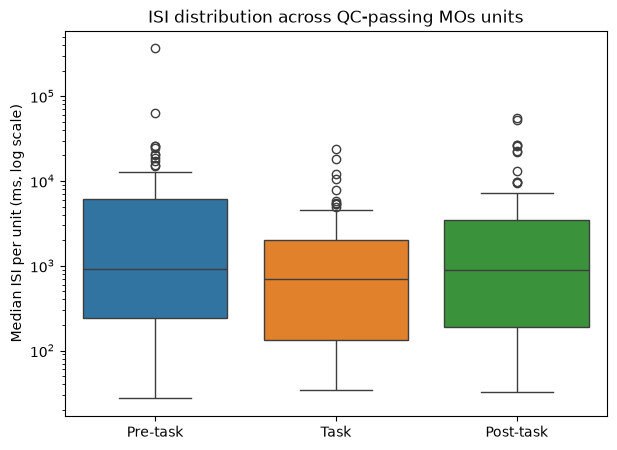

In [32]:
isi_long = pd.DataFrame({
    "Pre-task": results["pre_isi"] * 1000,
    "Task": results["task_isi"] * 1000,
    "Post-task": results["post_isi"] * 1000
})

plt.figure(figsize=(7, 5))

sns.boxplot(data=isi_long)

plt.yscale("log")
plt.ylabel("Median ISI per unit (ms, log scale)")
plt.title("ISI distribution across QC-passing MOs units")

plt.show()

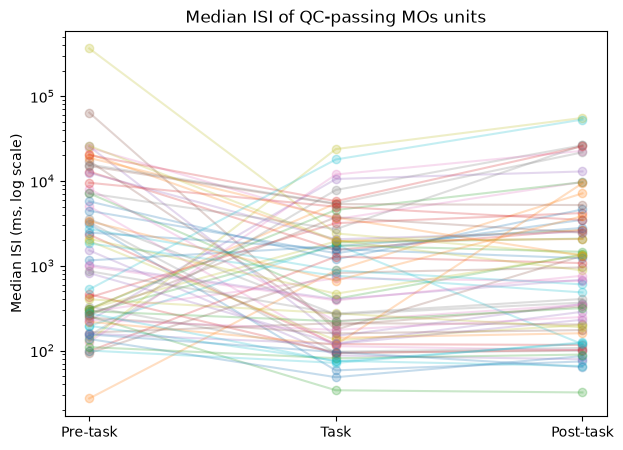

In [31]:
plt.figure(figsize=(7, 5))

for _, row in results.iterrows():
    plt.plot(
        ["Pre-task", "Task", "Post-task"],
        [
            row["pre_isi"] * 1000,
            row["task_isi"] * 1000,
            row["post_isi"] * 1000
        ],
        marker="o",
        alpha=0.25
    )

plt.yscale("log")

plt.ylabel("Median ISI (ms, log scale)")
plt.title("Median ISI of QC-passing MOs units")

plt.show()

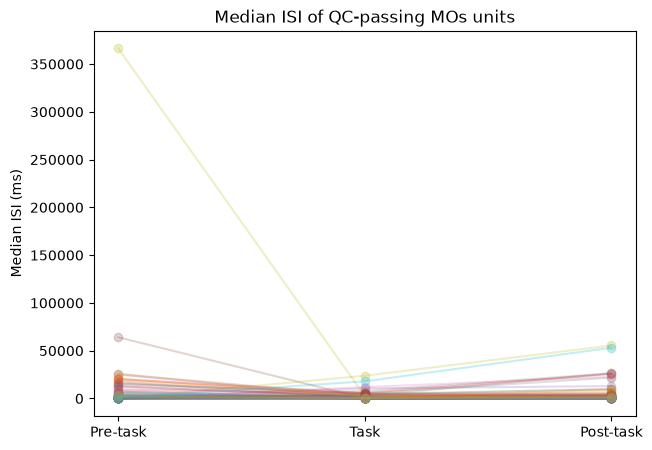

In [30]:
plt.figure(figsize=(7, 5))

for _, row in results.iterrows():
    plt.plot(
        ["Pre-task", "Task", "Post-task"],
        [
            row["pre_isi"] * 1000,
            row["task_isi"] * 1000,
            row["post_isi"] * 1000
        ],
        marker="o",
        alpha=0.25
    )

plt.ylabel("Median ISI (ms)")
plt.title("Median ISI of QC-passing MOs units")

plt.show()

In [29]:
population_results = []

for _, unit in motor_units.iterrows():

    spikes = unit["spike_times"]

    # Select spikes in each epoch
    pre = spikes[
        (spikes >= pre_start) &
        (spikes < pre_stop)
    ]

    task = spikes[
        (spikes >= task_start) &
        (spikes < task_stop)
    ]

    post = spikes[
        (spikes >= post_start) &
        (spikes < post_stop)
    ]

    # Firing rates
    pre_fr = len(pre) / pre_duration
    task_fr = len(task) / task_duration
    post_fr = len(post) / post_duration

    # Median ISI
    pre_med_isi = np.median(np.diff(pre)) if len(pre) > 1 else np.nan
    task_med_isi = np.median(np.diff(task)) if len(task) > 1 else np.nan
    post_med_isi = np.median(np.diff(post)) if len(post) > 1 else np.nan

    population_results.append({
        "unit_id": unit["unit_id"],
        "pre_fr": pre_fr,
        "task_fr": task_fr,
        "post_fr": post_fr,
        "pre_isi": pre_med_isi,
        "task_isi": task_med_isi,
        "post_isi": post_med_isi
    })

results = pd.DataFrame(population_results)

print(results.shape)
results.head()

(70, 7)


,unit_id,pre_fr,task_fr,post_fr,pre_isi,task_isi,post_isi
0,759434_2025-02-04_E-175,0.038132,0.328471,0.683169,3.086207,0.058300,0.074333
1,759434_2025-02-04_E-186,0.404528,0.053555,0.000000,0.305597,5.441121,NaN
2,759434_2025-02-04_E-214,0.044763,0.553127,0.303447,7.152206,0.406563,1.363922
3,759434_2025-02-04_E-215,0.242053,3.608508,4.162026,2.327714,0.119216,0.116166
4,759434_2025-02-04_E-220,0.348159,6.932763,8.569462,1.517821,0.087666,0.078833


In [28]:
motor_units = all_units[
    (all_units["structure"] == "MOs") &
    (all_units["is_qc_pass"] == True)
].copy()

print("All units:", len(all_units))
print("MOs units:", (all_units["structure"] == "MOs").sum())
print("QC-pass units:", all_units["is_qc_pass"].sum())
print("MOs + QC-pass units:", len(motor_units))

All units: 2285
MOs units: 598
QC-pass units: 394
MOs + QC-pass units: 70


In [26]:
print(all_units["default_qc"].value_counts(dropna=False))

default_qc
False    1891
True      394
Name: count, dtype: int64


In [25]:
print(all_units["is_qc_pass"].value_counts(dropna=False))

is_qc_pass
False    1891
True      394
Name: count, dtype: int64


In [24]:
print(all_units["structure"].value_counts())

structure
MOs             598
SSp             460
CP              442
CA3             192
ILA             153
DP              117
PL              108
TTd              87
CA1              47
VISli            22
TEa              16
out of brain     14
OLF               8
ACAd              7
STR               5
ccb               4
DG                2
VISl              2
scwm              1
Name: count, dtype: int64


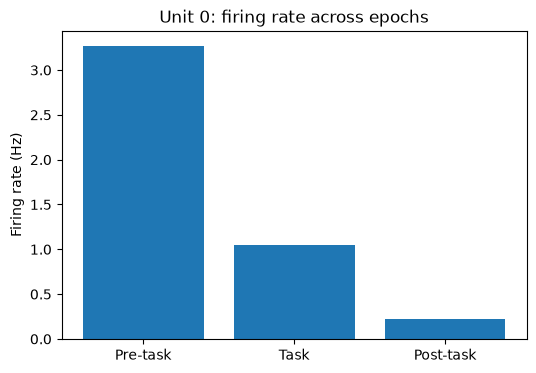

In [23]:
labels = ["Pre-task", "Task", "Post-task"]
rates = [pre_rate, task_rate, post_rate]

plt.figure(figsize=(6, 4))
plt.bar(labels, rates)

plt.ylabel("Firing rate (Hz)")
plt.title("Unit 0: firing rate across epochs")

plt.show()

In [6]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt

In [22]:
pre_isi = np.diff(pre_spikes)
task_isi = np.diff(task_spikes)
post_isi = np.diff(post_spikes)

print("Pre-task median ISI:", np.median(pre_isi))
print("Task median ISI:", np.median(task_isi))
print("Post-task median ISI:", np.median(post_isi))

Pre-task median ISI: 0.19693259874998148
Task median ISI: 0.4459816697658425
Post-task median ISI: 2.5521904800098127


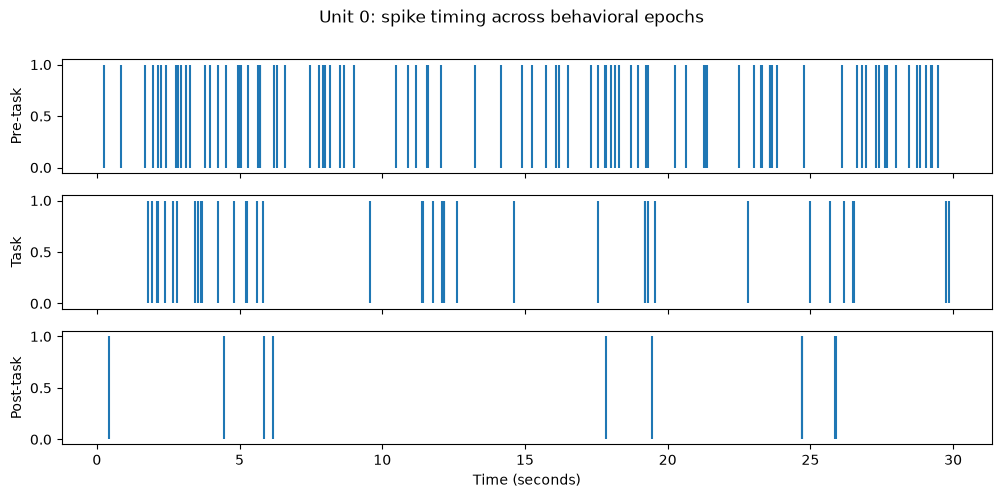

In [21]:
window = 30

pre_30 = pre_spikes[
    pre_spikes < pre_start + window
] - pre_start

task_30 = task_spikes[
    task_spikes < task_start + window
] - task_start

post_30 = post_spikes[
    post_spikes < post_start + window
] - post_start


fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True)

axes[0].vlines(pre_30, 0, 1)
axes[0].set_ylabel("Pre-task")

axes[1].vlines(task_30, 0, 1)
axes[1].set_ylabel("Task")

axes[2].vlines(post_30, 0, 1)
axes[2].set_ylabel("Post-task")
axes[2].set_xlabel("Time (seconds)")

plt.suptitle("Unit 0: spike timing across behavioral epochs")
plt.show()

In [11]:
print(all_units.columns.tolist())

['activity_drift', 'amplitude', 'amplitude_cutoff', 'amplitude_cv_median', 'amplitude_cv_range', 'amplitude_median', 'ccf_ap', 'ccf_dv', 'ccf_ml', 'cluster_id', 'd_prime', 'decoder_label', 'decoder_probability', 'default_qc', 'device_name', 'drift_mad', 'drift_ptp', 'drift_std', 'electrode_group_name', 'exp_decay', 'firing_range', 'firing_rate', 'half_width', 'is_not_drift', 'is_qc_pass', 'isi_violations_count', 'isi_violations_ratio', 'isolation_distance', 'l_ratio', 'location', 'nn_hit_rate', 'nn_miss_rate', 'num_negative_peaks', 'num_positive_peaks', 'num_spikes', 'peak_channel', 'peak_electrode', 'peak_to_valley', 'peak_trough_ratio', 'presence_ratio', 'recovery_slope', 'repolarization_slope', 'rp_contamination', 'rp_violations', 'silhouette', 'sliding_rp_violation', 'snr', 'spike_amplitudes', 'spread', 'structure', 'sync_spike_2', 'sync_spike_4', 'sync_spike_8', 'unit_id', 'velocity_above', 'velocity_below', 'spike_times', 'obs_intervals', 'electrode_group']


In [20]:
pre_duration = pre_stop - pre_start
task_duration = task_stop - task_start
post_duration = post_stop - post_start

pre_rate = len(pre_spikes) / pre_duration
task_rate = len(task_spikes) / task_duration
post_rate = len(post_spikes) / post_duration

print("Pre-task firing rate:", pre_rate, "Hz")
print("Task firing rate:", task_rate, "Hz")
print("Post-task firing rate:", post_rate, "Hz")

Pre-task firing rate: 3.2726939941588875 Hz
Task firing rate: 1.0499525499308155 Hz
Post-task firing rate: 0.2221957982409753 Hz


In [19]:
# Define the three periods from the epochs table

pre_start = 927.69937
pre_stop  = 1530.87217

task_start = 2155.69515
task_stop  = 5796.812075

post_start = 6420.33438
post_stop  = 7023.40609


# Select Unit 0 spikes occurring inside each period

pre_spikes = unit0_spikes[
    (unit0_spikes >= pre_start) &
    (unit0_spikes < pre_stop)
]

task_spikes = unit0_spikes[
    (unit0_spikes >= task_start) &
    (unit0_spikes < task_stop)
]

post_spikes = unit0_spikes[
    (unit0_spikes >= post_start) &
    (unit0_spikes < post_stop)
]


print("Pre-task spikes:", len(pre_spikes))
print("Task spikes:", len(task_spikes))
print("Post-task spikes:", len(post_spikes))

Pre-task spikes: 1974
Task spikes: 3823
Post-task spikes: 134


In [18]:
trials = nwbfile.trials[:]

print(trials.shape)
print(trials.columns.tolist())

(545, 49)
['start_time', 'stop_time', 'quiescent_start_time', 'quiescent_stop_time', 'stim_start_time', 'stim_stop_time', 'response_window_start_time', 'response_window_stop_time', 'task_control_response_time', 'response_time', 'reward_time', 'post_response_window_start_time', 'post_response_window_stop_time', 'stim_name', 'grating_phase', 'block_index', 'rewarded_modality', 'trial_index', 'trial_index_in_block', 'repeat_index', 'is_response', 'is_correct', 'is_incorrect', 'is_hit', 'is_false_alarm', 'is_correct_reject', 'is_miss', 'is_go', 'is_nogo', 'is_rewarded', 'is_noncontingent_reward', 'is_contingent_reward', 'is_reward_scheduled', 'is_instruction', 'is_aud_stim', 'is_vis_stim', 'is_catch', 'is_target', 'is_aud_target', 'is_vis_target', 'is_nontarget', 'is_aud_nontarget', 'is_vis_nontarget', 'is_vis_rewarded', 'is_aud_rewarded', 'is_block_switch', 'is_repeat', 'is_opto', 'is_task_control_correct']


In [17]:
epochs = nwbfile.intervals["epochs"][:]

print(epochs.shape)
print(epochs.columns.tolist())
epochs

(6, 6)
['start_time', 'stop_time', 'script_name', 'notes', 'interval_names', 'tags']


,start_time,stop_time,script_name,notes,interval_names,tags
id,,,,,,
0,45.62740,916.491240,RFMapping,,"[vis_rf_mapping_trials, aud_rf_mapping_trials]",[mapping]
1,927.69937,1530.872170,Spontaneous,,[],[spontaneous]
2,1541.98091,2145.086620,SpontaneousRewards,,[],"[rewards, spontaneous]"
3,2155.69515,5796.812075,DynamicRouting1,,"[trials, performance]","[task, rewards]"
4,5806.68705,6409.775485,SpontaneousRewards,,[],"[rewards, spontaneous]"
5,6420.33438,7023.406090,Spontaneous,,[],[spontaneous]


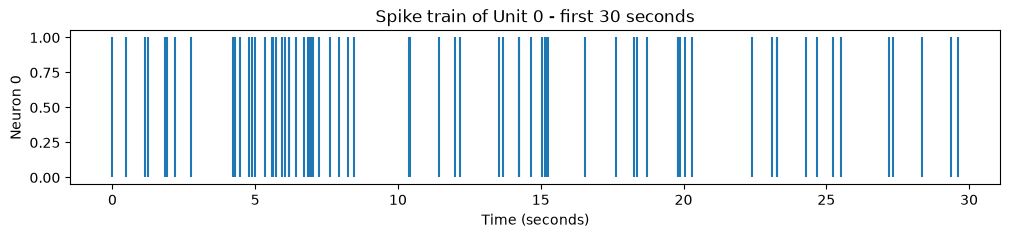

In [16]:
plt.figure(figsize=(12, 2))

plt.vlines(spikes_30s - start_time, 0, 1)

plt.xlabel("Time (seconds)")
plt.ylabel("Neuron 0")
plt.title("Spike train of Unit 0 - first 30 seconds")

plt.show()

In [15]:
start_time = unit0_spikes[0]
end_time = start_time + 30

spikes_30s = unit0_spikes[
    (unit0_spikes >= start_time) &
    (unit0_spikes < end_time)
]

print("Start:", start_time)
print("End:", end_time)
print("Number of spikes:", len(spikes_30s))

Start: 20.899214575483686
End: 50.89921457548368
Number of spikes: 70


In [13]:
isi0 = np.diff(unit0_spikes)

print(isi0[:20])

[0.46176494 0.69286408 0.0795997  0.58956447 0.07606638 0.30159887
 0.54236464 1.47042785 0.09243299 0.16689938 0.32479879 0.07173307
 0.13486616 0.33263209 0.25383239 0.03549987 0.11799956 0.19669927
 0.11519957 0.12339954]


In [12]:
unit0_spikes = all_units.iloc[0]["spike_times"]

print(type(unit0_spikes))
print(len(unit0_spikes))
print(unit0_spikes[:20])

<class 'numpy.ndarray'>
10308
[20.89921458 21.36097952 22.0538436  22.1334433  22.72300777 22.79907416
 23.10067303 23.64303767 25.11346552 25.20589851 25.37279789 25.69759668
 25.76932974 25.90419591 26.236828   26.49066039 26.52616025 26.64415981
 26.84085908 26.95605865]


In [10]:
print(all_units.shape)

(2285, 59)


In [9]:
all_units = nwbfile.units[:]

In [8]:
nwb_path = "/data/dynamicrouting_datacube/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr"

nwbfile = pynwb.read_nwb(nwb_path)
nwbfile

/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.42651
2,14.44318
3,14.45984
,timestamps
id,
0,NaN
1,14.64815
2,14.66481
